# **TS ACADEMY GROUP 12 CAPSTONE PROJECT- FRAUD DETECTION ANALYSIS**

# **DATA SOURCING, JUSTIFICATION AND ACTIVE MEMBERS**

 In the attempt to carry out the capstone project that would justify our learning and test our knowledge in data science with the tools and resources provided by TS Academy, we the members are carrying out the classification track which falls under the supervised learning. The major aim of the project is to source for a dataset, carry out mandatory EDAs and finally build the classification models that were demanded of us. The baseline classification model is the Logistic Regression model while the advanced model chosen is the Random Forest Classification model.

 The dataset being used is a fraud detection dataset of users who carried out transactions using paysim. PaySim is a financial simulator that simulates mobile money transactions based on an original dataset. Although the dataset was generated synthetically using paysim, this dataset was chosen because of how good it relates with real world financial transactions and is also a very good dataset that works well with classification models.

 The dataset shows transactions that were tagged as fraud and those that were legit. It is a large dataset containing 5,420,481 rows and 27 columns sourced from Kaggle (with aggregated) the link to the dataset is shown as follows: (https://www.kaggle.com/datasets/chendoytshman/fraud-detection-paysim).

 The major goal of this capstone project is to build classification models that could be able to identify the patterns in the various transactions and train these models in order to predict the outcome of the transactions if they are fraud transactions or not. These models are built in an attempt to be deployed into real world data especially financial databases and be able to use the models that we build and train to immediately flag transactions who follows the same pattern of the transactions flagged as fraud and prevent future users from falling victims of fraud.

The members of group 12 who participated in the capstone project are listed as follows:

### **Group Leader**

| Name | Email | GitHub | Role |
|---|---|---|---|
| **PRINCESS CHIAMAKA EMENARI** | princessemenari2@gmail.com | [GitHub](https://github.com/Princess-ma) | ***Group Leader*** |



### **Active Members**

| Name | Email | GitHub | Role |
|---|---|---|---|
| Kolawole Julius Oluwatobi | anthonyjk1204@gmail.com | [GitHub](https://github.com/kjuls) | Active Member |
| Olaleru Praise Ajibola | zionpraiz9@gmail.com | [GitHub](https://github.com/zionpraiz9-code) | Active Member |
| Adeleye Adekunle Oluwaseun | dequnle7@gmail.com | [GitHub](https://github.com/qunlecrown) | Active Member |
| Udoh Edidiong Monday | beeeddy22@gmail.com | [GitHub](https://github.com/Edidiong-Udoh2) | Active Member |
| Ukonu Fortune Chiemela | ukonufortune@gmail.com | [GitHub](https://github.com/Fortuneukonu) | Active Member |
| Ogunniyi Ibrahim Adedeji | ogunniyiibrahim2029@gmail.com | [GitHub](https://github.com/nobleXibrahim) | Active Member |
| Emmanuella Chioma Ogoke | chiomaogoke2025@gmail.com | [GitHub](https://github.com/chiomas-art) | Active Member |
| Titus Oluwafemi Ojo | femititus@gmail.com | [GitHub](https://github.com/femititus) | Active Member |
| Kushimo Samuel Oluwashola | kushimooluwashola7652@gmail.com | [GitHub](https://github.com/iamoluwashola) | Active Member |

***ABSTRACT***

***This project presents a comprehensive end-to-end supervised machine learning pipeline for fraud detection in mobile money transactions, developed using the PaySim simulation dataset comprising 5,420,481 transaction records across 27 features. The study was carried out across five structured stages; data cleaning and preparation, data distribution analysis, bivariate and multivariate exploratory analysis, data preprocessing, and machine learning model development with each stage building directly on the findings of the previous to form a fully connected, evidence-driven analytical framework.
The dataset was first optimised through heuristic memory downcasting, reducing its footprint by 57.4% from 1.116 GB to 475 MB, followed by column renaming, removal of redundant features and label encoding of the categorical transaction type variable. Exploratory analysis revealed a severe class imbalance of 98.88% non-fraud versus 1.12% fraud, extreme right skewness in transaction amount features (skew=12.62, kurtosis=230.64), and a channel-specific fraud concentration exclusively within TRANSFER (8.3% fraud rate) and CASH_OUT (2.7% fraud rate) transaction types. Bivariate analysis further uncovered a systematic account-draining behavioral pattern among fraudsters transacting at amounts 15–20 times the legitimate user average alongside the identification of 4,937 repeat mule receiver accounts indicative of an organised fraud network, and a measurable end-of-month fraud escalation peaking at 29.78% in the final week of the simulation period. Feature selection was guided by correlation analysis, multicollinearity assessment and domain-level interpretability, producing a final 6-feature model input comprising transaction_amount, avg_amount_last_30days, transaction_type_encoded, total_sent_last_1hr, receiver_balance_after and week_group_encoded. Class imbalance was addressed through random undersampling of the training set to a balanced 97,066 samples, with StandardScaler applied post-resampling on the balanced training data exclusively.
Two classification models were developed and evaluated. Logistic Regression with L2 regularisation (C=0.05) and a constrained Random Forest ensemble (max_depth=8, n_estimators=100) alongside Grid Search cross-validation for hyperparameter optimisation. The Random Forest achieved superior performance across all fraud-specific metrics, delivering a test recall of 97.50%, an F1 score of 71.46% and only 303 missed fraud cases out of 12,133 on the real-world imbalanced test set. Grid Search CV further refined the model to an optimal configuration of max_depth=10, min_samples_leaf=25 and min_samples_split=50, achieving a cross-validation ROC-AUC of 0.9993 and improving fraud F1 to 0.75 on the test set. The findings confirm that fraudulent financial transactions exhibit identifiable, consistent and detectable behavioral patterns, and that an ensemble tree-based model trained on behaviorally meaningful features can serve as a reliable, production-ready fraud detection system for mobile money platforms.***

**TABLE OF CONTENT**

This project was carried out and split into 5 different stages:
1. DATA PREPARATION AND CLEANING
2. DATA DISTRIBUTION
3. BIVARIATE AND MULTIVARIATE ANALYSIS
4. DATA PREPROCESSING
5. MACHINE LEARNING

# **STAGE ONE - DATA CLEANING AND PREPARATION**

The file was to mounted  so that it can be accessed by all members of the group

In [ ]:
import pandas as pd

# Load the dataset
fd = pd.read_csv('/content/drive/MyDrive/with_aggregated.csv')

# View the first few rows to make sure it loaded correctly
fd.head()

,Unnamed: 0,step,action,amount,nameOrig,oldBalanceOrig,newBalanceOrig,nameDest,oldBalanceDest,newBalanceDest,...,count1h,count1d,count7d,count30d,mean_1h,mean_1d,mean_7d,mean_30d,time_x,time_y
0,0,0,TRANSFER,51.47,C5155482480,51.47,0.0,CC2160409073,0.0,51.47,...,1,1,1,1,51.47,51.47,51.47,51.47,1.0,0.0
1,1,0,CASH_OUT,51.47,CC2160409073,51.47,0.0,M2788501400,0.0,0.00,...,1,1,1,1,51.47,51.47,51.47,51.47,1.0,0.0
2,2,0,TRANSFER,306.06,C6262505545,306.06,0.0,CC9524765415,0.0,306.06,...,1,1,1,1,306.06,306.06,306.06,306.06,1.0,0.0
3,3,0,CASH_OUT,306.06,CC9524765415,306.06,0.0,M3707455010,0.0,0.00,...,1,1,1,1,306.06,306.06,306.06,306.06,1.0,0.0
4,4,0,TRANSFER,32.72,C6865329088,32.72,0.0,CC8773639961,0.0,32.72,...,1,1,1,1,32.72,32.72,32.72,32.72,1.0,0.0


In [ ]:
#Importing necessary Libraries for the analysis
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.under_sampling import RandomUnderSampler

# file warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# reading in the fraud detection dataset (with_aggregated)
fd = pd.read_csv('/content/drive/MyDrive/with_aggregated.csv')
fd.head()

,Unnamed: 0,step,action,amount,nameOrig,oldBalanceOrig,newBalanceOrig,nameDest,oldBalanceDest,newBalanceDest,...,count1h,count1d,count7d,count30d,mean_1h,mean_1d,mean_7d,mean_30d,time_x,time_y
0,0,0,TRANSFER,51.47,C5155482480,51.47,0.0,CC2160409073,0.0,51.47,...,1,1,1,1,51.47,51.47,51.47,51.47,1.0,0.0
1,1,0,CASH_OUT,51.47,CC2160409073,51.47,0.0,M2788501400,0.0,0.00,...,1,1,1,1,51.47,51.47,51.47,51.47,1.0,0.0
2,2,0,TRANSFER,306.06,C6262505545,306.06,0.0,CC9524765415,0.0,306.06,...,1,1,1,1,306.06,306.06,306.06,306.06,1.0,0.0
3,3,0,CASH_OUT,306.06,CC9524765415,306.06,0.0,M3707455010,0.0,0.00,...,1,1,1,1,306.06,306.06,306.06,306.06,1.0,0.0
4,4,0,TRANSFER,32.72,C6865329088,32.72,0.0,CC8773639961,0.0,32.72,...,1,1,1,1,32.72,32.72,32.72,32.72,1.0,0.0


In [ ]:
# column names
fd.columns.tolist()

['Unnamed: 0',
 'step',
 'action',
 'amount',
 'nameOrig',
 'oldBalanceOrig',
 'newBalanceOrig',
 'nameDest',
 'oldBalanceDest',
 'newBalanceDest',
 'isFraud',
 'isFlaggedFraud',
 'isUnauthorizedOverdraft',
 'amount1h',
 'amount1d',
 'amount7d',
 'amount30d',
 'count1h',
 'count1d',
 'count7d',
 'count30d',
 'mean_1h',
 'mean_1d',
 'mean_7d',
 'mean_30d',
 'time_x',
 'time_y']

In [ ]:
# shape of the dataset
fd.shape

(5420481, 27)

In [ ]:
# summary of the dataset
fd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5420481 entries, 0 to 5420480
Data columns (total 27 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   Unnamed: 0               int64  
 1   step                     int64  
 2   action                   object 
 3   amount                   float64
 4   nameOrig                 object 
 5   oldBalanceOrig           float64
 6   newBalanceOrig           float64
 7   nameDest                 object 
 8   oldBalanceDest           float64
 9   newBalanceDest           float64
 10  isFraud                  int64  
 11  isFlaggedFraud           int64  
 12  isUnauthorizedOverdraft  int64  
 13  amount1h                 float64
 14  amount1d                 float64
 15  amount7d                 float64
 16  amount30d                float64
 17  count1h                  int64  
 18  count1d                  int64  
 19  count7d                  int64  
 20  count30d                 int64  
 21  mean_1h 

The dataset 'fraud_detection_paysim' with the original name 'aggregated_cv', it was changed from the local machine that was used in carrying out this project. The dataset (fd) is a large financial dataset with 5,420,481 records and 27 features and therefore to improve performance during model training, memory downcasting (for example, converting 64-bit floats to 32-bit) the dataset’s RAM usage would be reduced. As earlier stated, the shape of the dataset is also confrimed to be 5,420,481 rows and 27 columns where 15 of the columns are all float values (decimal places), 9 of the columns are integer columns (whole numbers/ labelled columns), while the remaining 3 are object columns (text columns). The memory usage of the dataset 'fd' is 1.1+GB.

In [ ]:
# REDUCING OF DATA MEMORY USAGE FOR EASE IN ANALYSIS
def reduce_mem_usage(fd):
    start_mem = fd.memory_usage().sum() / 1024**2
    print(f'Memory usage of dataframe is {start_mem:.2f} MB')

    for col in fd.columns:
        col_type = fd[col].dtype

        # SKIP columns already converted to category
        if str(col_type) == 'category':
            continue

        if col_type != object:
            c_min = fd[col].min()
            c_max = fd[col].max()

            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    fd[col] = fd[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    fd[col] = fd[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    fd[col] = fd[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    fd[col] = fd[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    fd[col] = fd[col].astype(np.float32)
                else:
                    fd[col] = fd[col].astype(np.float64)
        else:
            if fd[col].nunique() < 10:
                fd[col] = fd[col].astype('category')

    end_mem = fd.memory_usage().sum() / 1024**2
    print(f'Memory usage after optimization is: {end_mem:.2f} MB')
    print(f'Decreased by {100 * (start_mem - end_mem) / start_mem:.1f}%')
    return fd

fd = reduce_mem_usage(fd)

Memory usage of dataframe is 1116.58 MB
Memory usage after optimization is: 475.58 MB
Decreased by 57.4%


#### Memory Usage Optimizer (Heuristic Downcasting)

The dataset memory footprint was minimized by downcasting numeric columns to their smallest possible data types without losing information.

It is observed that the system’s memory usage was reduced by 57.4%, lowering the dataset size from 1.116 GB to 480.22 MB. This was done through downcasting, where 64-bit data types were converted to more efficient 8-bit, 16-bit, or 32-bit types based on their value ranges.

This optimization keeps all the data intact while improving computational speed. With the dataset now under 500 MB, the system avoids memory bottlenecks that can crash kernels during heavy tasks like cross-validation or grid search, making it ready for the machine learning stage.

### **FEATURE ENGINEERING**

In [ ]:
# RENAMING COLUMNS
fdd = fd.copy()
fdd.rename(columns={
    'Unnamed: 0': 'row_id',
    'step': 'hour_of_simulation',
    'action': 'transaction_type',
    'amount': 'transaction_amount',
    'nameOrig': 'sender_id',
    'oldBalanceOrig': 'sender_balance_before',
    'newBalanceOrig': 'sender_balance_after',
    'nameDest': 'receiver_id',
    'oldBalanceDest': 'receiver_balance_before',
    'newBalanceDest': 'receiver_balance_after',
    'isFraud': 'fraud_label',
    'isFlaggedFraud': 'rule_based_fraud_flag',
    'isUnauthorizedOverdraft': 'unauthorized_overdraft_flag',
    'amount1h': 'total_sent_last_1hr',
    'amount1d': 'total_sent_last_1day',
    'amount7d': 'total_sent_last_7days',
    'amount30d': 'total_sent_last_30days',
    'count1h': 'tx_count_last_1hr',
    'count1d': 'tx_count_last_1day',
    'count7d': 'tx_count_last_7days',
    'count30d': 'tx_count_last_30days',
    'mean_1h': 'avg_amount_last_1hr',
    'mean_1d': 'avg_amount_last_1day',
    'mean_7d': 'avg_amount_last_7days',
    'mean_30d': 'avg_amount_last_30days',
    'time_x': 'time_merge_flag',
    'time_y': 'transaction_time_duplicate'
}, inplace=True)

All the column names in the dataset were renamed because at first view, the original names did not fully depict the meaning of the columns. In an attempt to solve this problem, each columns was carefully analysed with the help of analytical thinking together with the help of LLMs, the names were changed to ones that fully explains their meaning. This decision was made singlehandedly by the group leader (Princess Emenari), however this was done in a copy of the dataset (fdd) as the original dataset was not tampered with.. The changes made to the column names are as follows:

1. 'Unamed:0' was changed to row_id which shows the each unique transaction that has occured in the dataset. It would not be used later on becaues there is no significance in the analysis as they are just auto-generated row index from CSV export — no real meaning.
2. 'step' was changed to 'hour_of_simulation which is used to identify the unit of simulation time of each transactions(1 step = 1 hour, max 744 = 31 days)
3. 'action' was changed to 'transaction_type which shows all the modes each individual used to make their various transactions
4. 'amount' was changed to 'transaction_amount' which shows the total amount that was involved in the transation
5. 'nameOrg' was changed to 'sender_id' which shows the unique id of the sender that made the transaction
6. 'oldBalanceOrig' was changed to 'sender_balance_before' which expalins the amount in the sender's account before that transaction was made
7. 'newBalanceOrig' was changed to 'sender_balance_after' which explains the balance of the sender after the transaction was made.
8. 'nameDest' was changed to 'receiver_id' which is used to identify the unique ID of the recipient account
9. 'oldBalanceDest' was changed to 'receiver_balance_before' which shows the Receiver's balance before the transaction
10. 'newBalanceDest' was changed to 'receiver_balance_after' which means Receiver's balance after the transaction
11. 'isFraud' was changed to 'fraud_label' which shows which transaction is fraud(1) and non fraud(0)
12. 'isFlaggedFraud' was changed to 'rule_based_fraud_flag' which shows that if a transaction follows a particular rule, they would be tagged as fraud , however the column is insignificant because the outcome was different from the orignal result
13. 'isUnauthorizedOverdraft' was changed to 'unauthorized_overdraft_flag' which Flags if the transaction resulted in an unauthorized overdraft on the account
14. 'amount1hr' was changed to 'total_sent_1hr' which shows the total amount sent by this sender in the last 1 hour
15. 'amount1d' was changed to 'total_sent_last_1day' which means Total amount sent by this sender in the last 1 day
16. 'amount1d' was changed to 'total_sent_last_7days' which means Total amount sent by this sender in the last 7 days
17. 'amount30d' was changed to ''total_sent_last_30days' which means Total amount sent by this sender in the last 30 days
18. 'count1h' was changed to 'tx_count_last_1hr' which means Number of transactions made by this sender in the last 1 hour
19. 'count1d' was changed to 'tx_count_last_1day' which means Number of transactions made by this sender in the last 1 day
20. 'count7d' was changed to 'tx_count_last_7days' which means Number of transactions made by this sender in the last 7 days
21. 'count30d' was changed to 'tx_count_last_30days' which means Number of transactions made by this sender in the last 30 days
22. 'mean_1h' was changed to ' avg_amount_last_1day' which means Sender's average transaction amount in the last 1 hour
23. 'mean_1d' was changed to avg_amount_last_1day which means Sender's average transaction amount in the last 1 day
24. 'mean_7d' was changed to 'avg_amount_last_7days' which mean Sender's average transaction amount in the last 7 day
25. 'mean_30d' was changed to 'avg_amount_last_30days' which means Sender's average transaction amount in the last 30 days

 time_x and time_y were removed as the actual meaning could not be identified both from the original source, analytical evaluation and even with the help off LLMs and therefore they were both dropped in odrer not to cause confusion/misinterpretation.

'fdd' is now the new dataset being used in the analysis and this shows the new column names after the renaming.

In [ ]:
# identifying if there are missing values in the dataset
fdd.isna().sum()

,0
row_id,0
hour_of_simulation,0
transaction_type,0
transaction_amount,0
sender_id,0
sender_balance_before,0
sender_balance_after,0
receiver_id,0
receiver_balance_before,0
receiver_balance_after,0


The dataset shows to be a complete one without missing values, therefore there would be no calculation and visualization of missing values percenage

In [ ]:
# dropping insignificant columns (reasons explained in the report evaluation.)
fdd.drop(columns=['transaction_time_duplicate', 'time_merge_flag', 'rule_based_fraud_flag'], inplace=True)

In [ ]:
# Identifying Zero Values
(fdd == 0).sum()

,0
row_id,1
hour_of_simulation,101
transaction_type,0
transaction_amount,1
sender_id,0
sender_balance_before,11055
sender_balance_after,60830
receiver_id,0
receiver_balance_before,335253
receiver_balance_after,255260


In an attempt to confirm the existence of missing values being hidden through place holders, the zero values were checked and it is confirmed that all zero values are true to their identity and are no being used as place holders for missing values because all the columns with zero values are labelled columns/categorical columns which is valid. Even though transacion amount being the only float column showed zero, there was only 1 count which could be considered to be an outlier where an account that did not make any transaction could be tagged as a fraud or non fraud transaction.

In [ ]:
# label encoding of transaction type
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()  # Initialize LabelEncoder

# Applying Label Encoding to 'transaction type'
fdd['transaction_type_encoded'] = label_encoder.fit_transform(fdd['transaction_type'])
print(fdd[['transaction_type', 'transaction_type_encoded']].sample(10))

        transaction_type  transaction_type_encoded
3978718          CASH_IN                         0
4621012          PAYMENT                         3
4405032         CASH_OUT                         1
4431136          CASH_IN                         0
2544619         CASH_OUT                         1
5341722         CASH_OUT                         1
122101           CASH_IN                         0
4716058          CASH_IN                         0
405908          CASH_OUT                         1
1196122         CASH_OUT                         1


transaction type being the only text column that is categorical was encoded with label encoder imported from sklearn library and a new column 'transaction_type_encoded' was created where each of the values were assigned to unique labels ranging from 0-4. The assigning was done as follows:


0 represents CASH_IN

1 represents CASH_OUT

2 represents DEBIT

3 represnts PAYMENT

4 represents TRANSFER

In [ ]:
# SUMMARY OF THE DATASET AFTER CLEANING
fdd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5420481 entries, 0 to 5420480
Data columns (total 25 columns):
 #   Column                       Dtype   
---  ------                       -----   
 0   row_id                       int32   
 1   hour_of_simulation           int16   
 2   transaction_type             category
 3   transaction_amount           float32 
 4   sender_id                    object  
 5   sender_balance_before        float32 
 6   sender_balance_after         float32 
 7   receiver_id                  object  
 8   receiver_balance_before      float32 
 9   receiver_balance_after       float32 
 10  fraud_label                  int8    
 11  unauthorized_overdraft_flag  int8    
 12  total_sent_last_1hr          float32 
 13  total_sent_last_1day         float32 
 14  total_sent_last_7days        float32 
 15  total_sent_last_30days       float32 
 16  tx_count_last_1hr            int8    
 17  tx_count_last_1day           int8    
 18  tx_count_last_7days   

This is the new information of the dataset after cleaning, there are now 25 columns, where 13 are float columns, 9 are integer columns and 2 are text columns and as a result of the memory usage reduction, a new data type 'category' was created and there is only 1 feature assigned to this datatype 'transaction_type' with a new memory usage of 470.4+MB

In [ ]:
# checking for duplicated rows
fdd.duplicated().sum()

np.int64(0)

the dataset has no duplicate rows among the 5.4 million transactions, meaning every record is unique and the data quality is very good.

This is important because it helps prevent data leakage, where the same data appears in both the training and testing sets and makes the model look more accurate than it really is. Since all transactions are unique, the model will have to learn real fraud patterns instead of memorizing repeated records, making the results more trustworthy.

### **REPORT EVALUATION- STAGE 1**

The fraud detection dataset (fd) is a large-scale financial transactions dataset sourced from Kaggle containing 5,420,481 rows and 27 columns. The dataset covers transactions carried out by unique users in a simulated PaySim environment, with each transaction tagged as either fraudulent or legitimate. The dataset comprises 15 float features, 9 integer features and 3 object features, and critically, contains no missing values whatsoever confirming it as a clean and complete dataset that required no imputation.
  
To improve performance during model training on such a large dataset, memory downcasting was applied using a custom reduce_mem_usage() function. This function iterates through all numeric columns and downcasts them to their smallest possible data type without any loss of information for example, converting int64 to int8 or float64 to float32 based on the actual value ranges present. The result was a 57.4% reduction in memory usage, bringing the dataset from 1,116 MB down to 475 MB, making it significantly more manageable for downstream analysis and modelling.

Following memory optimization, all 27 column names were renamed to more descriptive and intuitive versions in a working copy of the dataset (fdd) to preserve the original. For example, "step" was renamed to "hour_of_simulation", "action" to "transaction_type", "isFraud" to "fraud_label", and "nameOrig"/"nameDest" to "sender_id"/"receiver_id" respectively. Three columns were subsequently dropped — transaction_time_duplicate, time_merge_flag and rule_based_fraud_flag — as they were identified as redundant, duplicate or irrelevant to the fraud prediction objective.

A zero-value check was performed to confirm that no missing values were hidden behind zero placeholders. All zero values were verified to be legitimate, binary flag columns naturally contain zeros, and the single zero in transaction_amount was identified as a potential outlier rather than a data quality issue. The transaction_type column which was the only text categorical column was label encoded using sklearn's LabelEncoder, creating a new "transaction_type_encoded" column where CASH_IN=0, CASH_OUT=1, DEBIT=2, PAYMENT=3 and TRANSFER=4. A final duplicate check confirmed zero duplicate rows across all 5.4 million records, ensuring data integrity and eliminating any risk of data leakage between training and test sets. The cleaned dataset (fdd) contains 25 columns with a memory footprint of approximately 470 MB.


## **STAGE 2 - DATA DISTRIBUTION**

### **CATEGORICAL FEATURES ANALYSIS**
#### **IDENTIFYING UNIQUE VALUES, VALUE COUNTS AND NUMBER OF UNIQUE VALUES**

In [ ]:
'''identifying the number of unique values of labelled columns excluding
excluding row_id and label_encoded columns/features
'''
print('Value Counts of Labelled Columns')
unique_ = fdd[['hour_of_simulation', 'transaction_type', 'sender_id', 'receiver_id',
          'fraud_label', 'unauthorized_overdraft_flag', 'tx_count_last_1hr', 'tx_count_last_1day',
           'tx_count_last_7days', 'tx_count_last_30days']].nunique()
print(unique_)

Value Counts of Labelled Columns
hour_of_simulation               720
transaction_type                   5
sender_id                      35394
receiver_id                    40399
fraud_label                        2
unauthorized_overdraft_flag        2
tx_count_last_1hr                  5
tx_count_last_1day                69
tx_count_last_7days              318
tx_count_last_30days            1071
dtype: int64


The number of unique values of key labelled columns were analysed in order to analyse the values unique to each of these columns and how namy they are. From the analysis, it was revealed that:

1. Hours of simulation had 720 unique values which further confirms the explanation in the meaning explained earlier. It shows that the transactions were simulating in all the hours 720 unique times
2. There were 5 transaction types that were identified to be used throughout the dataset
3. There 35394 unique ID of the senders in the transaction which means it is assumed that these unique senders carried out transactions multiple times
4. There are 40,399 unique count of reciever ids, this also means that these unique receivers received transaction amount multiple times from the senders
5. There are only 2 unique values in the fraud label which is (1) which represents transactions that were fraud and (0) which are the non-fraud transactions
6. There are also 2 unique values in unauthorised overdraft flag which shows transactions that were unauthorised transactions and those that weren't
7. There are 5 unique values in the transaction count in the last 1hr meaning the users fall under 5 different counts of transactions in the last 1hr
8. There are 69 unique values in the transaction count in the last 1 day which shows that all users transaction counts in the last one day amounted to 69 unique transaction counts
9. total transaction count in the last 7 days had 318 unique value count. This means users carried out transactions up to 318 times in 317 days
10. Lastly, the transaction count in the last 30 days amounted to 1071, this means users carried out transactions up to 1071 times in the last 7 days

Row_id, is being excluded for the analysis because after analysing the values from the column, it is discovered that the row_id would prove to be insignificant in the analysis and evaluation because it is just an autogenerated row count of all rows in the dataset.

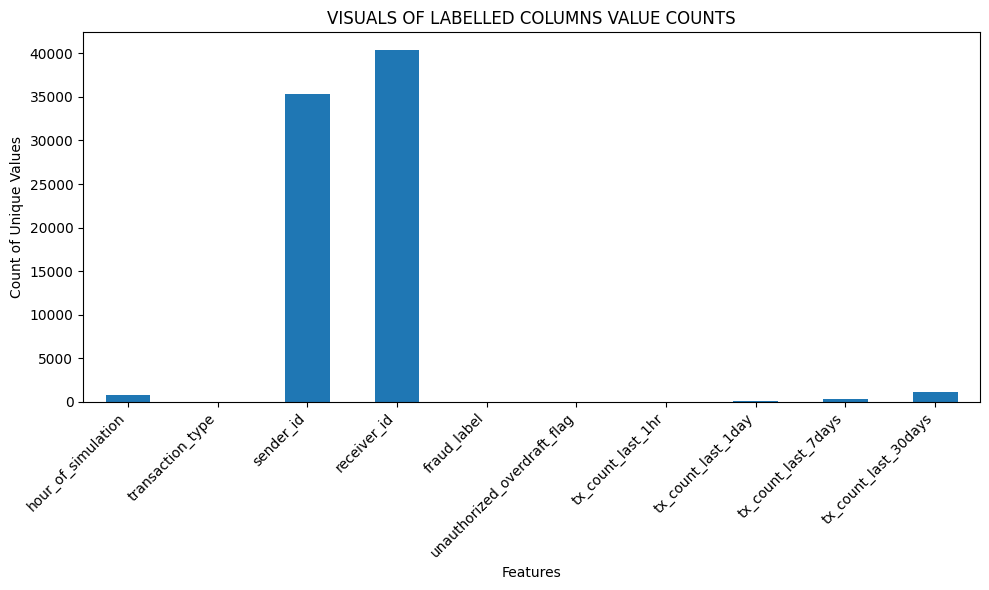

In [ ]:
# VIZUALIZATION OF THE NUMBER OF UNIQUE VALUES IN EACH COLUMNS
plt.figure(figsize=(10,6))
unique_.plot(kind='bar', xlabel='Features', ylabel='Count of Unique Values')
plt.title('VISUALS OF LABELLED COLUMNS VALUE COUNTS')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The value count of the unique value was further visualized.

After analysing the unique values count of the labelled colums, the individual columns were further analysed and their distribution was cross examined along with the percentage error. The revelations are as follows:

In [ ]:
# identifying the unique values of the hours of simulation (hours the transactions were occuring)
print('Unique values in Hours of Simulation:')
unique_ttype = [(fdd['hour_of_simulation'].unique()), (fdd['hour_of_simulation'].nunique())]
print(unique_ttype)
print('\n')
print('value counts of each Hour of Simulation:')
value_ttype = fdd['hour_of_simulation'].value_counts().sample(5)
print(value_ttype)
print('\n')
percentage = ((fdd['hour_of_simulation'].value_counts() / len(fdd)) * 100).sample(5)
print(f'Percentage Measurement of the distribution: {percentage}')

Unique values in Hours of Simulation:
[array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172

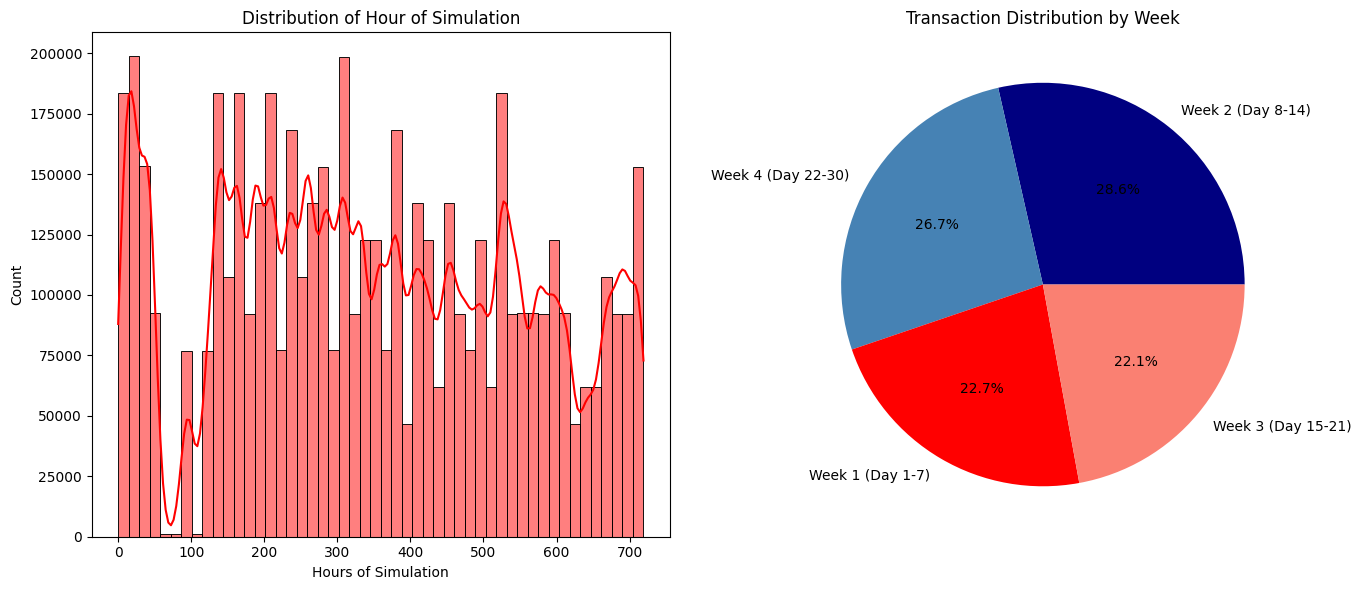

In [ ]:
# vizualization of the distribution of thehours of simulation USING HISTOGRAM AND PIE chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(
    fdd['hour_of_simulation'],
    kde=True,
    bins=50,
    ax=axes[0],
    color='red'
)
axes[0].set_title('Distribution of Hour of Simulation')
axes[0].set_xlabel('Hours of Simulation')
axes[0].set_ylabel('Count')

# PIE CHART - group 720 hours into 30 days (each day = 24 hours)
hour_groups = pd.cut(
    fdd['hour_of_simulation'],
    bins=[0, 168, 336, 504, 720],                                # 0-168 = week 1, 168-336 = week 2, etc.
    labels=['Week 1 (Day 1-7)', 'Week 2 (Day 8-14)',
            'Week 3 (Day 15-21)', 'Week 4 (Day 22-30)']         # 720 hours = 30 days = 4 weeks
)
hour_groups.value_counts().plot(
    kind='pie',
    ax=axes[1],
    autopct='%1.1f%%',
    colors=['navy', 'steelblue', 'red', 'salmon']
)
axes[1].set_title('Transaction Distribution by Week')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

There are notably 720 unique values in the hours of simulation as shown in earlier anlysis, however, due to the high value count, the percentage distribution for each of them could not be displayed however 5 samples were shown just to get an overview of the percentage at which they were distributed. In addition, the visuzlizations shows an histogram of the overall hours of simulation and frequency and a pie chart where the hours of simulation was split into weeks. It was noted that week 2 had the highest transaction simulations of 28.6% percentage distribution which means the highest number transactions occured during the second week, folllowed by the 4th week with a 26.7% percentage distribution and then the 1st week with a 22.7% dstribution and lastly the third week with a percentage distribution count of 22.1%. From the histogram, it also shows a quite normally distributed data spread across all values

In [ ]:
# identifying the unique values of the transaction type
print('Unique values in transaction type:')
unique_ttype = [(fdd['transaction_type'].unique()), (fdd['transaction_type'].nunique())]
print(unique_ttype)
print('\n')
print('value counts of each transaction type:')
value_ttype = fdd['transaction_type'].value_counts().sample(5)
print(value_ttype)
print('\n')
percentage = (fdd['transaction_type'].value_counts() / len(fdd)) * 100
print(f'Percentage Measurement of the distribution: {percentage}')

Unique values in transaction type:
[['TRANSFER', 'CASH_OUT', 'CASH_IN', 'PAYMENT', 'DEBIT']
Categories (5, object): ['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER'], 5]


value counts of each transaction type:
transaction_type
CASH_IN     2257040
TRANSFER     364817
DEBIT        179747
PAYMENT     1494517
CASH_OUT    1124360
Name: count, dtype: int64


Percentage Measurement of the distribution: transaction_type
CASH_IN     41.639109
PAYMENT     27.571668
CASH_OUT    20.742809
TRANSFER     6.730344
DEBIT        3.316071
Name: count, dtype: float64


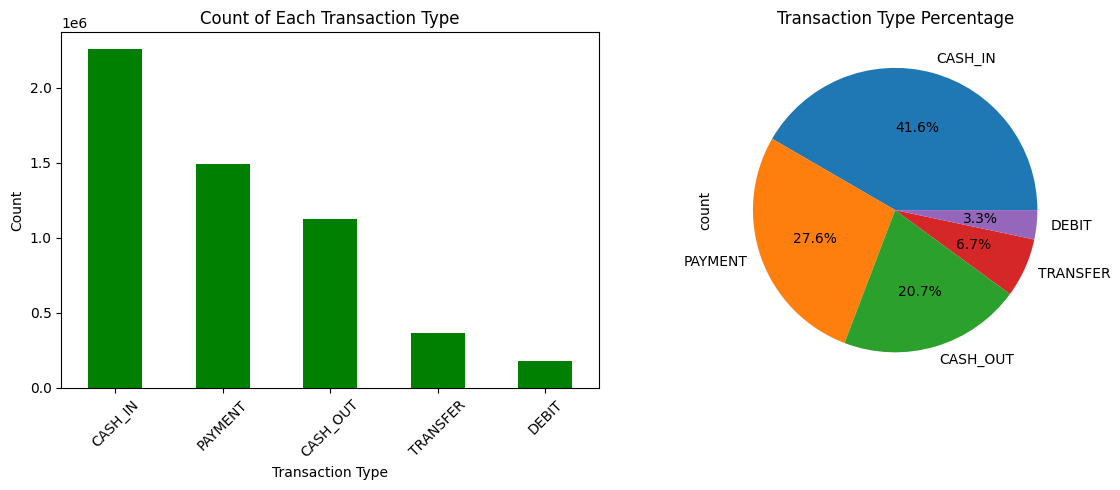

In [ ]:
# vizualization of the distribution of the transaction type USING BARCHART AND PIE chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart of transaction types
fdd['transaction_type'].value_counts().plot(kind='bar', ax=axes[0], color='green')
axes[0].set_title('Count of Each Transaction Type')
axes[0].set_xlabel('Transaction Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart showing percentage distribution
fdd['transaction_type'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Transaction Type Percentage')

plt.tight_layout()
plt.show()

For the transaction type, there are 5 unique values and each of these values were revealed to be: cash in, cash out, payment, debit and transfers. Cash in transactions ended up being the highest method of transaction by users with a count of 2,257,040 transactions which shows 41.6% coverage of the dataset followed by payment with a 1,494,517 transaction count which occupies 27.57% of the total transactions and then the cash_out method with total transaction count of 1,124,360 transactions occupying 20.74% of the dataset also the tranfer method with 364,817 transactions coverng only 6.73% of the total transactions and lastly, the debit method with a count of 179,747 which occupies 3.32% of the dataset.

In [ ]:
# identifying the unique values of the sender's and receiver's id
print("Number of Unique values in Sender and Receiver ID:")
unique_ttype = (f'No. of unique value sender id: {fdd['sender_id'].nunique()}, No. of unique value receiver id: {fdd['receiver_id'].nunique()}')
print(unique_ttype)
print('\n')
print('value counts of each sender and receiver id:')
value_ttype_sender = fdd['sender_id'].value_counts().sample(5)
value_ttype_receiver = fdd['receiver_id'].value_counts().sample(5)
print('Sample of Value Count Distribution of Sender ID:')
print(value_ttype_sender)
print('\n')
print('Sample of Value Count Distribution of Receiver ID:')
print(value_ttype_receiver)
print('\n')
percentage_sender = ((fdd['sender_id'].value_counts() / len(fdd)) * 100).sample(5)
percentage_receiver = ((fdd['receiver_id'].value_counts() / len(fdd)) * 100).sample(5)
print(f'Samples of Percentage Measurement of the Sender ID: {percentage_sender}')
print(f'Samples of Percentage Measurement of the Receiver ID: {percentage_receiver}')

Number of Unique values in Sender and Receiver ID:
No. of unique value sender id: 35394, No. of unique value receiver id: 40399


value counts of each sender and receiver id:
Sample of Value Count Distribution of Sender ID:
sender_id
CC2937149593       1
CC2868488537       3
C8965511809     1061
CC4793188538       1
C9523154102     1060
Name: count, dtype: int64


Sample of Value Count Distribution of Receiver ID:
receiver_id
CC3294227425     4
CC2491734978     3
CC5986807817    10
CC8695333552     1
CC9097662081    10
Name: count, dtype: int64


Samples of Percentage Measurement of the Sender ID: sender_id
CC8024916513    0.000037
CC5326136393    0.000018
CC2304326602    0.000037
CC6041943143    0.000018
CC0213964944    0.000018
Name: count, dtype: float64
Samples of Percentage Measurement of the Receiver ID: receiver_id
CC6086499351    0.000129
CC3771815634    0.000203
CC8238057356    0.000184
CC4486699357    0.000129
C7390920170     0.000314
Name: count, dtype: float64


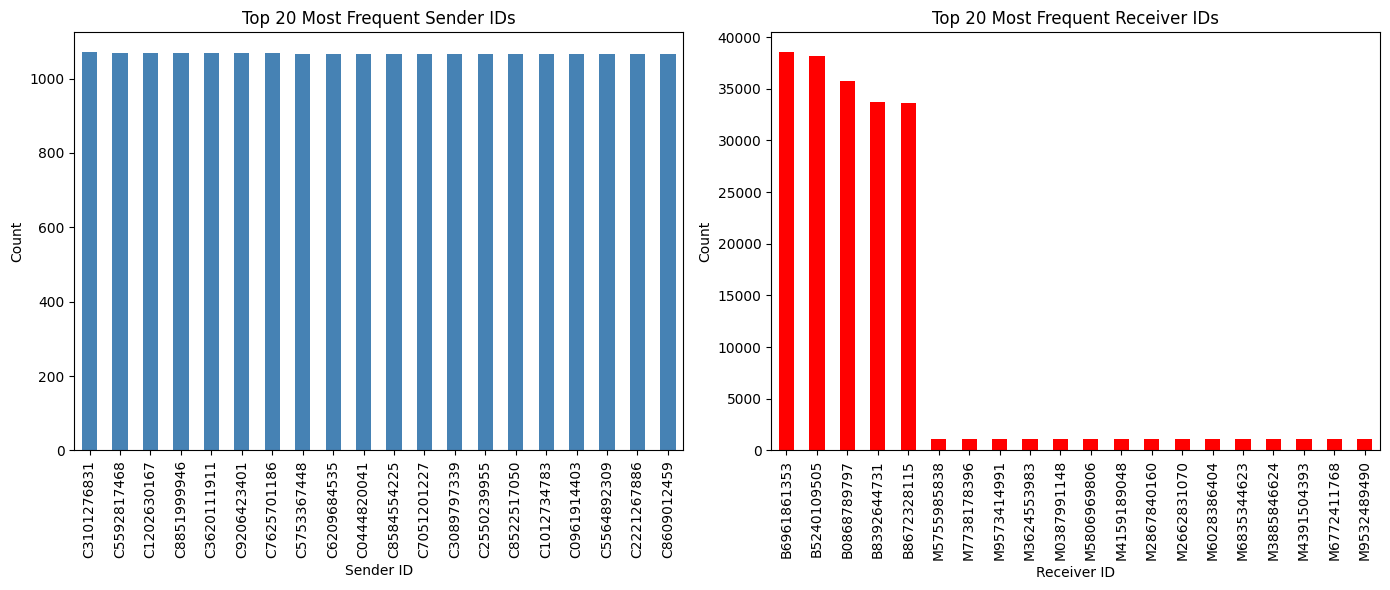

In [ ]:
# VISUALIZATION OF SENDER ID AND RECEIVER ID BY VALUE COUNT

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# TOP 20 MOST FREQUENT SENDER IDs
fdd['sender_id'].value_counts().head(20).plot(
    kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 Most Frequent Sender IDs')
axes[0].set_xlabel('Sender ID')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=90)

# TOP 20 MOST FREQUENT RECEIVER IDs
fdd['receiver_id'].value_counts().head(20).plot(
    kind='bar', ax=axes[1], color='red')
axes[1].set_title('Top 20 Most Frequent Receiver IDs')
axes[1].set_xlabel('Receiver ID')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

As a result of the numerous value counts in the sender id and receiver id, only the top 20 senders and receivers were analysed and visualized and for the sender id, there seem to be an even distribution of the top 20 most frequent which is suspicious On the other hand, the recivers id shows a rightly skewed distributon where there are top 5 receivers while the rest lies evenly below 5000.

These two columns are suspicious as they are not applicaple in real world sense and could be predicted to cause noise during the model training.

In [ ]:
# identifying the unique values and percentage distribution of the fraud label
print('Unique values in Fraud Label:')
unique_flabel = [(fdd['fraud_label'].unique()), (fdd['fraud_label'].nunique())]
print(unique_flabel)
print('\n')
print('value counts of each values in fraud label:')
value_flabel = fdd['fraud_label'].value_counts()
print(value_flabel)
print('\n')
percentage = (fdd['fraud_label'].value_counts() / len(fdd)) * 100
print(f'Percentage Measurement of the distribution: {percentage}')

Unique values in Fraud Label:
[array([1, 0], dtype=int8), 2]


value counts of each values in fraud label:
fraud_label
0    5359815
1      60666
Name: count, dtype: int64


Percentage Measurement of the distribution: fraud_label
0    98.8808
1     1.1192
Name: count, dtype: float64


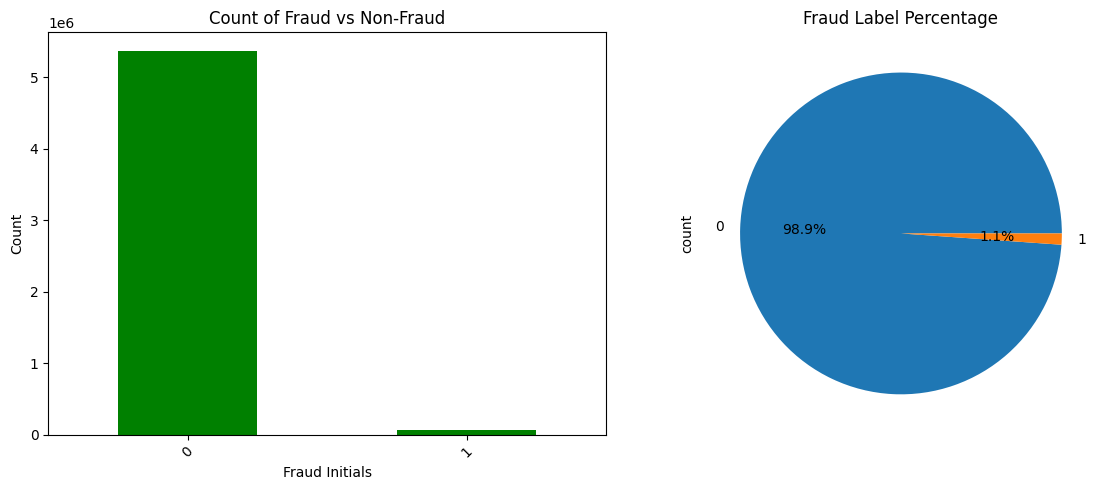

In [ ]:
# Visualization of Fraud Label Count
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart of fraud label
fdd['fraud_label'].value_counts().plot(kind='bar', ax=axes[0], color='green')
axes[0].set_title('Count of Fraud vs Non-Fraud')
axes[0].set_xlabel('Fraud Initials')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart showing percentage distribution
fdd['fraud_label'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Fraud Label Percentage')

plt.tight_layout()
plt.show()

The dataset exhibits a significant class imbalance between fraudulent and non-fraudulent transactions where only 1.1192% of the dataset showed to be fraud and 98.9% is shown to be non-fraud. Fraudulent transactions represent only a small fraction of the overall dataset. This imbalance is typical in real-world fraud detection problems, where fraudulent activities occur much less frequently than legitimate transactions.

This imbalance will need to be addressed in the machine learning phase using techniques such as class weighting and resampling

In [ ]:
# identifying the unique values and percentage distribution of the unauthorized over draft
print('Unique values in unauthorized overdraft')
unique_un_overdraft= [(fdd['unauthorized_overdraft_flag'].unique()), (fdd['unauthorized_overdraft_flag'].nunique())]
print(unique_un_overdraft)
print('\n')
print('value counts of each values in the unauthorized over draft')
value_un_overdraft= fdd['unauthorized_overdraft_flag'].value_counts()
print(value_un_overdraft)
print('\n')
percentage = (fdd['unauthorized_overdraft_flag'].value_counts() / len(fdd)) * 100
print(f'Percentage Measurement of the distribution: {percentage}')

Unique values in unauthorized overdraft
[array([0, 1], dtype=int8), 2]


value counts of each values in the unauthorized over draft
unauthorized_overdraft_flag
0    5401381
1      19100
Name: count, dtype: int64


Percentage Measurement of the distribution: unauthorized_overdraft_flag
0    99.647633
1     0.352367
Name: count, dtype: float64


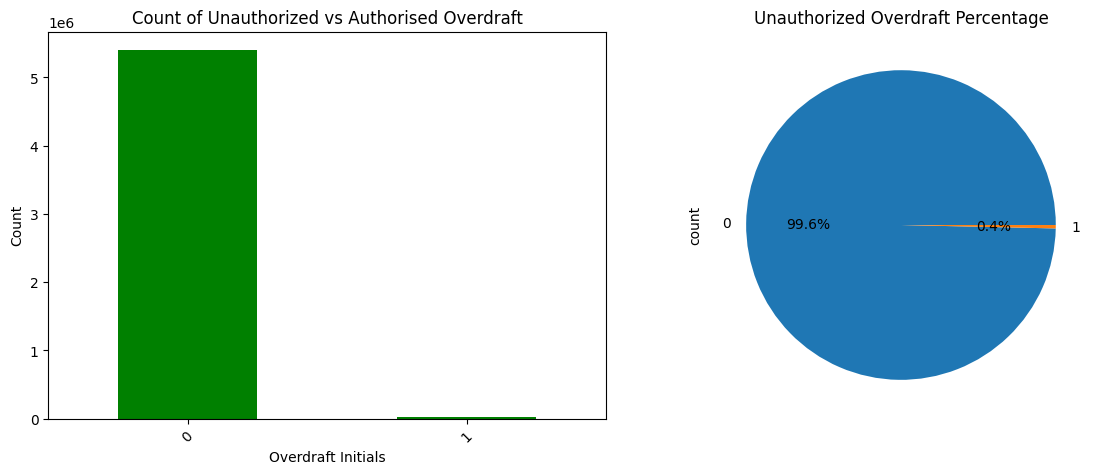

In [ ]:
# Visualization of UnAuthorized Overdraft Count
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart of Unauthorized Overdraft
fdd['unauthorized_overdraft_flag'].value_counts().plot(kind='bar', ax=axes[0], color='green')
axes[0].set_title('Count of Unauthorized vs Authorised Overdraft')
axes[0].set_xlabel('Overdraft Initials')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart showing percentage distribution
fdd['unauthorized_overdraft_flag'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Unauthorized Overdraft Percentage')

plt.tight_layout()
plt.show()

The unauthorized overdraft also shows a huge class imbalance which is also good news in the the real world sense, it means 0.4% of 5m+ data were unauthorized overdraft and isn't a course for alarm. However, precautionary measures should be taken to reduce the numbers and make sure it remains low

In [ ]:
# identifying the unique values and percentage distribution of the transaction count carried out in the last 1hr
print('Unique values in tx_count_last_1hr:')
unique_flabel = [(fdd['tx_count_last_1hr'].unique()), (fdd['tx_count_last_1hr'].nunique())]
print(unique_flabel)
print('\n')
print('value counts of each values in tx_count_last_1hr:')
value_tx_1hr = fdd['tx_count_last_1hr'].value_counts()
print(value_flabel)
print('\n')
percentage = (fdd['tx_count_last_1hr'].value_counts() / len(fdd)) * 100
print(f'Percentage Measurement of the distribution: {percentage}')

Unique values in tx_count_last_1hr:
[array([1, 2, 3, 4, 5], dtype=int8), 5]


value counts of each values in tx_count_last_1hr:
fraud_label
0    5359815
1      60666
Name: count, dtype: int64


Percentage Measurement of the distribution: tx_count_last_1hr
1    33.972040
2    32.958939
3    32.958939
4     0.109990
5     0.000092
Name: count, dtype: float64


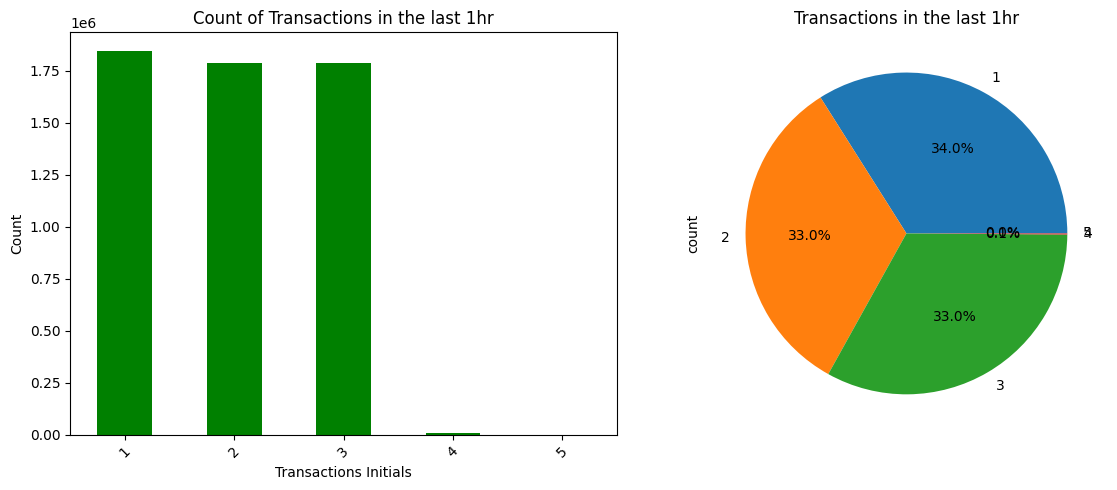

In [ ]:
# Visualization of tx_count_last_1hr Count
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart of transactions in the last 1hr
fdd['tx_count_last_1hr'].value_counts().plot(kind='bar', ax=axes[0], color='green')
axes[0].set_title('Count of Transactions in the last 1hr')
axes[0].set_xlabel('Transactions Initials')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart showing percentage distribution
fdd['tx_count_last_1hr'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Transactions in the last 1hr')

plt.tight_layout()
plt.show()

All the transaction count within their various time windows showed to be categorical columns, however, only the transaction count in the last 1hr would be displayed along with the percentage distribution. The others would be analysed further in the notebook.

From the visuals, users highest record of transactions in the last 1hr showed to be 1 count meaning the users averaged at least 1 transaction in i hr,and the lowest is 5 count which is realistic because in real world sense, it's rare for individuals to make transactions up to 5 times in 1hr and those who did fell under the outliers (4 and 5)

#### **REPORT EVALUATION- CATEGORICAL ANALYSIS**

The categorical analysis began by examining the unique values, value counts and number of unique values for key labelled columns. The hour_of_simulation column confirmed 720 unique values representing each hour of the 30-day simulation period, with the distribution visualized as a histogram and grouped into four weekly periods via a pie chart. The weekly breakdown revealed that Week 4 (Day 22–30) had the highest fraud concentration at 29.78%, while Weeks 1–3 maintained a relatively consistent rate of 22–24% each, suggesting an end-of-month surge in fraudulent activity.

The transaction_type column contains 5 unique values which are CASH_IN, CASH_OUT, PAYMENT, DEBIT and TRANSFER. CASH_IN is the most common transaction type with 2,257,040 transactions (41.6%), followed by PAYMENT at 1,494,517 (27.57%), CASH_OUT at 1,124,360 (20.74%), TRANSFER at 364,817 (6.73%) and DEBIT at 179,747 (3.31%). Despite being the least frequent types, TRANSFER and CASH_OUT carry the highest fraud risk, a pattern that becomes critical in the bivariate analysis.

The sender_id and receiver_id columns contain 35,394 and 40,399 unique values respectively. Due to their high cardinality, only the top 20 most frequent IDs were visualized. The sender_id showed a relatively even distribution among the top 20 which is suspicious, while the receiver_id showed a right-skewed distribution where only the top 5 had notably higher counts. These ID columns are not suitable as direct model features due to their high cardinality.

The fraud_label column reveals a significant class imbalance — 5,359,815 (98.88%) non-fraud versus 60,666 (1.12%) fraud transactions. This extreme imbalance is typical in real-world fraud detection scenarios and must be addressed before model training to prevent the model from simply predicting non-fraud for all cases. The unauthorized_overdraft_flag shows an even more extreme imbalance with 99.65% showing no unauthorized overdraft and only 0.35% flagged which, while reassuring from a real-world perspective, limits its discriminatory power as a model feature.

The transaction count columns (tx_count_last_1hr through tx_count_last_30days) are categorical in nature with limited unique values. The tx_count_last_1hr has only 5 unique values (1–5) showing an approximately uniform distribution where 33.97% of users made 1 transaction per hour. As the time window extends, the range and complexity of counts increases, with tx_count_last_30days ranging from 1 to 1,071 reflecting accumulated transaction history over a full month.


### **NUMERICAL FEATURES DISTRIBUTION**

#### **DESCRIPTIVE STATISTICS, SKEWNESS AND KURTOSIS ANALYSIS PER NUMERICAL COLUMN**

N.B: Skewness measures the direction of asymmetry i.e values between -0.5 and 0.5 indicate symmetry, values between 0.5 and 1 or -0.5 and -1 indicate moderate skew, and values beyond 1 or -1 indicate high skew. On the other hand, Kurtosis measures how sharp or flat the peak is i.e a value of approximately 3 is normal (mesokurtic), above 3 means a sharp peak with heavy tails (leptokurtic), and below 3 means a flat peak with light tails (platykurtic).

In [ ]:
# DESCRIPTIVE SUMMARY (Split in 2 for easier readability and understanding)
describe_1 = fdd[['row_id',
 'hour_of_simulation',
 'transaction_amount',
 'sender_balance_before',
 'sender_balance_after',
 'receiver_balance_before',
 'receiver_balance_after',
 'fraud_label',
 'unauthorized_overdraft_flag']].describe().round(2)

describe_1

,row_id,hour_of_simulation,transaction_amount,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,fraud_label,unauthorized_overdraft_flag
count,5420481.00,5420481.00,5420481.00,5420481.00,5420481.00,5420481.00,5420481.00,5420481.00,5420481.00
mean,2710240.00,346.99,152206.53,2836157.75,2803814.50,1094252.62,1141631.75,0.01,0.00
std,1564758.23,203.30,455361.06,1237068.00,1235388.88,940555.44,1019483.25,0.11,0.06
min,0.00,0.00,0.00,-198188.30,-198188.30,-103560.49,-56863.81,0.00,0.00
25%,1355120.00,187.00,9760.90,2124121.50,2095848.25,429482.56,457094.44,0.00,0.00
50%,2710240.00,332.00,86574.01,2983071.00,2968546.00,1005583.44,1032950.12,0.00,0.00
75%,4065360.00,520.00,160791.53,3527875.50,3513441.75,1640583.75,1662350.00,0.00,0.00
max,5420480.00,719.00,24638740.00,26118438.00,26104776.00,27622476.00,27867316.00,1.00,1.00


In [ ]:
describe_2 = fdd[['total_sent_last_1hr',
 'total_sent_last_1day',
 'total_sent_last_7days',
 'total_sent_last_30days',
 'tx_count_last_1hr',
 'tx_count_last_1day',
 'tx_count_last_7days',
 'tx_count_last_30days',
 'avg_amount_last_1hr',
 'avg_amount_last_1day',
 'avg_amount_last_7days',
 'avg_amount_last_30days']].describe().round(2)

describe_2

,total_sent_last_1hr,total_sent_last_1day,total_sent_last_7days,total_sent_last_30days,tx_count_last_1hr,tx_count_last_1day,tx_count_last_7days,tx_count_last_30days,avg_amount_last_1hr,avg_amount_last_1day,avg_amount_last_7days,avg_amount_last_30days
count,5420481.00,5420481.00,5.420481e+06,5.420481e+06,5420481.00,5420481.00,5420481.00,5420481.00,5420481.00,5420481.00,5420481.00,5420481.00
mean,278253.78,4893140.00,2.967602e+07,7.346050e+07,1.99,36.82,221.26,526.33,152715.89,153722.72,156328.08,162893.98
std,557963.44,3044721.25,1.496343e+07,4.354433e+07,0.82,11.04,73.89,309.09,422610.47,352140.62,349791.72,316953.06
min,0.04,0.06,6.000000e-02,6.000000e-02,1.00,1.00,1.00,1.00,0.04,0.06,0.06,0.06
25%,69248.34,2727706.00,1.969473e+07,3.382550e+07,1.00,32.00,209.00,259.00,38730.80,87224.07,104242.16,124314.98
50%,171166.83,4275936.00,2.715250e+07,7.796494e+07,2.00,38.00,237.00,526.00,92755.88,116550.38,129794.95,137498.59
75%,304943.41,6422119.00,3.967311e+07,1.088358e+08,3.00,44.00,277.00,794.00,150049.19,156264.44,154801.55,152546.48
max,26095260.00,47022224.00,1.061345e+08,2.551475e+08,5.00,69.00,318.00,1071.00,24638740.00,24638740.00,24638740.00,24638740.00


#### **INDIVIDUAL ANALYSIS OF NUMERICAL COLUMNS**

In [ ]:
# Descriptive Statistics, kurtosis and skewness of the transaction amount
describe = fdd['transaction_amount'].describe().round(2)
print('Descriptive statistics:')
print(describe)

skewness = fdd['transaction_amount'].skew()
kurtosis = fdd['transaction_amount'].kurt()

print(f'\nSkewness: {skewness:.3f}')
print(f'Kurtosis: {kurtosis:.3f}')

print('Skewness and Kurtosis Analysis:')
print('Skewness Analysis:')
if -0.5 <= skewness <= 0.5:
    print('>> The transaction amount data is approximately symmetric i.e it is evenly spread around the mean')
elif 0.5 < skewness <= 1:
    print('>> The transaction amount data is moderately right skewed i.e more values on the left, tail on the right')
elif skewness > 1:
    print('>> The transaction amount data is highly right skewed i.e most values are low, few extremely high values')
elif -1 <= skewness < -0.5:
    print('>> The transaction amount data is moderately left skewed i.e more values on the right, tail on the left')
elif skewness < -1:
    print('>> The transaction amount data is highly left skewed i.e most values are high, few extremely low values')
else:
    print('incorrect code input')

# KURTOSIS INTERPRETATION
print('\nKurtosis Analysis:')
if 2.5 <= kurtosis <= 3.5:
    print('>> The distribution is Mesokurtic i.e it is normally distributed, moderate tails, no extreme outliers')
elif kurtosis > 3.5:
    print('>> The distribution is Leptokurtic i.e there is a sharp peak, heavy tails, likely has extreme outliers')
elif kurtosis < 2.5:
    print('>> The distribution is Platykurtic i.e flat peak, light tails, values are more evenly spread')
else:
    print('Wrong Code Syntax')

Descriptive statistics:
count     5420481.00
mean       152206.53
std        455361.06
min             0.00
25%          9760.90
50%         86574.01
75%        160791.53
max      24638740.00
Name: transaction_amount, dtype: float64

Skewness: 12.622
Kurtosis: 230.642
Skewness and Kurtosis Analysis:
Skewness Analysis:
>> The transaction amount data is highly right skewed i.e most values are low, few extremely high values

Kurtosis Analysis:
>> The distribution is Leptokurtic i.e there is a sharp peak, heavy tails, likely has extreme outliers


From the descriptive summary, skewness and kurtosis analysis, of the transaction amount, it is shown that the dataset tends to be heavily skewed to the right as the skewness analysis is 12.62 and from the kurtosis, the transaction amount shows that there seem to be a sharp peak tendency with heavy tails and extreme outliers and the values seems to be spread below the mean. This analysis complements the descriptive the summary because the std lies below the mean  which means that the dataset is spread quite below the mean and as shown in the min being 0 and max being 24,638,739 where 75% of the dataset lies between 0 and 160,791. The visualization would further be shown for confirmation.

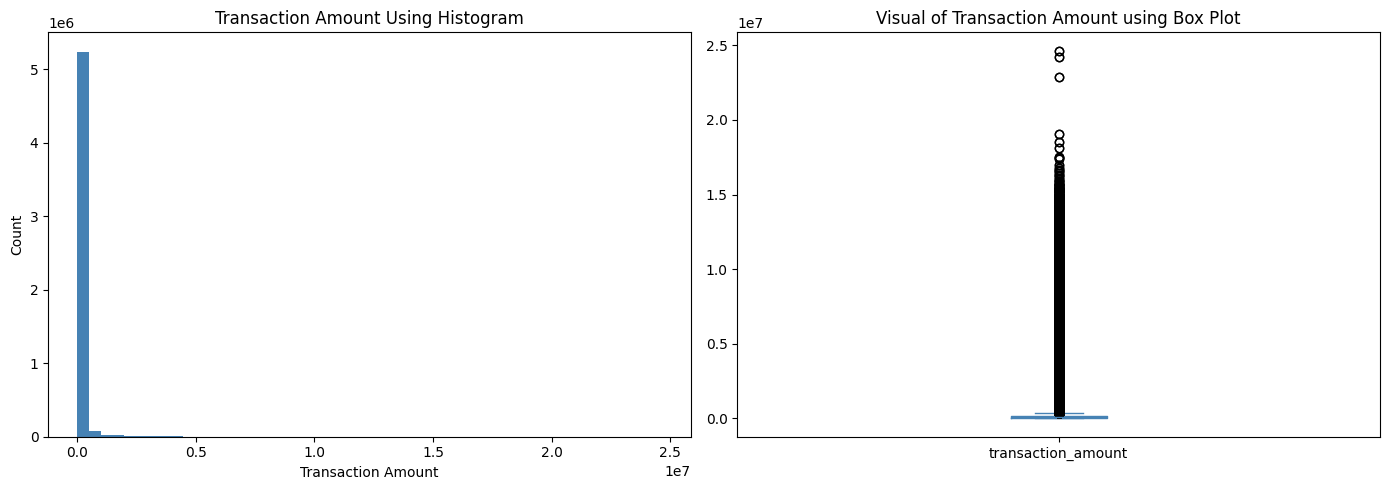

In [ ]:
# VISUALIZATION OF TRANSACTION AMOUNT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram - shows frequency of each amount range
transaction_amount = fdd['transaction_amount']
transaction_amount.plot(kind='hist', bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Transaction Amount Using Histogram')
axes[0].set_xlabel('Transaction Amount')
axes[0].set_ylabel('Count')

# Boxplot - shows outliers and spread
t_amount = fdd['transaction_amount']
t_amount.plot(kind='box', ax=axes[1], color='steelblue')
axes[1].set_title('Visual of Transaction Amount using Box Plot')

plt.tight_layout()
plt.show()

From the visuals, the data shows to be heavily skewed dataset where majority of the data are clustered arounf the lower values distributed to the right and extreme outliers as seen in the box plot confirmed by the descriptive summary, skewness and kurtosis analysis.

In [ ]:
# Descriptive Statistics, kurtosis and skewness of Sender's Balance before Transaction
describe = fdd['sender_balance_before'].describe().round(2)
print('Descriptive statistics:')
print(describe)

skewness = fdd['sender_balance_before'].skew()
kurtosis = fdd['sender_balance_before'].kurt()

print(f'\nSkewness: {skewness:.3f}')
print(f'Kurtosis: {kurtosis:.3f}')

print('Skewness and Kurtosis Analysis:')
print('Skewness Analysis:')
if -0.5 <= skewness <= 0.5:
    print('>> The data is approximately symmetric i.e it is evenly spread around the mean')
elif 0.5 < skewness <= 1:
    print('>> The data is moderately right skewed i.e more values on the left, tail on the right')
elif skewness > 1:
    print('>> The data is highly right skewed i.e most values are low, few extremely high values')
elif -1 <= skewness < -0.5:
    print('>> The data is moderately left skewed i.e more values on the right, tail on the left')
elif skewness < -1:
    print('>> The data is highly left skewed i.e most values are high, few extremely low values')
else:
    print('incorrect code input')

# KURTOSIS INTERPRETATION
print('\nKurtosis Analysis:')
if 2.5 <= kurtosis <= 3.5:
    print('>> The distribution is Mesokurtic i.e it is normally distributed, moderate tails, no extreme outliers')
elif kurtosis > 3.5:
    print('>> The distribution is Leptokurtic i.e there is a sharp peak, heavy tails, likely has extreme outliers')
elif kurtosis < 2.5:
    print('>> The distribution is Platykurtic i.e flat peak, light tails, values are more evenly spread')
else:
    print('Wrong Code Syntax')

Descriptive statistics:
count     5420481.00
mean      2836157.75
std       1237068.00
min       -198188.30
25%       2124121.50
50%       2983071.00
75%       3527875.50
max      26118438.00
Name: sender_balance_before, dtype: float64

Skewness: 1.121
Kurtosis: 14.579
Skewness and Kurtosis Analysis:
Skewness Analysis:
>> The data is highly right skewed i.e most values are low, few extremely high values

Kurtosis Analysis:
>> The distribution is Leptokurtic i.e there is a sharp peak, heavy tails, likely has extreme outliers


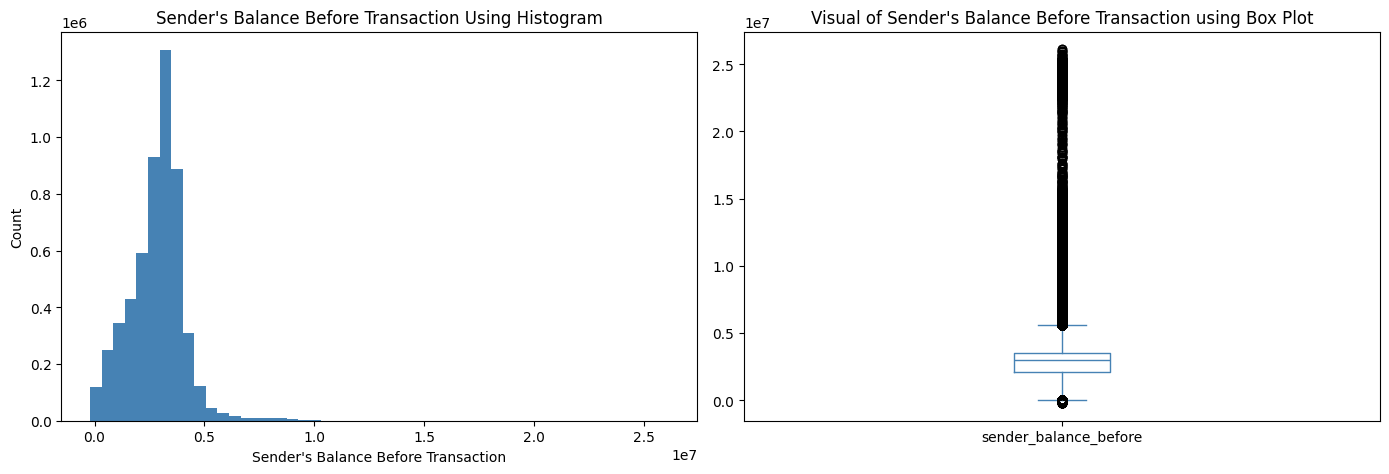

In [ ]:
# VISUALIZATION OF SENDER'S BALANCE BEFORE USING BOXPLOT AND HISTOGRAM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram - shows frequency of each amount range
transaction_amount = fdd['sender_balance_before']
transaction_amount.plot(kind='hist', bins=50, ax=axes[0], color='steelblue')
axes[0].set_title("Sender's Balance Before Transaction Using Histogram")
axes[0].set_xlabel("Sender's Balance Before Transaction")
axes[0].set_ylabel('Count')

# Boxplot - shows outliers and spread
t_amount = fdd['sender_balance_before']
t_amount.plot(kind='box', ax=axes[1], color='steelblue')
axes[1].set_title("Visual of Sender's Balance Before Transaction using Box Plot")

plt.tight_layout()
plt.show()

From the descriptive summary, skewness and kurtosis analysis, of the sender's balance before, it is shown that the dataset is also heavily skewed to the right as the skewness analysis is 1.21 and from the kurtosis, the sender's balance before trransaction shows that there seem to be a sharp peak tendency with heavy tails and extreme outliers and the values seems to be spread below the mean. This analysis complements the descriptive the summary because the std lies below the mean  which means that the dataset is spread quite below the mean and as shown in the min being -198188.29 (indicator of debtors) and max being 26,118,437.63 where 75% of the dataset lies between 0 and 3,527,875.47. The visualization also confirms the analysis because from the visuals, the data shows to be heavily skewed dataset where majority of the data are clustered around the lower values and distributed to the right and extreme outliers as seen in the box plot confirmed by the descriptive summary, skewness and kurtosis analysis..

This also complements the viability of the dataset as a whole because from the transaction amount consisting of transactions with mostly low values, the balance before those transactions shows the capacity of the users financial strength and that is why there are majorly low balances of the sender's account before the transaction although it is not a full measure for conclusion as there could be cases where sender's with high balance makes low value transactions and vice versa (in the case of debtors) which constitutes to the outliers as visualized in the boxplot.

In [ ]:
# Descriptive Statistics, kurtosis and skewness of Sender's Balance After Transaction
describe = fdd['sender_balance_after'].describe().round(2)
print('Descriptive statistics:')
print(describe)

skewness = fdd['sender_balance_after'].skew()
kurtosis = fdd['sender_balance_after'].kurt()

print(f'\nSkewness: {skewness:.3f}')
print(f'Kurtosis: {kurtosis:.3f}')

print('Skewness and Kurtosis Analysis:')
print('Skewness Analysis:')
if -0.5 <= skewness <= 0.5:
    print('>> The data is approximately symmetric i.e it is evenly spread around the mean')
elif 0.5 < skewness <= 1:
    print('>> The data is moderately right skewed i.e more values on the left, tail on the right')
elif skewness > 1:
    print('>> The data is highly right skewed i.e most values are low, few extremely high values')
elif -1 <= skewness < -0.5:
    print('>> The data is moderately left skewed i.e more values on the right, tail on the left')
elif skewness < -1:
    print('>> The data is highly left skewed i.e most values are high, few extremely low values')
else:
    print('incorrect code input')

# KURTOSIS INTERPRETATION
print('\nKurtosis Analysis:')
if 2.5 <= kurtosis <= 3.5:
    print('>> The distribution is Mesokurtic i.e it is normally distributed, moderate tails, no extreme outliers')
elif kurtosis > 3.5:
    print('>> The distribution is Leptokurtic i.e there is a sharp peak, heavy tails, likely has extreme outliers')
elif kurtosis < 2.5:
    print('>> The distribution is Platykurtic i.e flat peak, light tails, values are more evenly spread')
else:
    print('Wrong Code Syntax')

Descriptive statistics:
count     5420481.00
mean      2803814.50
std       1235388.88
min       -198188.30
25%       2095848.25
50%       2968546.00
75%       3513441.75
max      26104776.00
Name: sender_balance_after, dtype: float64

Skewness: 0.945
Kurtosis: 13.804
Skewness and Kurtosis Analysis:
Skewness Analysis:
>> The data is moderately right skewed i.e more values on the left, tail on the right

Kurtosis Analysis:
>> The distribution is Leptokurtic i.e there is a sharp peak, heavy tails, likely has extreme outliers


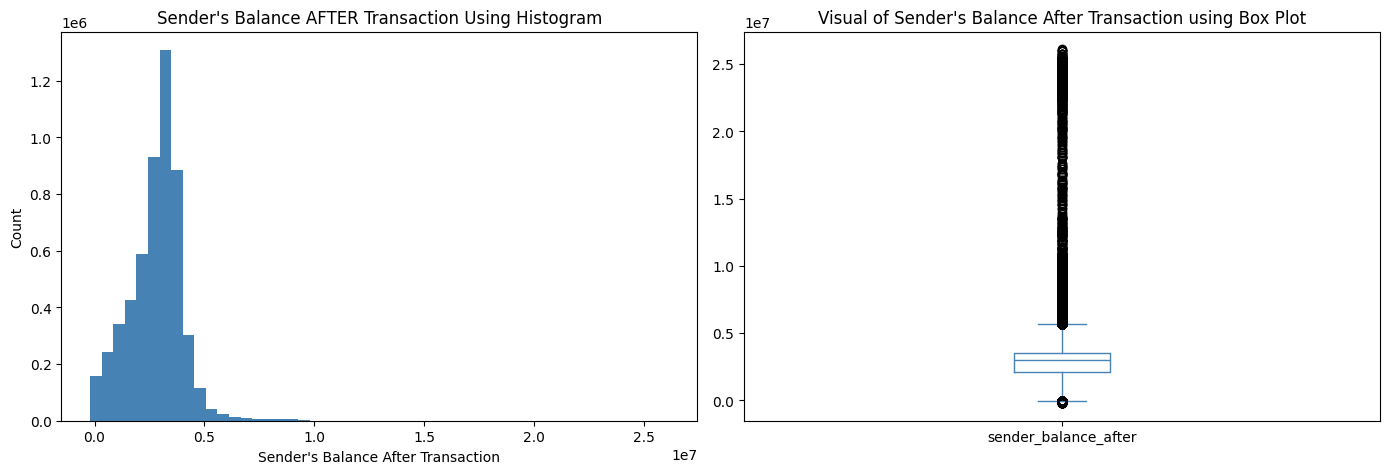

In [ ]:
# VISUALIZATION OF SENDER'S BALANCE AFTER USING BOXPLOT AND HISTOGRAM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram - shows frequency of each amount range
transaction_amount = fdd['sender_balance_after']
transaction_amount.plot(kind='hist', bins=50, ax=axes[0], color='steelblue')
axes[0].set_title("Sender's Balance AFTER Transaction Using Histogram")
axes[0].set_xlabel("Sender's Balance After Transaction")
axes[0].set_ylabel('Count')

# Boxplot - shows outliers and spread
t_amount = fdd['sender_balance_after']
t_amount.plot(kind='box', ax=axes[1], color='steelblue')
axes[1].set_title("Visual of Sender's Balance After Transaction using Box Plot")

plt.tight_layout()
plt.show()

From the descriptive summary, skewness and kurtosis analysis, of the sender's balance after transaction, it is shown that the dataset is moderately skewed to the right compared to the sender's balance after transaction as the skewness analysis is 0.95 and from the kurtosis, the sender's balance before trransaction shows that there seem to be a sharp peak tendency with heavy tails and extreme outliers and the values seems to be spread below the mean. This analysis complements the descriptive the summary because the std lies below the mean which means that the dataset is spread quite below the mean and as shown in the min being -198188.29 (indicator of debtors) and max being 26,104,775.65 where 75% of the dataset lies between 0 and 3,513,441.64. The visualization also confirms the analysis because from the visuals, the data shows to be heavily skewed dataset where majority of the data are clustered around the lower values and distributed to the right and extreme outliers as seen in the box plot confirmed by the descriptive summary, skewness and kurtosis analysis..

This further complements the balance of the sender before transaction analysis since majority of the transactions were low values, it is expected that the balance after should either remain the same of reduce but not so drastically, there are still cases of outliers though which is visualized in the boxplot

In [ ]:
# Descriptive Statistics, kurtosis and skewness of Receiver's Balance Before Transaction
describe = fdd['receiver_balance_before'].describe().round(2)
print('Descriptive statistics:')
print(describe)

skewness = fdd['receiver_balance_before'].skew()
kurtosis = fdd['receiver_balance_before'].kurt()

print(f'\nSkewness: {skewness:.3f}')
print(f'Kurtosis: {kurtosis:.3f}')

print('Skewness and Kurtosis Analysis:')
# SKEWNESS INTERPRETATION
print('Skewness Analysis:')
if -0.5 <= skewness <= 0.5:
    print('>> The data is approximately symmetric i.e it is evenly spread around the mean')
elif 0.5 < skewness <= 1:
    print('>> The data is moderately right skewed i.e more values on the left, tail on the right')
elif skewness > 1:
    print('>> The data is highly right skewed i.e most values are low, few extremely high values')
elif -1 <= skewness < -0.5:
    print('>> The data is moderately left skewed i.e more values on the right, tail on the left')
elif skewness < -1:
    print('>> The data is highly left skewed i.e most values are high, few extremely low values')
else:
    print('incorrect code input')

# KURTOSIS INTERPRETATION
print('\nKurtosis Analysis:')
if 2.5 <= kurtosis <= 3.5:
    print('>> The distribution is Mesokurtic i.e it is normally distributed, moderate tails, no extreme outliers')
elif kurtosis > 3.5:
    print('>> The distribution is Leptokurtic i.e there is a sharp peak, heavy tails, likely has extreme outliers')
elif kurtosis < 2.5:
    print('>> The distribution is Platykurtic i.e flat peak, light tails, values are more evenly spread')
else:
    print('Wrong Code Syntax')

Descriptive statistics:
count     5420481.00
mean      1094252.62
std        940555.44
min       -103560.49
25%        429482.56
50%       1005583.44
75%       1640583.75
max      27622476.00
Name: receiver_balance_before, dtype: float64

Skewness: 3.661
Kurtosis: 35.139
Skewness and Kurtosis Analysis:
Skewness Analysis:
>> The data is highly right skewed i.e most values are low, few extremely high values

Kurtosis Analysis:
>> The distribution is Leptokurtic i.e there is a sharp peak, heavy tails, likely has extreme outliers


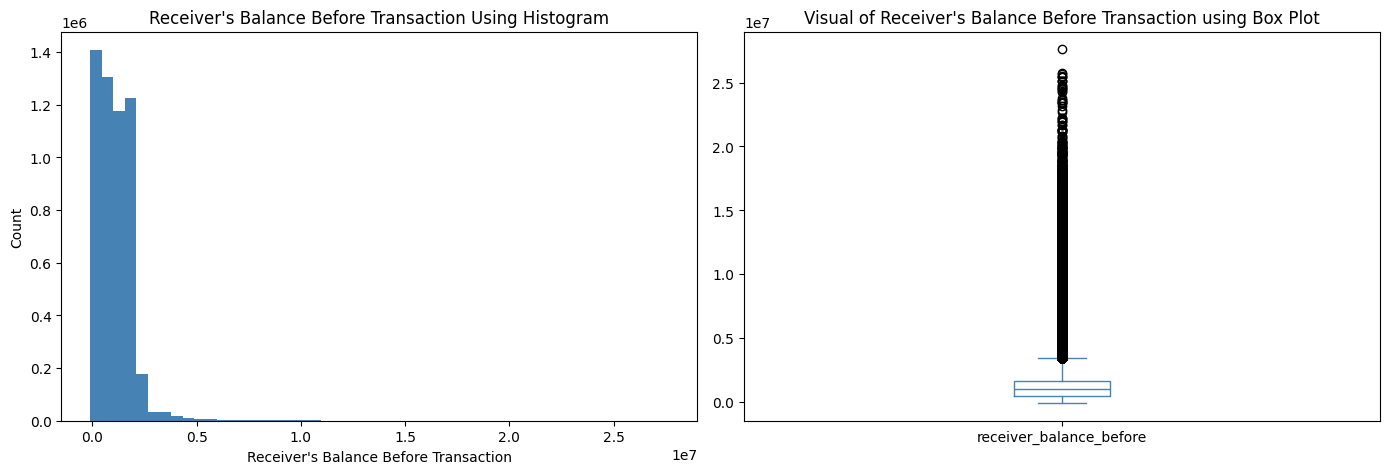

In [ ]:
# VISUALIZATION OF Receiver's Balance Before Transaction USING BOXPLOT AND HISTOGRAM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram - shows frequency of each amount range
transaction_amount = fdd['receiver_balance_before']
transaction_amount.plot(kind='hist', bins=50, ax=axes[0], color='steelblue')
axes[0].set_title("Receiver's Balance Before Transaction Using Histogram")
axes[0].set_xlabel("Receiver's Balance Before Transaction")
axes[0].set_ylabel('Count')

# Boxplot - shows outliers and spread
t_amount = fdd['receiver_balance_before']
t_amount.plot(kind='box', ax=axes[1], color='steelblue')
axes[1].set_title("Visual of Receiver's Balance Before Transaction using Box Plot")

plt.tight_layout()
plt.show()

From the descriptive summary, skewness and kurtosis analysis, of the receiver's balance before transaction, it is shown that the dataset is heavily skewed to the right as the skewness analysis is 3.661 and from the kurtosis, the receiver's balance before trransaction shows that there seem to be a sharp peak tendency with heavy tails and extreme outliers and the values seems to be spread below the mean. This analysis complements the descriptive the summary because the std lies below the mean which means that the dataset is spread quite below the mean and as shown in the min being -103560.49 (indicator of debtors) and max being 27,622,475.32 where 75% of the dataset lies between 0 and  1,640,583.81. The visualization also confirms the analysis because from the visuals, the data shows to be heavily skewed dataset where majority of the data are clustered around the lower values and distributed to the right and extreme outliers as seen in the box plot confirmed by the descriptive summary, skewness and kurtosis analysis..

In [ ]:
# Descriptive Statistics, kurtosis and skewness of Receiver's Balance After Transaction
describe = fdd['receiver_balance_after'].describe().round(2)
print('Descriptive statistics:')
print(describe)

skewness = fdd['receiver_balance_after'].skew()
kurtosis = fdd['receiver_balance_after'].kurt()

print(f'\nSkewness: {skewness:.3f}')
print(f'Kurtosis: {kurtosis:.3f}')

print('Skewness and Kurtosis Analysis:')
# SKEWNESS INTERPRETATION
print('Skewness Analysis:')
if -0.5 <= skewness <= 0.5:
    print('>> The data is approximately symmetric i.e it is evenly spread around the mean')
elif 0.5 < skewness <= 1:
    print('>> The data is moderately right skewed i.e more values on the left, tail on the right')
elif skewness > 1:
    print('>> The data is highly right skewed i.e most values are low, few extremely high values')
elif -1 <= skewness < -0.5:
    print('>> The data is moderately left skewed i.e more values on the right, tail on the left')
elif skewness < -1:
    print('>> The data is highly left skewed i.e most values are high, few extremely low values')
else:
    print('incorrect code input')

# KURTOSIS INTERPRETATION
print('\nKurtosis Analysis:')
if 2.5 <= kurtosis <= 3.5:
    print('>> The distribution is Mesokurtic i.e it is normally distributed, moderate tails, no extreme outliers')
elif kurtosis > 3.5:
    print('>> The distribution is Leptokurtic i.e there is a sharp peak, heavy tails, likely has extreme outliers')
elif kurtosis < 2.5:
    print('>> The distribution is Platykurtic i.e flat peak, light tails, values are more evenly spread')
else:
    print('Wrong Code Syntax')

Descriptive statistics:
count     5420481.00
mean      1141631.75
std       1019483.25
min        -56863.81
25%        457094.44
50%       1032950.12
75%       1662350.00
max      27867316.00
Name: receiver_balance_after, dtype: float64

Skewness: 3.859
Kurtosis: 33.598
Skewness and Kurtosis Analysis:
Skewness Analysis:
>> The data is highly right skewed i.e most values are low, few extremely high values

Kurtosis Analysis:
>> The distribution is Leptokurtic i.e there is a sharp peak, heavy tails, likely has extreme outliers


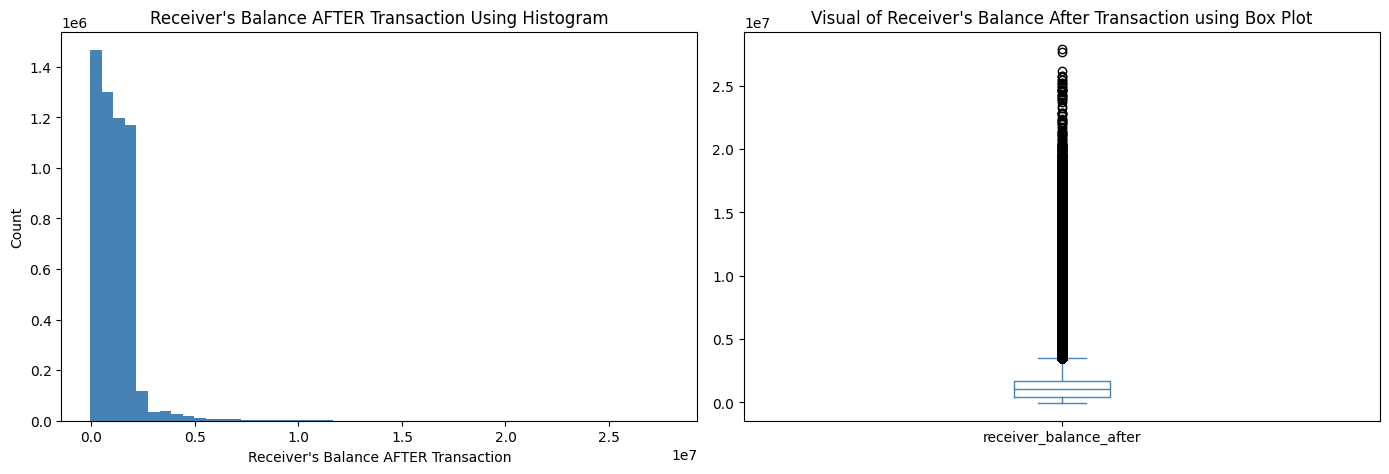

In [ ]:
# VISUALIZATION OF Receiver's Balance Before Transaction USING BOXPLOT AND HISTOGRAM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram - shows frequency of each amount range
transaction_amount = fdd['receiver_balance_after']
transaction_amount.plot(kind='hist', bins=50, ax=axes[0], color='steelblue')
axes[0].set_title("Receiver's Balance AFTER Transaction Using Histogram")
axes[0].set_xlabel("Receiver's Balance AFTER Transaction")
axes[0].set_ylabel('Count')

# Boxplot - shows outliers and spread
t_amount = fdd['receiver_balance_after']
t_amount.plot(kind='box', ax=axes[1], color='steelblue')
axes[1].set_title("Visual of Receiver's Balance After Transaction using Box Plot")

plt.tight_layout()
plt.show()

From the descriptive summary, skewness and kurtosis analysis, of the receiver's balance after transaction, it is shown that the dataset is heavily skewed to the right as the skewness analysis is 3.661 and from the kurtosis, the receiver's balance after transaction shows that there seem to be a sharp peak tendency with heavy tails and extreme outliers and the values seems to be spread below the mean. This analysis complements the descriptive the summary because the std lies below the mean which means that the dataset is spread quite below the mean and as shown in the min being -103560.49 (indicator of debtors) and max being 27,622,475.32 where 75% of the dataset lies between 0 and  1,640,583.81. The visualization also confirms the analysis because from the visuals, the data shows to be heavily skewed dataset where majority of the data are clustered around the lower values and distributed to the right and extreme outliers as seen in the box plot confirmed by the descriptive summary, skewness and kurtosis analysis..

This also complements the receiver before transaction analysis since majority of the transactions received were low values, it is expected that the balance after should either remain the same of slightly increase, there are still cases of outliers though which is visualized in the boxplot

In [ ]:
# Descriptive Statistics, kurtosis and skewness of All transaction amout sent in the Last 1hr
describe = fdd['total_sent_last_1hr'].describe().round(2)
print('Descriptive statistics:')
print(describe)

skewness = fdd['total_sent_last_1hr'].skew()
kurtosis = fdd['total_sent_last_1hr'].kurt()

print(f'\nSkewness: {skewness:.3f}')
print(f'Kurtosis: {kurtosis:.3f}')

print('Skewness and Kurtosis Analysis:')
# SKEWNESS INTERPRETATION
print('Skewness Analysis:')
if -0.5 <= skewness <= 0.5:
    print('>> The data is approximately symmetric i.e it is evenly spread around the mean')
elif 0.5 < skewness <= 1:
    print('>> The data is moderately right skewed i.e more values on the left, tail on the right')
elif skewness > 1:
    print('>> The data is highly right skewed i.e most values are low, few extremely high values')
elif -1 <= skewness < -0.5:
    print('>> The data is moderately left skewed i.e more values on the right, tail on the left')
elif skewness < -1:
    print('>> The data is highly left skewed i.e most values are high, few extremely low values')
else:
    print('incorrect code input')

# KURTOSIS INTERPRETATION
print('\nKurtosis Analysis:')
if 2.5 <= kurtosis <= 3.5:
    print('>> The distribution is Mesokurtic i.e it is normally distributed, moderate tails, no extreme outliers')
elif kurtosis > 3.5:
    print('>> The distribution is Leptokurtic i.e there is a sharp peak, heavy tails, likely has extreme outliers')
elif kurtosis < 2.5:
    print('>> The distribution is Platykurtic i.e flat peak, light tails, values are more evenly spread')
else:
    print('Wrong Code Syntax')

Descriptive statistics:
count     5420481.00
mean       278253.78
std        557963.44
min             0.04
25%         69248.34
50%        171166.83
75%        304943.41
max      26095260.00
Name: total_sent_last_1hr, dtype: float64

Skewness: 9.279
Kurtosis: 136.195
Skewness and Kurtosis Analysis:
Skewness Analysis:
>> The data is highly right skewed i.e most values are low, few extremely high values

Kurtosis Analysis:
>> The distribution is Leptokurtic i.e there is a sharp peak, heavy tails, likely has extreme outliers


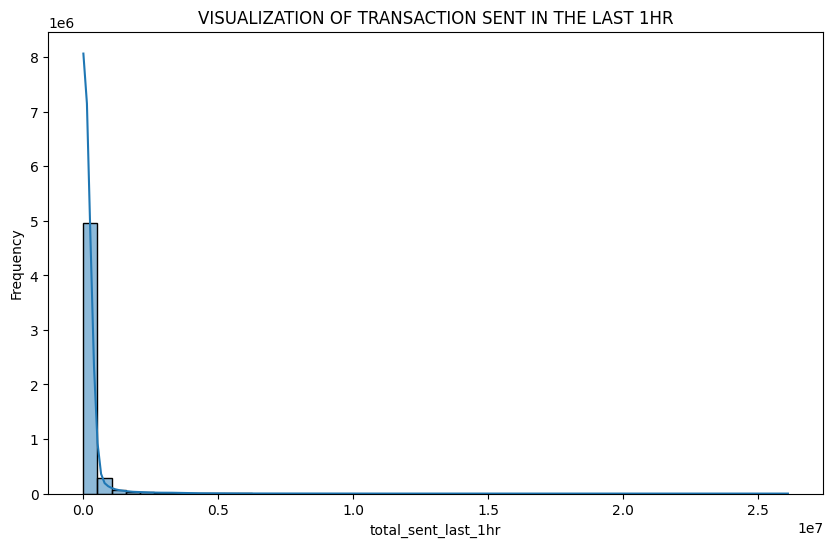

In [ ]:
#VIZUALIZING THE TOTAl TRANSACTIONS sent IN THE LAST 1HR USING HISTOGRAM
plt.figure(figsize=(10, 6))
sns.histplot(data=fdd, x= 'total_sent_last_1hr', kde= True, bins=50)
plt.title('VISUALIZATION OF TRANSACTION SENT IN THE LAST 1HR')
plt.xlabel('total_sent_last_1hr')
plt.ylabel('Frequency')

plt.show()

From the descriptive summary, skewness and kurtosis analysis, of the transaction amount sent in the last 1hr, it is shown that the dataset is heavily skewed to the right as the skewness analysis is 9.279 and from the kurtosis, amount sent in the last 1hr shows that there seem to be a sharp peak tendency with heavy tails and extreme outliers and the values seems to be spread below the mean. This analysis complements the descriptive the summary because the std lies below the mean which means that the dataset is spread quite below the mean and as shown in the min being  0.04 and max being 26,095,260.53 where 75% of the dataset lies between 0 and 304,943.42. The visualization also confirms the analysis because from the visuals, the data shows to be heavily skewed dataset where majority of the data are clustered around the lower values and distributed to the right confirmed by the descriptive summary, skewness and kurtosis analysis..

In [ ]:
# Descriptive Statistics, kurtosis and skewness of All transaction sent in the Last 1DAY
describe = fdd['total_sent_last_1day'].describe().round(2)
print('Descriptive statistics:')
print(describe)

skewness = fdd['total_sent_last_1day'].skew()
kurtosis = fdd['total_sent_last_1day'].kurt()

print(f'\nSkewness: {skewness:.3f}')
print(f'Kurtosis: {kurtosis:.3f}')

print('Skewness and Kurtosis Analysis:')
# SKEWNESS INTERPRETATION
print('Skewness Analysis:')
if -0.5 <= skewness <= 0.5:
    print('>> The data is approximately symmetric i.e it is evenly spread around the mean')
elif 0.5 < skewness <= 1:
    print('>> The data is moderately right skewed i.e more values on the left, tail on the right')
elif skewness > 1:
    print('>> The data is highly right skewed i.e most values are low, few extremely high values')
elif -1 <= skewness < -0.5:
    print('>> The data is moderately left skewed i.e more values on the right, tail on the left')
elif skewness < -1:
    print('>> The data is highly left skewed i.e most values are high, few extremely low values')
else:
    print('incorrect code input')

# KURTOSIS INTERPRETATION
print('\nKurtosis Analysis:')
if 2.5 <= kurtosis <= 3.5:
    print('>> The distribution is Mesokurtic i.e it is normally distributed, moderate tails, no extreme outliers')
elif kurtosis > 3.5:
    print('>> The distribution is Leptokurtic i.e there is a sharp peak, heavy tails, likely has extreme outliers')
elif kurtosis < 2.5:
    print('>> The distribution is Platykurtic i.e flat peak, light tails, values are more evenly spread')
else:
    print('Wrong Code Syntax')

Descriptive statistics:
count     5420481.00
mean      4893140.00
std       3044721.25
min             0.06
25%       2727706.00
50%       4275936.00
75%       6422119.00
max      47022224.00
Name: total_sent_last_1day, dtype: float64

Skewness: 1.984
Kurtosis: 9.183
Skewness and Kurtosis Analysis:
Skewness Analysis:
>> The data is highly right skewed i.e most values are low, few extremely high values

Kurtosis Analysis:
>> The distribution is Leptokurtic i.e there is a sharp peak, heavy tails, likely has extreme outliers


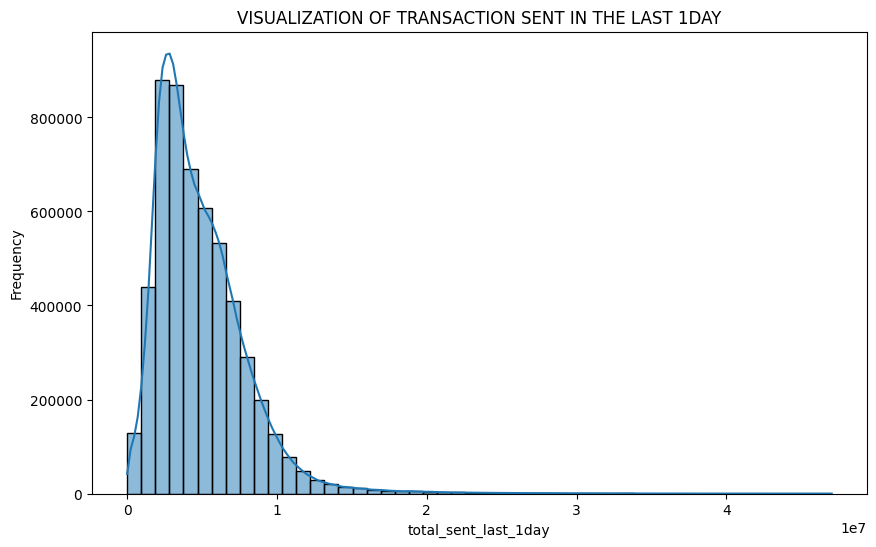

In [ ]:
#VIZUALIZING THE ALL TRANSACTION SENT IN THE LAST 1DAY USING HISTOGRAM
plt.figure(figsize=(10, 6))
sns.histplot(data=fdd, x= 'total_sent_last_1day', kde= True, bins=50)
plt.title('VISUALIZATION OF TRANSACTION SENT IN THE LAST 1DAY')
plt.xlabel('total_sent_last_1day')
plt.ylabel('Frequency')

plt.show()

From the descriptive summary, skewness and kurtosis analysis, of the transaction amount sent in the last 1 day, it is shown that the dataset is also heavily skewed to the right as the skewness analysis is 1.984 and from the kurtosis, amount sent in the last 1 day shows that there seem to be a sharp peak tendency with heavy tails and extreme outliers and the values seems to be spread below the mean. This analysis complements the descriptive the summary because the std lies below the mean which means that the dataset is spread quite below the mean and as shown in the min being  0.04 and max being 26,095,260.53 where 75% of the dataset lies between 0 and 304,943.42. The visualization also confirms the analysis because from the visuals, the data shows to be heavily skewed dataset where majority of the data are clustered around the lower values and distributed to the right confirmed by the descriptive summary, skewness and kurtosis analysis..

There also seems to be an increase in the total amount sent per day compeared to the per hour although the data is still heavily skewed to the lower values. From this, we can deduce that the longer the time window, the higher the transaction amount sent with by unique users within that time period.

In [ ]:
# Descriptive Statistics, kurtosis and skewness of All transaction SENT in the Last 7days
describe = fdd['total_sent_last_7days'].describe().round(1)
print('Descriptive statistics:')
print(describe)

skewness = fdd['total_sent_last_7days'].skew()
kurtosis = fdd['total_sent_last_7days'].kurt()

print(f'\nSkewness: {skewness:.3f}')
print(f'Kurtosis: {kurtosis:.3f}')

print('Skewness and Kurtosis Analysis:')
# SKEWNESS INTERPRETATION
print('Skewness Analysis:')
if -0.5 <= skewness <= 0.5:
    print('>> The data is approximately symmetric i.e it is evenly spread around the mean')
elif 0.5 < skewness <= 1:
    print('>> The data is moderately right skewed i.e more values on the left, tail on the right')
elif skewness > 1:
    print('>> The data is highly right skewed i.e most values are low, few extremely high values')
elif -1 <= skewness < -0.5:
    print('>> The data is moderately left skewed i.e more values on the right, tail on the left')
elif skewness < -1:
    print('>> The data is highly left skewed i.e most values are high, few extremely low values')
else:
    print('incorrect code input')

# KURTOSIS INTERPRETATION
print('\nKurtosis Analysis:')
if 2.5 <= kurtosis <= 3.5:
    print('>> The distribution is Mesokurtic i.e it is normally distributed, moderate tails, no extreme outliers')
elif kurtosis > 3.5:
    print('>> The distribution is Leptokurtic i.e there is a sharp peak, heavy tails, likely has extreme outliers')
elif kurtosis < 2.5:
    print('>> The distribution is Platykurtic i.e flat peak, light tails, values are more evenly spread')
else:
    print('Wrong Code Syntax')

Descriptive statistics:
count      5420481.0
mean      29676016.0
std       14963429.0
min              0.1
25%       19694732.0
50%       27152500.0
75%       39673112.0
max      106134456.0
Name: total_sent_last_7days, dtype: float64

Skewness: 0.518
Kurtosis: 0.175
Skewness and Kurtosis Analysis:
Skewness Analysis:
>> The data is moderately right skewed i.e more values on the left, tail on the right

Kurtosis Analysis:
>> The distribution is Platykurtic i.e flat peak, light tails, values are more evenly spread


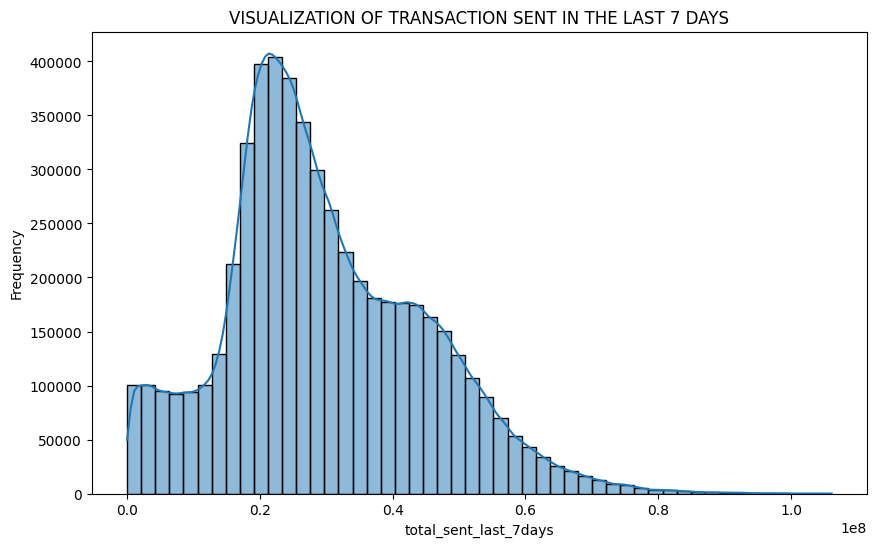

In [ ]:
#VIZUALIZING THE ALL TRANSACTION SENT IN THE LAST 7DAYS USING HISTOGRAM
plt.figure(figsize=(10, 6))
sns.histplot(data=fdd, x= 'total_sent_last_7days', kde= True, bins=50)
plt.title('VISUALIZATION OF TRANSACTION SENT IN THE LAST 7 DAYS')
plt.xlabel('total_sent_last_7days')
plt.ylabel('Frequency')

plt.show()

From the descriptive summary, skewness and kurtosis analysis, of the transaction amount sent in the last 7 days, it is shown that the dataset is moderately right skewed i.e more values on the left, tail on the right as the skewness analysis is 0.518 and from the kurtosis, the sender's balance before trransaction shows that there seem to be a sharp peak tendency with heavy tails and extreme outliers and the values seems to be spread below the mean. This analysis complements the descriptive the summary because the std lies below the mean which means that the dataset is spread quite below the mean and as shown in the min being 0.1 and max being 106,134,459.8 where 75% of the dataset lies between 0 and 39,673,113.6. The visualization also confirms the analysis because from the visuals, the data shows to be moderately skewed dataset although majority of the data are still clustered around the lower values and distributed to the right confirmed by the descriptive summary, skewness and kurtosis analysis..

This, further confirms that the longer the time window, the higher the transaction amount sent with by unique users within that time period and the better the distribution balance.

In [ ]:
# Descriptive Statistics, kurtosis and skewness of All transaction SENT in the Last 30 days
describe = fdd['total_sent_last_30days'].describe().round(1)
print('Descriptive statistics:')
print(describe)

skewness = fdd['total_sent_last_30days'].skew()
kurtosis = fdd['total_sent_last_30days'].kurt()

print(f'\nSkewness: {skewness:.3f}')
print(f'Kurtosis: {kurtosis:.3f}')

print('Skewness and Kurtosis Analysis:')
# SKEWNESS INTERPRETATION
print('Skewness Analysis:')
if -0.5 <= skewness <= 0.5:
    print('>> The data is approximately symmetric i.e it is evenly spread around the mean')
elif 0.5 < skewness <= 1:
    print('>> The data is moderately right skewed i.e more values on the left, tail on the right')
elif skewness > 1:
    print('>> The data is highly right skewed i.e most values are low, few extremely high values')
elif -1 <= skewness < -0.5:
    print('>> The data is moderately left skewed i.e more values on the right, tail on the left')
elif skewness < -1:
    print('>> The data is highly left skewed i.e most values are high, few extremely low values')
else:
    print('incorrect code input')

# KURTOSIS INTERPRETATION
print('\nKurtosis Analysis:')
if 2.5 <= kurtosis <= 3.5:
    print('>> The distribution is Mesokurtic i.e it is normally distributed, moderate tails, no extreme outliers')
elif kurtosis > 3.5:
    print('>> The distribution is Leptokurtic i.e there is a sharp peak, heavy tails, likely has extreme outliers')
elif kurtosis < 2.5:
    print('>> The distribution is Platykurtic i.e flat peak, light tails, values are more evenly spread')
else:
    print('Wrong Code Syntax')

Descriptive statistics:
count      5420481.0
mean      73460496.0
std       43544328.0
min              0.1
25%       33825504.0
50%       77964944.0
75%      108835760.0
max      255147520.0
Name: total_sent_last_30days, dtype: float64

Skewness: 0.028
Kurtosis: -0.971
Skewness and Kurtosis Analysis:
Skewness Analysis:
>> The data is approximately symmetric i.e it is evenly spread around the mean

Kurtosis Analysis:
>> The distribution is Platykurtic i.e flat peak, light tails, values are more evenly spread


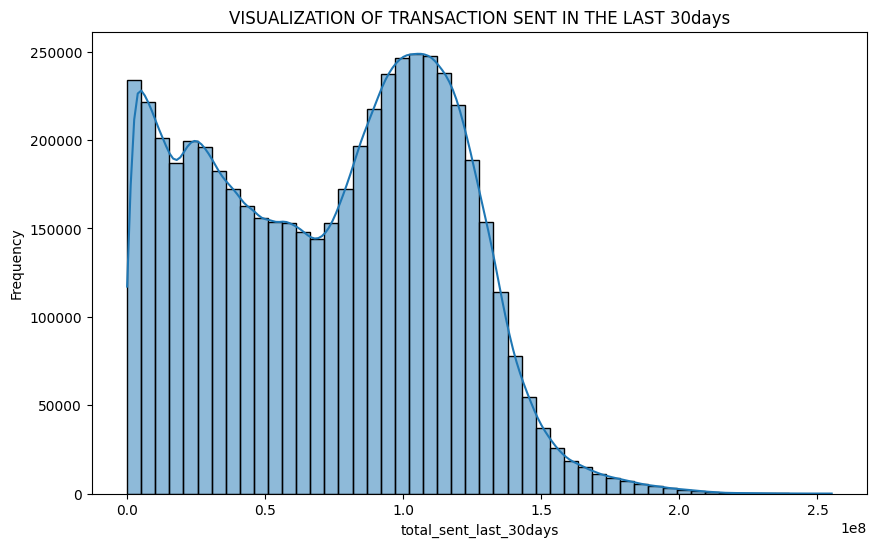

In [ ]:
#VIZUALIZING THE ALL TRANSACTION SENT IN THE LAST 30 days USING HISTOGRAM
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data=fdd, x= 'total_sent_last_30days', kde= True, bins=50)
plt.title('VISUALIZATION OF TRANSACTION SENT IN THE LAST 30days')
plt.xlabel('total_sent_last_30days')
plt.ylabel('Frequency')

plt.show()

From the descriptive summary, skewness and kurtosis analysis, of the transaction amount sent in the last 30 days, it is shown that the dataset is approximately symmetric although it's still spread out below the mean and as analysed, the skewness is 0.028 and from the kurtosis, the amount sent in the last 30 days shows that there seem to be a weak peak tendency with significant outliers and the values seems to be spread below the mean. This analysis complements the descriptive the summary because the std lies below the mean which means that the dataset is spread quite below the mean and as shown in the min being 0.1 and max being 255,147,522.5 where 75% of the dataset lies between 0 and 108835762.3. The visualization also confirms the analysis because from the visuals, the data shows to be approximately symmetric dataset although majority of the data are still clustered around the lower values and distributed to the right confirmed by the descriptive summary, skewness and kurtosis analysis..

This, further confirms that the longer the time window, the higher the transaction amount sent with by unique users within that time period and the better the distribution balance.

In [ ]:
# Descriptive Statistics, kurtosis and skewness of Total Count of transactions in the Last 1hr
describe = fdd['tx_count_last_1hr'].describe().round(2)
print('Descriptive statistics:')
print(describe)

skewness = fdd['tx_count_last_1hr'].skew()
kurtosis = fdd['tx_count_last_1hr'].kurt()

print(f'\nSkewness: {skewness:.3f}')
print(f'Kurtosis: {kurtosis:.3f}')

print('Skewness and Kurtosis Analysis:')
# SKEWNESS INTERPRETATION
print('Skewness Analysis:')
if -0.5 <= skewness <= 0.5:
    print('>> The data is approximately symmetric i.e it is evenly spread around the mean')
elif 0.5 < skewness <= 1:
    print('>> The data is moderately right skewed i.e more values on the left, tail on the right')
elif skewness > 1:
    print('>> The data is highly right skewed i.e most values are low, few extremely high values')
elif -1 <= skewness < -0.5:
    print('>> The data is moderately left skewed i.e more values on the right, tail on the left')
elif skewness < -1:
    print('>> The data is highly left skewed i.e most values are high, few extremely low values')
else:
    print('incorrect code input')

# KURTOSIS INTERPRETATION
print('\nKurtosis Analysis:')
if 2.5 <= kurtosis <= 3.5:
    print('>> The distribution is Mesokurtic i.e it is normally distributed, moderate tails, no extreme outliers')
elif kurtosis > 3.5:
    print('>> The distribution is Leptokurtic i.e there is a sharp peak, heavy tails, likely has extreme outliers')
elif kurtosis < 2.5:
    print('>> The distribution is Platykurtic i.e flat peak, light tails, values are more evenly spread')
else:
    print('Wrong Code Syntax')

Descriptive statistics:
count    5420481.00
mean           1.99
std            0.82
min            1.00
25%            1.00
50%            2.00
75%            3.00
max            5.00
Name: tx_count_last_1hr, dtype: float64

Skewness: 0.027
Kurtosis: -1.486
Skewness and Kurtosis Analysis:
Skewness Analysis:
>> The data is approximately symmetric i.e it is evenly spread around the mean

Kurtosis Analysis:
>> The distribution is Platykurtic i.e flat peak, light tails, values are more evenly spread


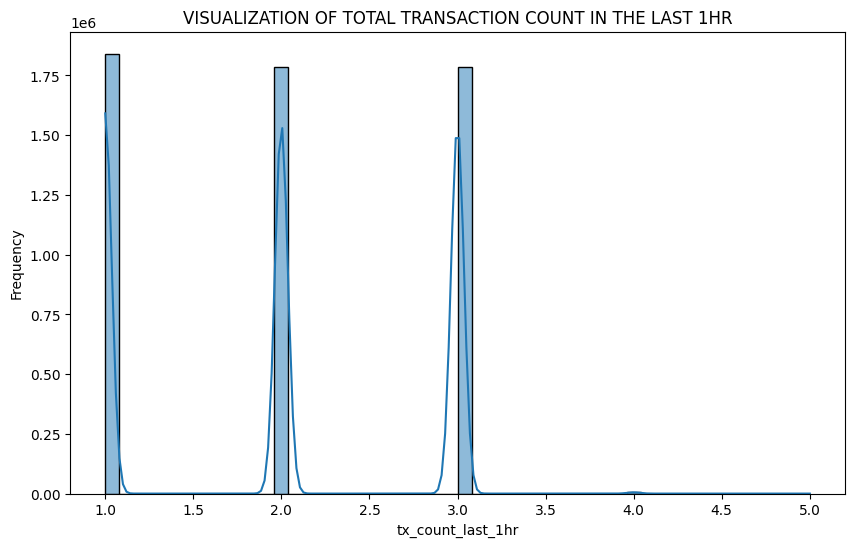

In [ ]:
#VIZUALIZING THE TOTAL TRANSACTION COUNT IN THE LAST 1HR USING HISTOGRAM
plt.figure(figsize=(10, 6))
sns.histplot(data=fdd, x= 'tx_count_last_1hr', kde= True, bins=50)
plt.title('VISUALIZATION OF TOTAL TRANSACTION COUNT IN THE LAST 1HR')
plt.xlabel('tx_count_last_1hr')
plt.ylabel('Frequency')

plt.show()

From the descriptive summary, skewness and kurtosis analysis, of the total transaction count in the last 1hr, the number of counts range from 0-5 where the majority (75%) of the dataset carried out 2-3 transactions in the last 1hr and as shown in the skewness, the transaction count showed to be approximately symmetric and spread out across the mean  also the kurtosis shows to be a platykurtic distribution where there is a flat peak, light tails and values are evenly spread. This is also confirmed using the visuals using histogram where the data is spread out mostly between 0-3 although there are still presence of outliers (4 and 5)

In [ ]:
# Descriptive Statistics, kurtosis and skewness of Total Count of transactions in the Last 1 day
describe = fdd['tx_count_last_1day'].describe().round(2)
print('Descriptive statistics:')
print(describe)

skewness = fdd['tx_count_last_1day'].skew()
kurtosis = fdd['tx_count_last_1day'].kurt()

print(f'\nSkewness: {skewness:.3f}')
print(f'Kurtosis: {kurtosis:.3f}')

print('Skewness and Kurtosis Analysis:')
# SKEWNESS INTERPRETATION
print('Skewness Analysis:')
if -0.5 <= skewness <= 0.5:
    print('>> The data is approximately symmetric i.e it is evenly spread around the mean')
elif 0.5 < skewness <= 1:
    print('>> The data is moderately right skewed i.e more values on the left, tail on the right')
elif skewness > 1:
    print('>> The data is highly right skewed i.e most values are low, few extremely high values')
elif -1 <= skewness < -0.5:
    print('>> The data is moderately left skewed i.e more values on the right, tail on the left')
elif skewness < -1:
    print('>> The data is highly left skewed i.e most values are high, few extremely low values')
else:
    print('incorrect code input')

# KURTOSIS INTERPRETATION
print('\nKurtosis Analysis:')
if 2.5 <= kurtosis <= 3.5:
    print('>> The distribution is Mesokurtic i.e it is normally distributed, moderate tails, no extreme outliers')
elif kurtosis > 3.5:
    print('>> The distribution is Leptokurtic i.e there is a sharp peak, heavy tails, likely has extreme outliers')
elif kurtosis < 2.5:
    print('>> The distribution is Platykurtic i.e flat peak, light tails, values are more evenly spread')
else:
    print('Wrong Code Syntax')

Descriptive statistics:
count    5420481.00
mean          36.82
std           11.04
min            1.00
25%           32.00
50%           38.00
75%           44.00
max           69.00
Name: tx_count_last_1day, dtype: float64

Skewness: -0.767
Kurtosis: 1.442
Skewness and Kurtosis Analysis:
Skewness Analysis:
>> The data is moderately left skewed i.e more values on the right, tail on the left

Kurtosis Analysis:
>> The distribution is Platykurtic i.e flat peak, light tails, values are more evenly spread


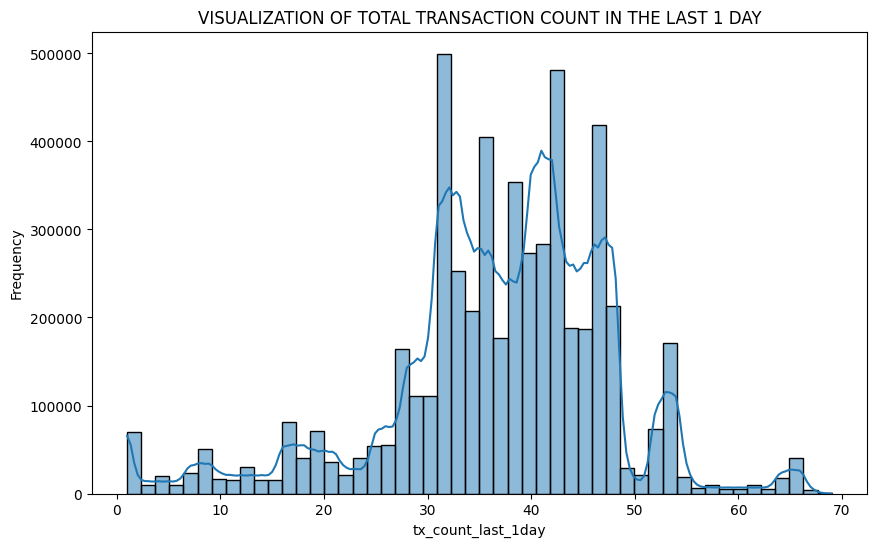

In [ ]:
#VIZUALIZING THE TOTAL TRANSACTION COUNT IN THE LAST 1 DAY USING HISTOGRAM
plt.figure(figsize=(10, 6))
sns.histplot(data=fdd, x= 'tx_count_last_1day', kde= True, bins=50)
plt.title('VISUALIZATION OF TOTAL TRANSACTION COUNT IN THE LAST 1 DAY')
plt.xlabel('tx_count_last_1day')
plt.ylabel('Frequency')

plt.show()

From the descriptive summary, skewness and kurtosis analysis, of the total transaction count in the last 1 day, with the addition of extra time, the count transaction count per user increased and the number of counts range from now range from 1-69 (min and max) where the majority (75%) of the dataset carried out 1-69 transactions in the last 1 day and as shown in the skewness, the transaction count showed to be moderately skewed to the left but is still spread out below the mean  also the kurtosis shows to be a platykurtic distribution where there is a flat peak, light tails and values are evenly spread. This is also confirmed using the visuals, as shown, there is a heavy concetration of the count between 30-50 meanwhile, the mean is 36.

This also means that the longer the time window, the higher the transaction counts of the users and the higher the tendencies of the distribution shifting towards the left.

In [ ]:
# Descriptive Statistics, kurtosis and skewness of Total Count of transactions in the Last 7 DAYS
describe = fdd['tx_count_last_7days'].describe().round(2)
print('Descriptive statistics:')
print(describe)

skewness = fdd['tx_count_last_7days'].skew()
kurtosis = fdd['tx_count_last_7days'].kurt()

print(f'\nSkewness: {skewness:.3f}')
print(f'Kurtosis: {kurtosis:.3f}')

print('Skewness and Kurtosis Analysis:')
# SKEWNESS INTERPRETATION
print('Skewness Analysis:')
if -0.5 <= skewness <= 0.5:
    print('>> The data is approximately symmetric i.e it is evenly spread around the mean')
elif 0.5 < skewness <= 1:
    print('>> The data is moderately right skewed i.e more values on the left, tail on the right')
elif skewness > 1:
    print('>> The data is highly right skewed i.e most values are low, few extremely high values')
elif -1 <= skewness < -0.5:
    print('>> The data is moderately left skewed i.e more values on the right, tail on the left')
elif skewness < -1:
    print('>> The data is highly left skewed i.e most values are high, few extremely low values')
else:
    print('incorrect code input')

# KURTOSIS INTERPRETATION
print('\nKurtosis Analysis:')
if 2.5 <= kurtosis <= 3.5:
    print('>> The distribution is Mesokurtic i.e it is normally distributed, moderate tails, no extreme outliers')
elif kurtosis > 3.5:
    print('>> The distribution is Leptokurtic i.e there is a sharp peak, heavy tails, likely has extreme outliers')
elif kurtosis < 2.5:
    print('>> The distribution is Platykurtic i.e flat peak, light tails, values are more evenly spread')
else:
    print('Wrong Code Syntax')

Descriptive statistics:
count    5420481.00
mean         221.26
std           73.89
min            1.00
25%          209.00
50%          237.00
75%          277.00
max          318.00
Name: tx_count_last_7days, dtype: float64

Skewness: -1.323
Kurtosis: 1.299
Skewness and Kurtosis Analysis:
Skewness Analysis:
>> The data is highly left skewed i.e most values are high, few extremely low values

Kurtosis Analysis:
>> The distribution is Platykurtic i.e flat peak, light tails, values are more evenly spread


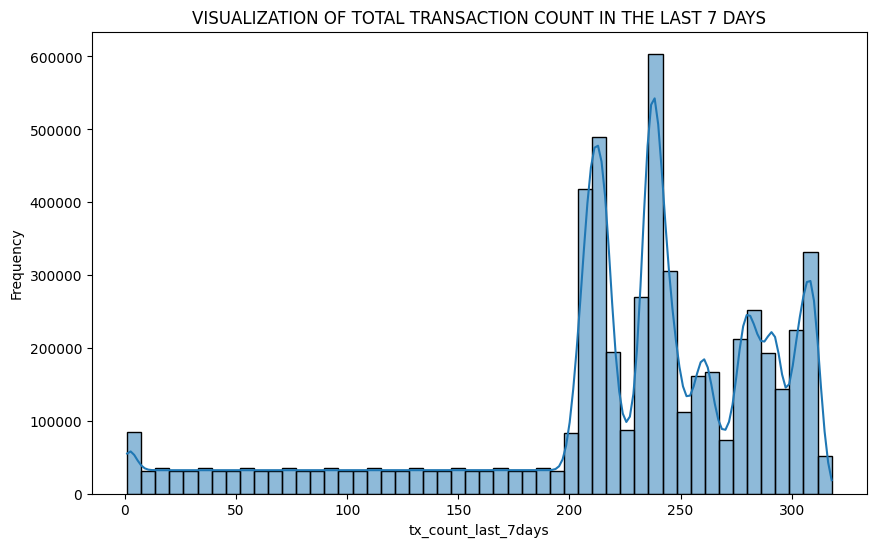

In [ ]:
#VIZUALIZING THE TOTAL TRANSACTION COUNT IN THE LAST 7 DAYS USING HISTOGRAM
plt.figure(figsize=(10, 6))
sns.histplot(data=fdd, x= 'tx_count_last_7days', kde= True, bins=50)
plt.title('VISUALIZATION OF TOTAL TRANSACTION COUNT IN THE LAST 7 DAYS')
plt.xlabel('tx_count_last_7days')
plt.ylabel('Frequency')

plt.show()

From the descriptive summary, skewness and kurtosis analysis, of the total transaction count in the last 7 days, with the addition of extra time, the count transaction count per user increased and the number of counts range from now range from 318 (min and max) where the majority (75%) of the dataset carried out 1-277 transactions in the last 7 days and as shown in the skewness, the transaction count showed to be highly skewed to the left with a skewness of -1.323 but is still spread out below the mean. Also the kurtosis shows to be a platykurtic distribution where there is a flat peak, light tails and values are evenly spread. This is also confirmed using the visuals, as shown, there is a heavy concetration of the count between 200-300 meanwhile, the mean is 221.

This also proves the earlier conclusion that the longer the time window, the higher the transaction counts of the users and the higher the tendencies of the distribution shifting towards the left.

In [ ]:
# Descriptive Statistics, kurtosis and skewness of Total Count of transactions in the Last 30 days
describe = fdd['tx_count_last_30days'].describe().round(2)
print('Descriptive statistics:')
print(describe)

skewness = fdd['tx_count_last_30days'].skew()
kurtosis = fdd['tx_count_last_30days'].kurt()

print(f'\nSkewness: {skewness:.3f}')
print(f'Kurtosis: {kurtosis:.3f}')

print('Skewness and Kurtosis Analysis:')
# SKEWNESS INTERPRETATION
print('Skewness Analysis:')
if -0.5 <= skewness <= 0.5:
    print('>> The data is approximately symmetric i.e it is evenly spread around the mean')
elif 0.5 < skewness <= 1:
    print('>> The data is moderately right skewed i.e more values on the left, tail on the right')
elif skewness > 1:
    print('>> The data is highly right skewed i.e most values are low, few extremely high values')
elif -1 <= skewness < -0.5:
    print('>> The data is moderately left skewed i.e more values on the right, tail on the left')
elif skewness < -1:
    print('>> The data is highly left skewed i.e most values are high, few extremely low values')
else:
    print('incorrect code input')

# KURTOSIS INTERPRETATION
print('\nKurtosis Analysis:')
if 2.5 <= kurtosis <= 3.5:
    print('>> The distribution is Mesokurtic i.e it is normally distributed, moderate tails, no extreme outliers')
elif kurtosis > 3.5:
    print('>> The distribution is Leptokurtic i.e there is a sharp peak, heavy tails, likely has extreme outliers')
elif kurtosis < 2.5:
    print('>> The distribution is Platykurtic i.e flat peak, light tails, values are more evenly spread')
else:
    print('Wrong Code Syntax')

Descriptive statistics:
count    5420481.00
mean         526.33
std          309.09
min            1.00
25%          259.00
50%          526.00
75%          794.00
max         1071.00
Name: tx_count_last_30days, dtype: float64

Skewness: 0.001
Kurtosis: -1.201
Skewness and Kurtosis Analysis:
Skewness Analysis:
>> The data is approximately symmetric i.e it is evenly spread around the mean

Kurtosis Analysis:
>> The distribution is Platykurtic i.e flat peak, light tails, values are more evenly spread


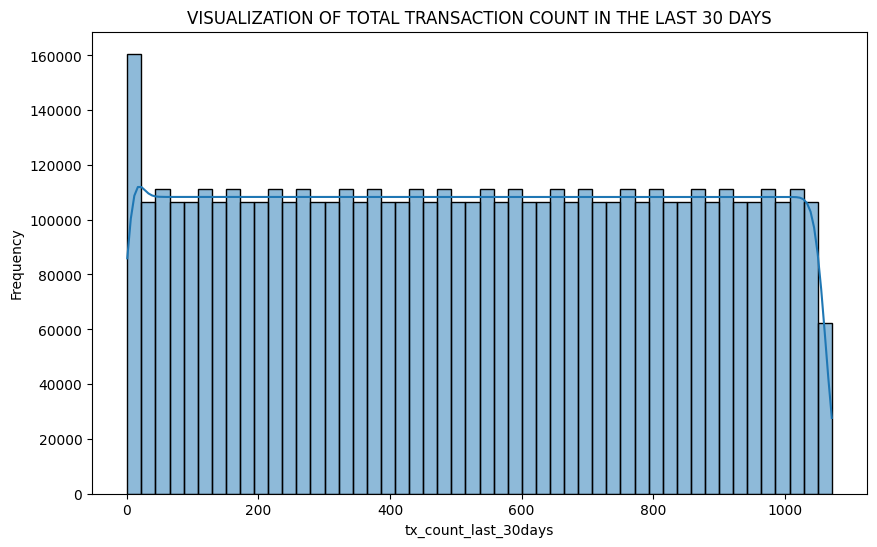

In [ ]:
#VIZUALIZING THE TOTAL TRANSACTION COUNT IN THE LAST 30 DAYS USING HISTOGRAM
plt.figure(figsize=(10, 6))
sns.histplot(data=fdd, x= 'tx_count_last_30days', kde= True, bins=50)
plt.title('VISUALIZATION OF TOTAL TRANSACTION COUNT IN THE LAST 30 DAYS')
plt.xlabel('tx_count_last_30days')
plt.ylabel('Frequency')

plt.show()

From the descriptive summary, skewness and kurtosis analysis, of the total transaction count in the last 30 days, with the addition of extra time, the count transaction count per user increased and the number of counts range from now range from 1-1071 (min and max) where the majority (75%) of the dataset carried out 1-794 transactions in the last 30 days and as shown in the skewness, the transaction count showed to be normally distributed with a skewness of 0.001 but is still spread out below the mean. Also the kurtosis shows to be a platykurtic distribution where there is a flat peak, light tails and values are evenly spread. This is also confirmed using the visuals, as shown, the data is almost evenly spread across all counts

Due to the significant difference between the time frame (7-31 days), there is enough time to carry out series of transactions and therefore the number of times transactions were carried out increased and this is one of the factors that led to the causes of the normal distribution. The distribution shows the activeness of the users and indicates that it is a realistic dataset and could be used in real world scenerios.

In [ ]:
# Descriptive Statistics, kurtosis and skewness of AVERAGE Amount transferred in the Last 1hr
describe = fdd['avg_amount_last_1hr'].describe().round(2)
print('Descriptive statistics:')
print(describe)

skewness = fdd['avg_amount_last_1hr'].skew()
kurtosis = fdd['avg_amount_last_1hr'].kurt()

print(f'\nSkewness: {skewness:.3f}')
print(f'Kurtosis: {kurtosis:.3f}')

print('Skewness and Kurtosis Analysis:')
# SKEWNESS INTERPRETATION
print('Skewness Analysis:')
if -0.5 <= skewness <= 0.5:
    print('>> The data is approximately symmetric i.e it is evenly spread around the mean')
elif 0.5 < skewness <= 1:
    print('>> The data is moderately right skewed i.e more values on the left, tail on the right')
elif skewness > 1:
    print('>> The data is highly right skewed i.e most values are low, few extremely high values')
elif -1 <= skewness < -0.5:
    print('>> The data is moderately left skewed i.e more values on the right, tail on the left')
elif skewness < -1:
    print('>> The data is highly left skewed i.e most values are high, few extremely low values')
else:
    print('incorrect code input')

# KURTOSIS INTERPRETATION
print('\nKurtosis Analysis:')
if 2.5 <= kurtosis <= 3.5:
    print('>> The distribution is Mesokurtic i.e it is normally distributed, moderate tails, no extreme outliers')
elif kurtosis > 3.5:
    print('>> The distribution is Leptokurtic i.e there is a sharp peak, heavy tails, likely has extreme outliers')
elif kurtosis < 2.5:
    print('>> The distribution is Platykurtic i.e flat peak, light tails, values are more evenly spread')
else:
    print('Wrong Code Syntax')

Descriptive statistics:
count     5420481.00
mean       152715.89
std        422610.47
min             0.04
25%         38730.80
50%         92755.88
75%        150049.19
max      24638740.00
Name: avg_amount_last_1hr, dtype: float64

Skewness: 13.660
Kurtosis: 274.543
Skewness and Kurtosis Analysis:
Skewness Analysis:
>> The data is highly right skewed i.e most values are low, few extremely high values

Kurtosis Analysis:
>> The distribution is Leptokurtic i.e there is a sharp peak, heavy tails, likely has extreme outliers


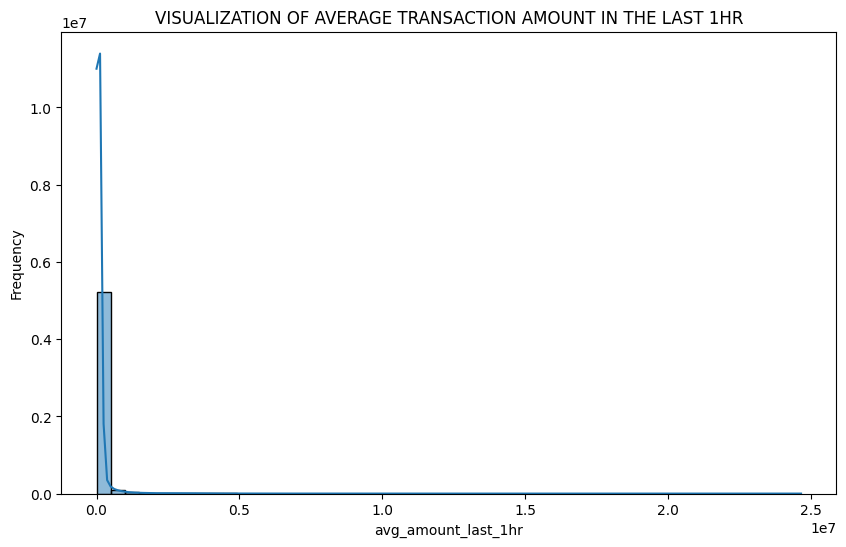

In [ ]:
#VIZUALIZING THE AVERAGE TRANSACTION AMOUNT IN THE LAST 1HR USING HISTOGRAM
plt.figure(figsize=(10, 6))
sns.histplot(data=fdd, x= 'avg_amount_last_1hr', kde= True, bins=50)
plt.title('VISUALIZATION OF AVERAGE TRANSACTION AMOUNT IN THE LAST 1HR')
plt.xlabel('avg_amount_last_1hr')
plt.ylabel('Frequency')

plt.show()

In [ ]:
# Descriptive Statistics, kurtosis and skewness of AVERAGE Amount transferred in the Last 1 DAY
describe = fdd['avg_amount_last_1day'].describe().round(2)
print('Descriptive statistics:')
print(describe)

skewness = fdd['avg_amount_last_1day'].skew()
kurtosis = fdd['avg_amount_last_1day'].kurt()

print(f'\nSkewness: {skewness:.3f}')
print(f'Kurtosis: {kurtosis:.3f}')

print('Skewness and Kurtosis Analysis:')
# SKEWNESS INTERPRETATION
print('Skewness Analysis:')
if -0.5 <= skewness <= 0.5:
    print('>> The data is approximately symmetric i.e it is evenly spread around the mean')
elif 0.5 < skewness <= 1:
    print('>> The data is moderately right skewed i.e more values on the left, tail on the right')
elif skewness > 1:
    print('>> The data is highly right skewed i.e most values are low, few extremely high values')
elif -1 <= skewness < -0.5:
    print('>> The data is moderately left skewed i.e more values on the right, tail on the left')
elif skewness < -1:
    print('>> The data is highly left skewed i.e most values are high, few extremely low values')
else:
    print('incorrect code input')

# KURTOSIS INTERPRETATION
print('\nKurtosis Analysis:')
if 2.5 <= kurtosis <= 3.5:
    print('>> The distribution is Mesokurtic i.e it is normally distributed, moderate tails, no extreme outliers')
elif kurtosis > 3.5:
    print('>> The distribution is Leptokurtic i.e there is a sharp peak, heavy tails, likely has extreme outliers')
elif kurtosis < 2.5:
    print('>> The distribution is Platykurtic i.e flat peak, light tails, values are more evenly spread')
else:
    print('Wrong Code Syntax')

Descriptive statistics:
count     5420481.00
mean       153722.72
std        352140.62
min             0.06
25%         87224.07
50%        116550.38
75%        156264.44
max      24638740.00
Name: avg_amount_last_1day, dtype: float64

Skewness: 19.649
Kurtosis: 510.662
Skewness and Kurtosis Analysis:
Skewness Analysis:
>> The data is highly right skewed i.e most values are low, few extremely high values

Kurtosis Analysis:
>> The distribution is Leptokurtic i.e there is a sharp peak, heavy tails, likely has extreme outliers


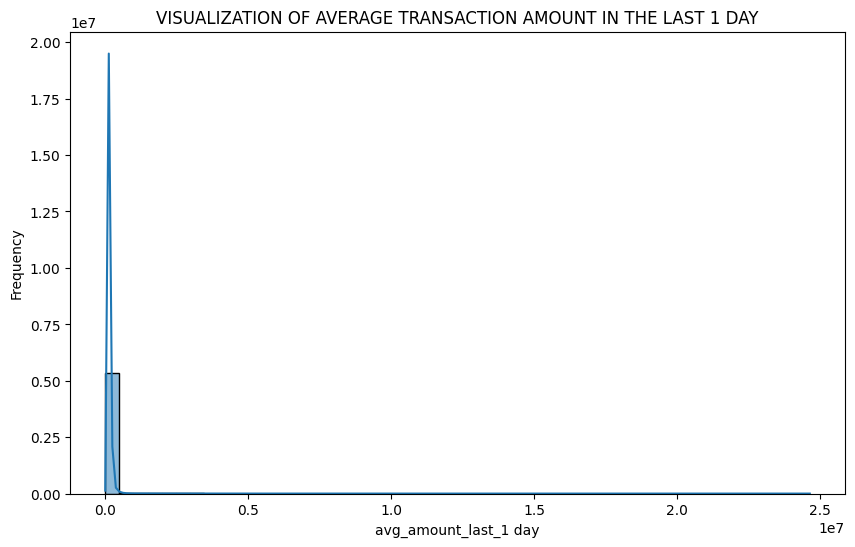

In [ ]:
#VIZUALIZING THE AVERAGE TRANSACTION AMOUNT IN THE LAST 1day USING HISTOGRAM
plt.figure(figsize=(10, 6))
sns.histplot(data=fdd, x= 'avg_amount_last_1day', kde= True, bins=50)
plt.title('VISUALIZATION OF AVERAGE TRANSACTION AMOUNT IN THE LAST 1 DAY')
plt.xlabel('avg_amount_last_1 day')
plt.ylabel('Frequency')

plt.show()

In [ ]:
# Descriptive Statistics, kurtosis and skewness of AVERAGE Amount transferred in the Last 7 DAYS
describe = fdd['avg_amount_last_7days'].describe().round(2)
print('Descriptive statistics:')
print(describe)

skewness = fdd['avg_amount_last_7days'].skew()
kurtosis = fdd['avg_amount_last_7days'].kurt()

print(f'\nSkewness: {skewness:.3f}')
print(f'Kurtosis: {kurtosis:.3f}')

print('Skewness and Kurtosis Analysis:')
# SKEWNESS INTERPRETATION
print('Skewness Analysis:')
if -0.5 <= skewness <= 0.5:
    print('>> The data is approximately symmetric i.e it is evenly spread around the mean')
elif 0.5 < skewness <= 1:
    print('>> The data is moderately right skewed i.e more values on the left, tail on the right')
elif skewness > 1:
    print('>> The data is highly right skewed i.e most values are low, few extremely high values')
elif -1 <= skewness < -0.5:
    print('>> The data is moderately left skewed i.e more values on the right, tail on the left')
elif skewness < -1:
    print('>> The data is highly left skewed i.e most values are high, few extremely low values')
else:
    print('incorrect code input')

# KURTOSIS INTERPRETATION
print('\nKurtosis Analysis:')
if 2.5 <= kurtosis <= 3.5:
    print('>> The distribution is Mesokurtic i.e it is normally distributed, moderate tails, no extreme outliers')
elif kurtosis > 3.5:
    print('>> The distribution is Leptokurtic i.e there is a sharp peak, heavy tails, likely has extreme outliers')
elif kurtosis < 2.5:
    print('>> The distribution is Platykurtic i.e flat peak, light tails, values are more evenly spread')
else:
    print('Wrong Code Syntax')

Descriptive statistics:
count     5420481.00
mean       156328.08
std        349791.72
min             0.06
25%        104242.16
50%        129794.95
75%        154801.55
max      24638740.00
Name: avg_amount_last_7days, dtype: float64

Skewness: 19.993
Kurtosis: 521.752
Skewness and Kurtosis Analysis:
Skewness Analysis:
>> The data is highly right skewed i.e most values are low, few extremely high values

Kurtosis Analysis:
>> The distribution is Leptokurtic i.e there is a sharp peak, heavy tails, likely has extreme outliers


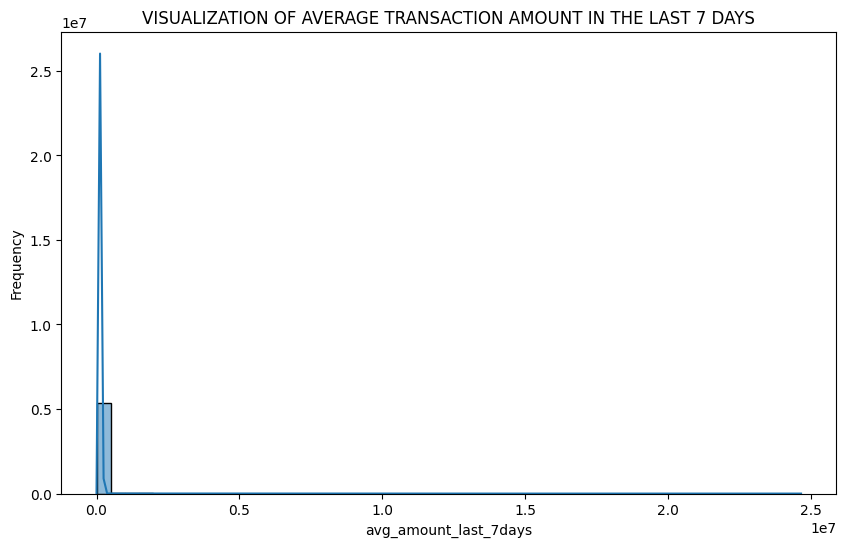

In [ ]:
#VIZUALIZING THE AVERAGE TRANSACTION AMOUNT IN THE LAST 7 DAYS USING HISTOGRAM
plt.figure(figsize=(10, 6))
sns.histplot(data=fdd, x= 'avg_amount_last_7days', kde= True, bins=50)
plt.title('VISUALIZATION OF AVERAGE TRANSACTION AMOUNT IN THE LAST 7 DAYS')
plt.xlabel('avg_amount_last_7days')
plt.ylabel('Frequency')

plt.show()

In [ ]:
# Descriptive Statistics, kurtosis and skewness of AVERAGE Amount transferred in the Last 30 DAYS
describe = fdd['avg_amount_last_30days'].describe().round(2)
print('Descriptive statistics:')
print(describe)

skewness = fdd['avg_amount_last_30days'].skew()
kurtosis = fdd['avg_amount_last_30days'].kurt()

print(f'\nSkewness: {skewness:.3f}')
print(f'Kurtosis: {kurtosis:.3f}')

print('Skewness and Kurtosis Analysis:')
# SKEWNESS INTERPRETATION
print('Skewness Analysis:')
if -0.5 <= skewness <= 0.5:
    print('>> The data is approximately symmetric i.e it is evenly spread around the mean')
elif 0.5 < skewness <= 1:
    print('>> The data is moderately right skewed i.e more values on the left, tail on the right')
elif skewness > 1:
    print('>> The data is highly right skewed i.e most values are low, few extremely high values')
elif -1 <= skewness < -0.5:
    print('>> The data is moderately left skewed i.e more values on the right, tail on the left')
elif skewness < -1:
    print('>> The data is highly left skewed i.e most values are high, few extremely low values')
else:
    print('incorrect code input')

# KURTOSIS INTERPRETATION
print('\nKurtosis Analysis:')
if 2.5 <= kurtosis <= 3.5:
    print('>> The distribution is Mesokurtic i.e it is normally distributed, moderate tails, no extreme outliers')
elif kurtosis > 3.5:
    print('>> The distribution is Leptokurtic i.e there is a sharp peak, heavy tails, likely has extreme outliers')
elif kurtosis < 2.5:
    print('>> The distribution is Platykurtic i.e flat peak, light tails, values are more evenly spread')
else:
    print('Wrong Code Syntax')

Descriptive statistics:
count     5420481.00
mean       162893.98
std        316953.06
min             0.06
25%        124314.98
50%        137498.59
75%        152546.48
max      24638740.00
Name: avg_amount_last_30days, dtype: float64

Skewness: 18.891
Kurtosis: 481.611
Skewness and Kurtosis Analysis:
Skewness Analysis:
>> The data is highly right skewed i.e most values are low, few extremely high values

Kurtosis Analysis:
>> The distribution is Leptokurtic i.e there is a sharp peak, heavy tails, likely has extreme outliers


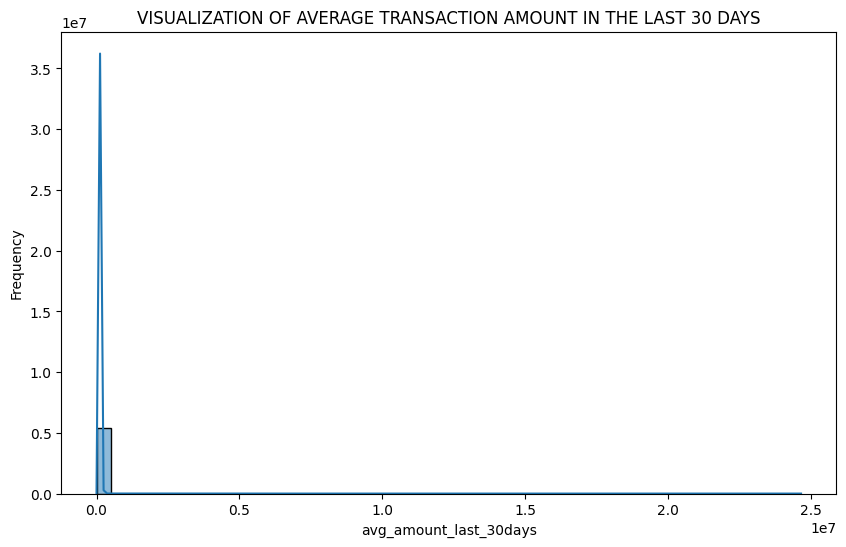

In [ ]:
#VIZUALIZING THE AVERAGE TRANSACTION AMOUNT IN THE LAST 30 DAYS USING HISTOGRAM
plt.figure(figsize=(10, 6))
sns.histplot(data=fdd, x= 'avg_amount_last_30days', kde= True, bins=50)
plt.title('VISUALIZATION OF AVERAGE TRANSACTION AMOUNT IN THE LAST 30 DAYS')
plt.xlabel('avg_amount_last_30days')
plt.ylabel('Frequency')

plt.show()

#### **REPORT EVALUATION - NUMERICAL COLUMN ANALYSIS**

The numerical analysis covered all continuous features using descriptive statistics, skewness and kurtosis analysis alongside histogram and boxplot visualizations. The transaction_amount column has a mean of 152,206.53 with a standard deviation of 455,361.06, indicating extreme variability. With a skewness of 12.622 and kurtosis of 230.642, transaction_amount is one of the most severely right-skewed and leptokurtic features in the entire dataset showing that the vast majority of transactions are small while a small number of extremely large transactions create a very heavy right tail with extreme outliers.

The sender balance columns (sender_balance_before and sender_balance_after) both show heavy right skew at 1.121 and 0.945 respectively, with kurtosis values of 14.579 and 13.804 and are both highly leptokurtic, indicating sharp peaks with heavy tails and extreme outliers. Their means are close (2,836,157 before vs 2,803,814 after) suggesting that on average individual transactions do not drastically alter balances at the population level. The receiver balance columns (before: skew=3.661, kurt=35.139; after: skew=3.859, kurt=33.598) are even more severely skewed, reflecting the diverse range of account sizes receiving funds.

The total_sent columns show a clear progression in skewness as the time window narrows. total_sent_last_1hr is extremely right skewed (skew=9.279, kurt=136.195), total_sent_last_1day is moderately skewed (skew=1.984, kurt=9.183), total_sent_last_7days is only moderately right skewed (skew=0.518, kurt=0.175) and total_sent_last_30days is approximately symmetric (skew=0.028, kurt=-0.971 — platykurtic). This progression reflects the natural smoothing effect of longer time windows which average out extreme individual transactions.

The transaction count columns show contrasting distribution shapes. tx_count_last_1hr is approximately symmetric (skew=0.027) and platykurtic (kurt=-1.486) since it ranges only from 1 to 5. tx_count_last_1day is moderately left skewed (skew=-0.767) with a platykurtic distribution (kurt=1.442). tx_count_last_7days is highly left skewed (skew=-1.323, kurt=1.299) and tx_count_last_30days is approximately symmetric (skew=0.001) and platykurtic (kurt=-1.201), showing that 30-day counts are evenly spread across the full range of 1 to 1,071.

The average amount columns (avg_amount_last_1hr through avg_amount_last_30days) are among the most severely skewed features in the dataset. avg_amount_last_1hr has a skewness of 13.660 and kurtosis of 274.543, avg_amount_last_1day reaches 19.649 skewness and 510.662 kurtosis, avg_amount_last_7days peaks at 19.993 skewness and 521.752 kurtosis, and avg_amount_last_30days sits at 18.891 skewness and 481.611 kurtosis. These extreme values confirm that while most users have modest average transaction amounts, a small group of accounts most likely fraudulent are sending amounts orders of magnitude larger than the typical user.

### **REPORT EVALUATION (STAGE 2- DATA DISTRIBUTION)**

The Stage 2 data distribution analysis revealed a dataset characterized by extreme skewness, heavy tails and significant class imbalance. Categorically, the dataset is dominated by CASH_IN and PAYMENT transaction types, while TRANSFER and CASH_OUT despite being less frequent emerge as the highest-risk channels. The fraud label imbalance (1.12% fraud vs 98.88% non-fraud) is severe and would be corrected before modelling. Numerically, virtually all continuous features are right-skewed and leptokurtic, with the transaction amount and average amount columns being the most extreme. The progression from heavily skewed short-window features (1hr) to more symmetric long-window features (30days) reflects the natural aggregation effect over time. The only features showing approximate symmetry are tx_count_last_30days (skew=0.001) and total_sent_last_30days (skew=0.028), confirming that longer time windows produce more stable and normally distributed features. Across both categorical and numerical dimensions, the data consistently points to transaction amount and its rolling averages as the primary discriminators between fraud and non-fraud behaviour.

## **STAGE 3- BIVARIATE AND MULTIVARIATE EXPLORATORY ANALYSIS**

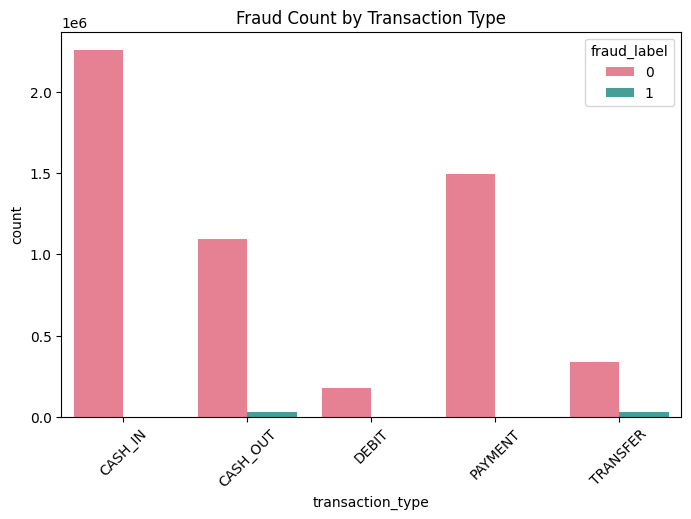

In [ ]:
#which transaction types are most linked to fraud?
plt.figure(figsize=(8,5))
sns.countplot(x='transaction_type', hue='fraud_label', data=fdd, palette='husl')
plt.title("Fraud Count by Transaction Type")
plt.xticks(rotation=45)
plt.show()

The visuals above highlights the fraud signature across different transaction types.

The analysis shows channel-specific risk: fraud is almost entirely concentrated in TRANSFER and CASH_OUT transactions, while high-volume types like CASH_IN are safe. This points to a Drain-and-Exit workflow, where funds are moved via Transfer and withdrawn via Cash Out.

In [ ]:
# column showing if sender_balance_before < transaction_amount
df = fdd.copy()
df['insufficient_balance'] = df['sender_balance_before'] < df['transaction_amount']

# Check how often this happens in frauds vs non-frauds
pd.crosstab(df['insufficient_balance'], df['fraud_label'], normalize='index') * 100

fraud_label,0,1
insufficient_balance,,
False,98.868719,1.131281
True,100.000000,0.000000


A copy of the dataset was created and in this copy, the new column 'insufficient balance' was created. This code calculates a conditional probability matrix by creating an insufficient_balance feature, flagging transactions where the sender’s balance is less than the transaction amount. It then compares fraud rates between sufficient and insufficient balance scenarios.

The analysis reveals a counter-intuitive signal: all insufficient-balance transactions were legitimate, while fraud only occurs in accounts with enough funds. This suggests fraudsters are targeted and informed, avoiding failed transactions.

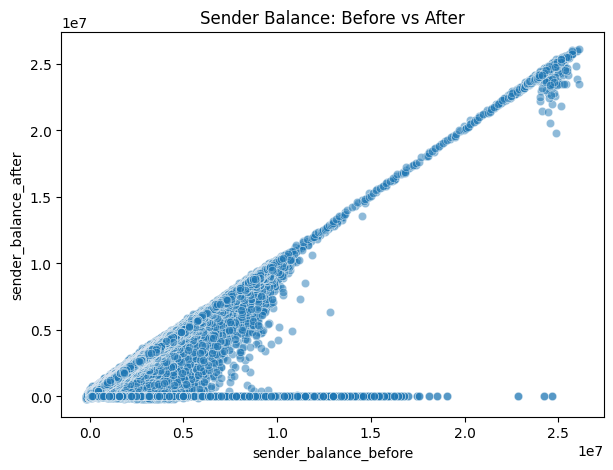

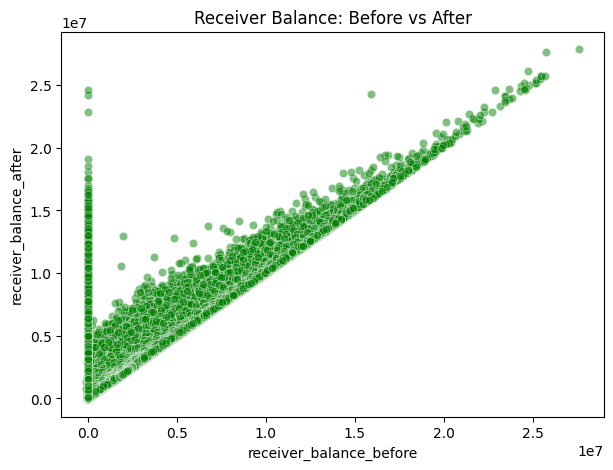

In [ ]:
# how sender and rceiver balances change before and after each transaction.

# Sender balance before vs after
plt.figure(figsize=(7,5))
sns.scatterplot(x='sender_balance_before', y='sender_balance_after', data=fdd, alpha=0.5)
plt.title("Sender Balance: Before vs After")
plt.show()

# Receiver balance before vs after
plt.figure(figsize=(7,5))
sns.scatterplot(x='receiver_balance_before', y='receiver_balance_after', data=fdd, alpha=0.5, color='green')
plt.title("Receiver Balance: Before vs After")
plt.show()

This code visualizes financial flows by creating scatterplots of sender and receiver balances before and after transactions, showing how money physically moves through accounts. It highlights whether accounts are partially used, fully drained, or suddenly flooded.

The analysis identifies two critical fraud patterns:

Total Drain: sender balances drop to exactly zero, forming a dense horizontal cluster at  y=0 . This is a classic account takeover signature, where fraudsters completely empty accounts.

Sudden Liquidity: receiver balances jump from zero to millions, forming a vertical spike at  x=0 . These “cold start” accounts have no prior history but suddenly receive large funds, indicating potential money mule or laundering activity.

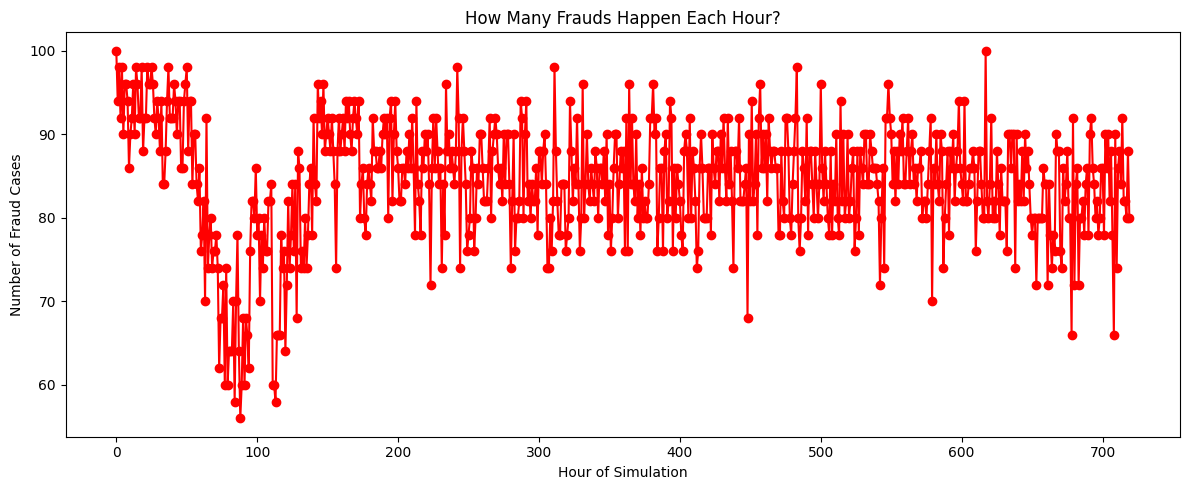

In [ ]:
# VISUALIZATION OF FRAUD FREQUENCY BY HOURS OF SIMULATION
fraud_per_hour = fdd.groupby('hour_of_simulation')['fraud_label'].sum()

plt.figure(figsize=(12, 5))
fraud_per_hour.plot(kind='line', color='red', marker='o')
plt.title('How Many Frauds Happen Each Hour?')
plt.xlabel('Hour of Simulation')
plt.ylabel('Number of Fraud Cases')
plt.tight_layout()
plt.show()

The duagram above visualizes transaction volumes over time and show when fraud occurs. It reveals the “heartbeat” of the dataset, highlighting peaks, lulls, and the presence of fraudulent transactions.

The analysis shows a high-volume front-load, with most activity in the first 30 hours, but an activity gap between Hours 60–100, likely due to simulation pauses or user inactivity. While legitimate transactions fluctuate in large waves, fraudulent activity is persistent and steady, suggesting it’s automated or systematic rather than tied to normal user events.

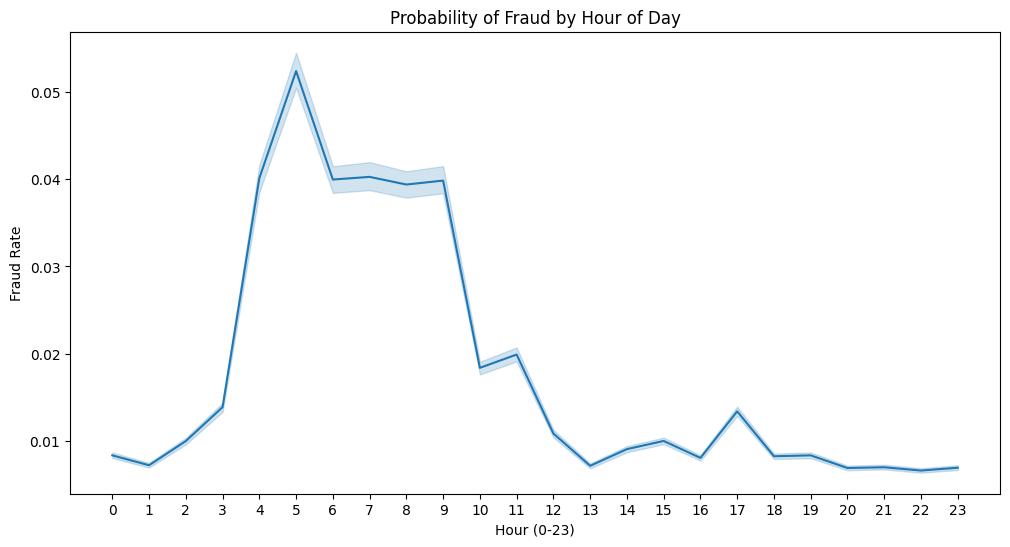

In [ ]:
# Convert hour of simulation to hour of day (assuming 1 step = 1 hour)
# df is another copy created inputing new columns 'insufficient balance' and now 'hour_of_day'
df['hour_of_day'] = df['hour_of_simulation'] % 24

# Plot Fraud Frequency by Hour
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='hour_of_day', y='fraud_label', estimator='mean')
plt.title('Probability of Fraud by Hour of Day')
plt.ylabel('Fraud Rate')
plt.xlabel('Hour (0-23)')
plt.xticks(range(0, 24))
plt.show()

This reveals if fraudsters prefer the "Dark Hours."when transaction time is mapped to a 24-hour cycle, fraud probability is not evenly distributed throughout the day. It peaks between 4:00 AM and 9:00 AM, suggesting that fraudsters may exploit periods of reduced monitoring and slower victim response. The wider confidence interval during these hours also indicates greater variability in fraudulent activity.

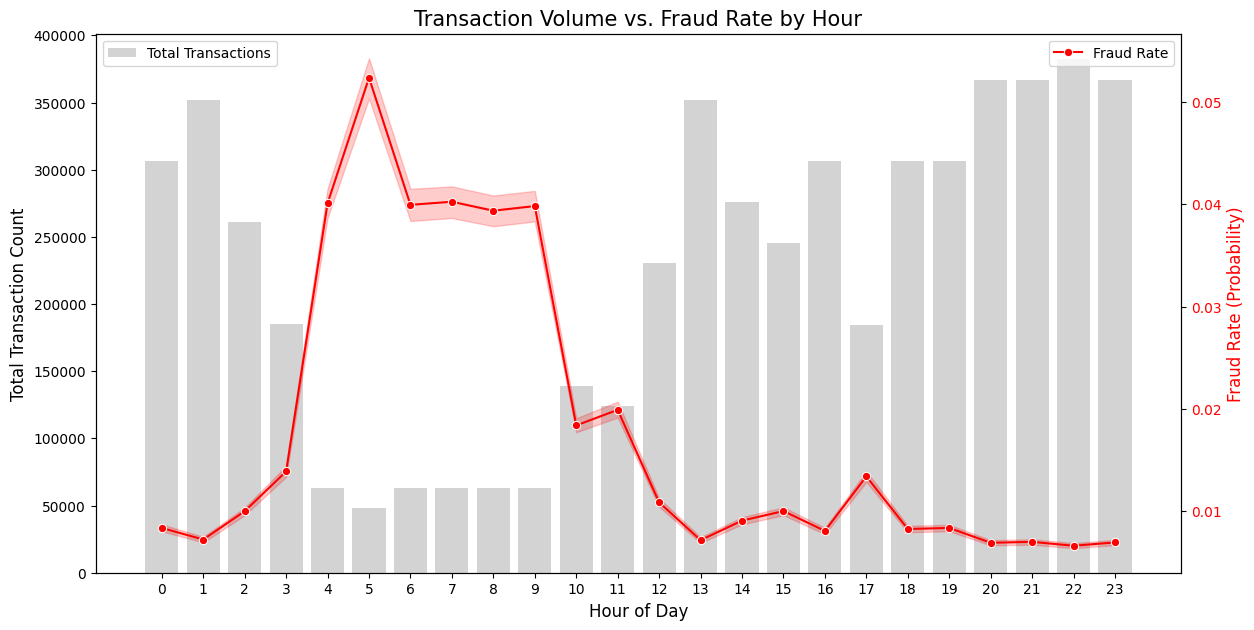

In [ ]:
# Transaction volume vs fraud per hour
# Create a figure with two y-axes
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot 1: Total Transaction Volume (Bar Chart)
sns.countplot(data=df, x='hour_of_day', ax=ax1, color='lightgray', label='Total Transactions')
ax1.set_ylabel('Total Transaction Count', fontsize=12)
ax1.set_xlabel('Hour of Day', fontsize=12)

# Create a second y-axis for the Fraud Rate
ax2 = ax1.twinx()

# Plot 2: Fraud Rate (Line Chart - same as before)
sns.lineplot(data=df, x='hour_of_day', y='fraud_label', ax=ax2, color='red', marker='o', label='Fraud Rate')
ax2.set_ylabel('Fraud Rate (Probability)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Transaction Volume vs. Fraud Rate by Hour', fontsize=15)
plt.show()

This chart reveals a classic, yet stark, inverse relationship between transaction volume and the probability of fraud.

Dead-of-Night Vulnerability (4 AM – 9 AM) it was observed that fraud peaks during early morning hours when transaction volume is lowest, especially around 5 AM, suggesting fraudsters exploit low activity periods.

High Volume, Low Risk (8 PM – 11 PM) which means that although transaction volume is highest in the late evening, the fraud rate remains very low, indicating that legitimate transactions dominate.

Mid-Day Pattern (10 AM – 5 PM) it indicates a small spike in fraud around 10–11 AM, after which the fraud rate stays relatively stable throughout the afternoon.

Fraud Count Per Week:
week_group
Week 1 (Day 1-7)      13912
Week 2 (Day 8-14)     14344
Week 3 (Day 15-21)    14274
Week 4 (Day 22-30)    18036
Name: count, dtype: int64

Fraud Percentage Per Week:
week_group
Week 1 (Day 1-7)      22.97
Week 2 (Day 8-14)     23.68
Week 3 (Day 15-21)    23.57
Week 4 (Day 22-30)    29.78
Name: count, dtype: float64


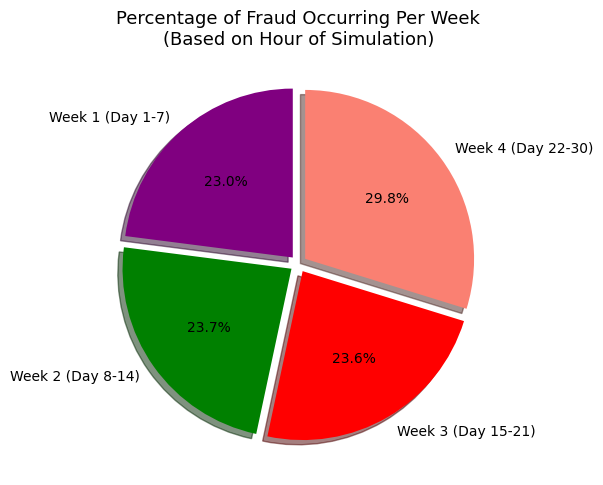

In [ ]:
# VISUALIZING PERCENTAGE OF FRAUD OCCURRING PER WEEK USINE PIE CHART

# week groups from hour_of_simulation (720 hours = 30 days = 4 weeks)
df['week_group'] = pd.cut(
    df['hour_of_simulation'],
    bins=[0, 168, 336, 504, 720],
    labels=['Week 1 (Day 1-7)', 'Week 2 (Day 8-14)',
            'Week 3 (Day 15-21)', 'Week 4 (Day 22-30)']
)

# fraud cases count per week
fraud_per_week = df[df['fraud_label'] == 1]['week_group'].value_counts().sort_index()

print('Fraud Count Per Week:')
print(fraud_per_week)

print('\nFraud Percentage Per Week:')
print((fraud_per_week / fraud_per_week.sum() * 100).round(2))

# pie chart
plt.figure(figsize=(6, 6))
fraud_per_week.plot(
    kind='pie',
    autopct='%1.1f%%',                                      # show percentage on each slice
    colors=['purple', 'green', 'red', 'salmon'],
    explode=[0.05, 0.05, 0.05, 0.05],                      # slightly separate each slice
    shadow=True,                                            # adds shadow for visual depth
    startangle=90                                           # start from top
)
plt.title('Percentage of Fraud Occurring Per Week\n(Based on Hour of Simulation)', fontsize=13)
plt.ylabel('')
plt.tight_layout()
plt.show()

The fraud distribution across the 30-day simulation period is relatively consistent across the first three weeks but shows a notable spike in Week 4, suggesting fraud activity escalates towards the end of the month.

Week by Week Breakdown:

Week 1 (Day 1–7) — 22.97% is the lowest fraud period with 13,912 cases, suggesting fraudsters are less active at the start of the simulation period, possibly because accounts and behaviors are still being established.

Week 2 (Day 8–14) — 23.68% shows a marginal increase of 432 cases from Week 1, essentially stable, confirming that fraud activity in the early-to-mid period remains consistent with no significant behavioral shift.

Week 3 (Day 15–21) — 23.57% is virtually identical to Week 2 with only a 70 case difference, reinforcing that the mid-period fraud rate is stable and predictable around the 23–24% range.

Week 4 (Day 22–30) — 29.78% is the most critical finding — fraud jumps by over 6 percentage points and 3,762 additional cases compared to Week 3, representing the highest fraud concentration in the entire simulation period.

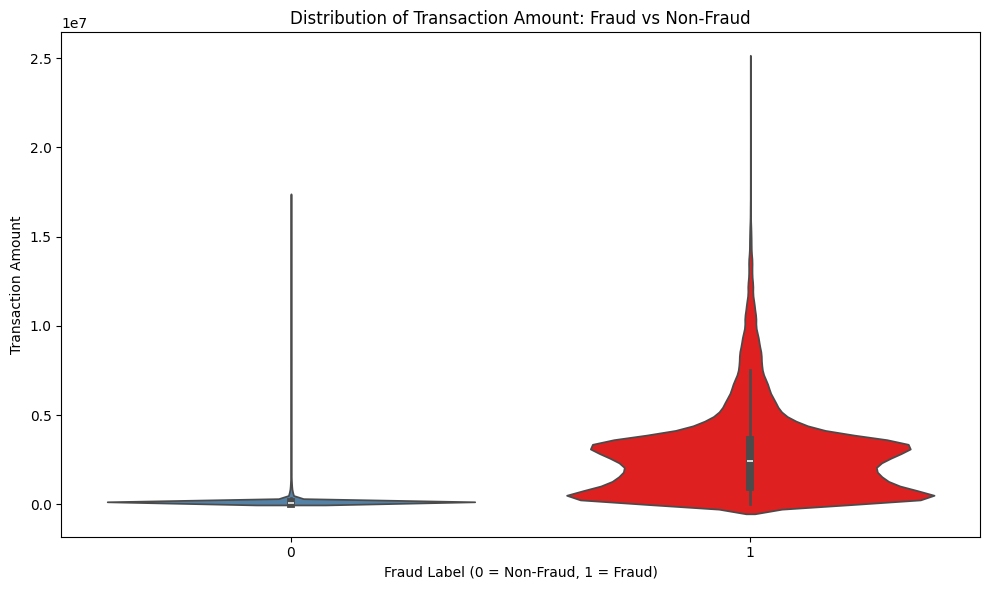

In [ ]:
# VISUALIZATION OF TRANSACTION AMOUNT BY FRAUD LABEL
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=fdd,
    x='fraud_label',            # group by fraud or not
    y='transaction_amount',     # show distribution of amounts
    palette=['steelblue', 'red']
)
plt.title('Distribution of Transaction Amount: Fraud vs Non-Fraud')
plt.xlabel('Fraud Label (0 = Non-Fraud, 1 = Fraud)')
plt.ylabel('Transaction Amount')
plt.tight_layout()
plt.show()

From the visual above, for the non-fraud label, the distribution is extremely narrow and flat, with virtually all transactions concentrated near zero and a single thin whisker extending to around 17 million. This tells us legitimate transactions are overwhelmingly small and consistent in amount with very rare exceptions. On the other hand, for the fraud label shows that the distribution is dramatically wider and taller, with a broad body spanning from near zero up to about 7.5 million and a whisker extending all the way to 25 million. The wide belly of the violin shows fraud transactions are spread across a much larger range of amounts, and the sharp peak indicates a concentration around the 2–3 million mark.

Rows with negative Origin Balance: 5325
Fraud rate in negative balance rows: 0.0000%


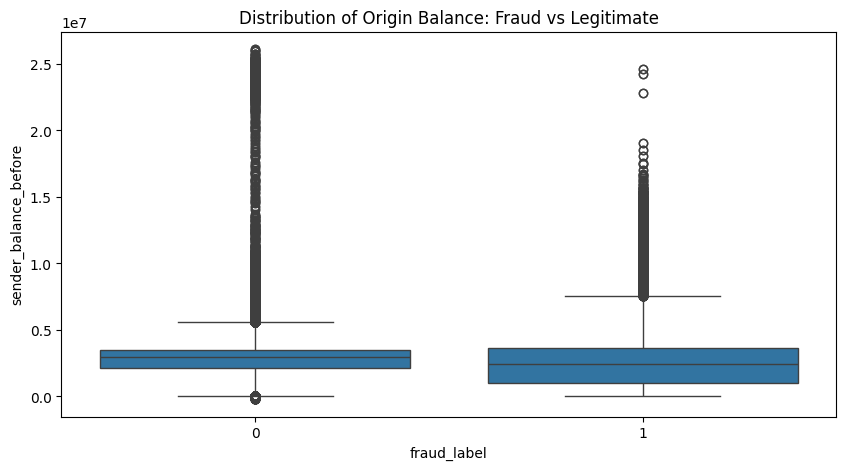

In [ ]:
# Check how many rows have negative balances
neg_orig = fdd[fdd['sender_balance_before'] < 0]
neg_dest = fdd[fdd['receiver_balance_after'] < 0]

print(f"Rows with negative Origin Balance: {len(neg_orig)}")
print(f"Fraud rate in negative balance rows: {neg_orig['fraud_label'].mean():.4%}")

# Visualization to see if negatives are a 'Fraud Signature'
plt.figure(figsize=(10, 5))
sns.boxplot(data=fdd, x='fraud_label', y='sender_balance_before')
plt.title('Distribution of Origin Balance: Fraud vs Legitimate')
plt.show()

This checks if the negative values we saw in the describe() output are actually linked to fraud or just data errors. It was observed that although 5,325 transactions contain negative origin balances, none of them are associated with fraudulent activity (0.00% fraud rate). This suggests that negative balances represent legitimate credit behavior or data irregularities rather than fraud indicators. Therefore, negative origin balance does not provide predictive value for fraud detection in this model and may be treated as noise or standard outliers.

In [ ]:
# Cross-tabulation of Overdraft vs Fraud
overdraft_analysis = pd.crosstab(fdd['unauthorized_overdraft_flag'], fdd['fraud_label'], normalize='index')
print("Overdraft vs Fraud Probability:")
print(overdraft_analysis)

Overdraft vs Fraud Probability:
fraud_label                         0         1
unauthorized_overdraft_flag                    
0                            0.988768  0.011232
1                            1.000000  0.000000


the Unauthorized Overdraft flag shows a 0.00% correlation with fraud, since all cases marked as unauthorized overdrafts were labeled as legitimate transactions in the dataset. This result is somewhat counter-intuitive, as unauthorized overdrafts would normally be expected to signal a higher risk of fraudulent activity. However, in this dataset, the evidence suggests that the system’s overdraft alerts are primarily capturing operational issues such as banking errors, temporary credit-limit breaches, or internal processing anomalies rather than actual fraudulent behavior.

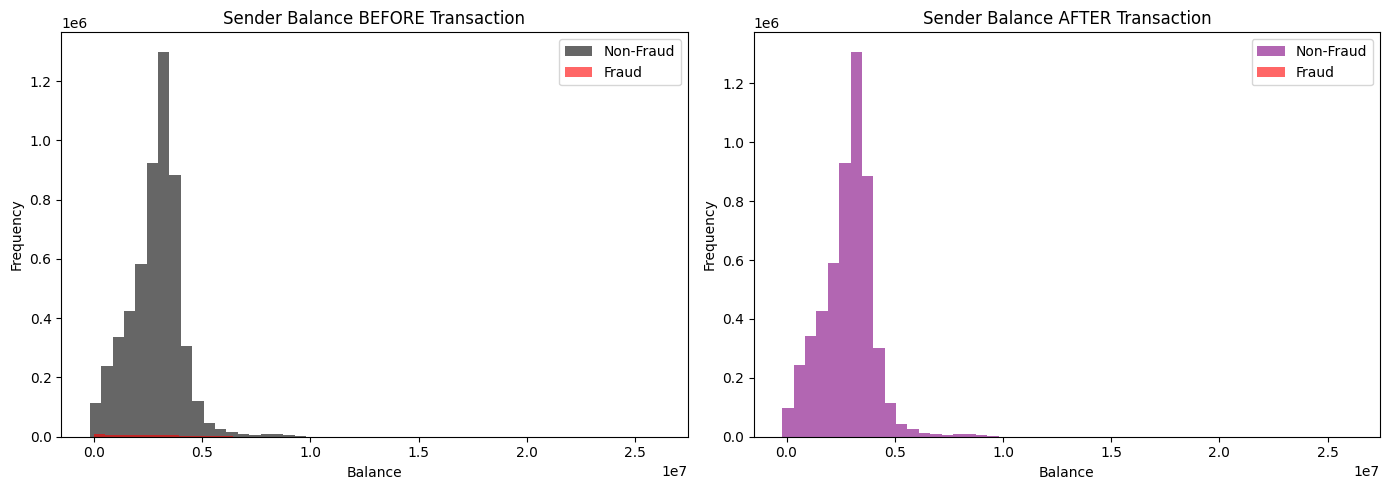

In [ ]:
# VIZUALIZATION OF SENDER'S BALANCE BEFORE AND AFTER VS FRAUD LABEL
# determine if fraud transactions balance drops more compared to non fraud
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Split data into fraud and non-fraud first
non_fraud = fdd[fdd['fraud_label'] == 0]
fraud     = fdd[fdd['fraud_label'] == 1]

# Balance BEFORE transaction
non_fraud['sender_balance_before'].plot(kind='hist', bins=50, alpha=0.6, ax=axes[0], color='black', label='Non-Fraud')
fraud['sender_balance_before'].plot(kind='hist', bins=50, alpha=0.6, ax=axes[0], color='red', label='Fraud')
axes[0].set_title('Sender Balance BEFORE Transaction')
axes[0].set_xlabel('Balance')
axes[0].legend()

# Balance AFTER transaction
non_fraud['sender_balance_after'].plot(kind='hist', bins=50, alpha=0.6, ax=axes[1], color='purple', label='Non-Fraud')
fraud['sender_balance_after'].plot(kind='hist', bins=50, alpha=0.6, ax=axes[1], color='red', label='Fraud')
axes[1].set_title('Sender Balance AFTER Transaction')
axes[1].set_xlabel('Balance')
axes[1].legend()

plt.tight_layout()
plt.show()

From both charts, the visuals are nearly identical, with non-fraud balances concentrated between 0 and 5 million peaking around 3–4 million and a long tail extending to 27 million. The fraud line is barely visible in both plots, sitting flat near zero across all balance levels with no meaningful concentration at any point. The near-identical before and after distributions confirm that sender balance changes very little after a transaction

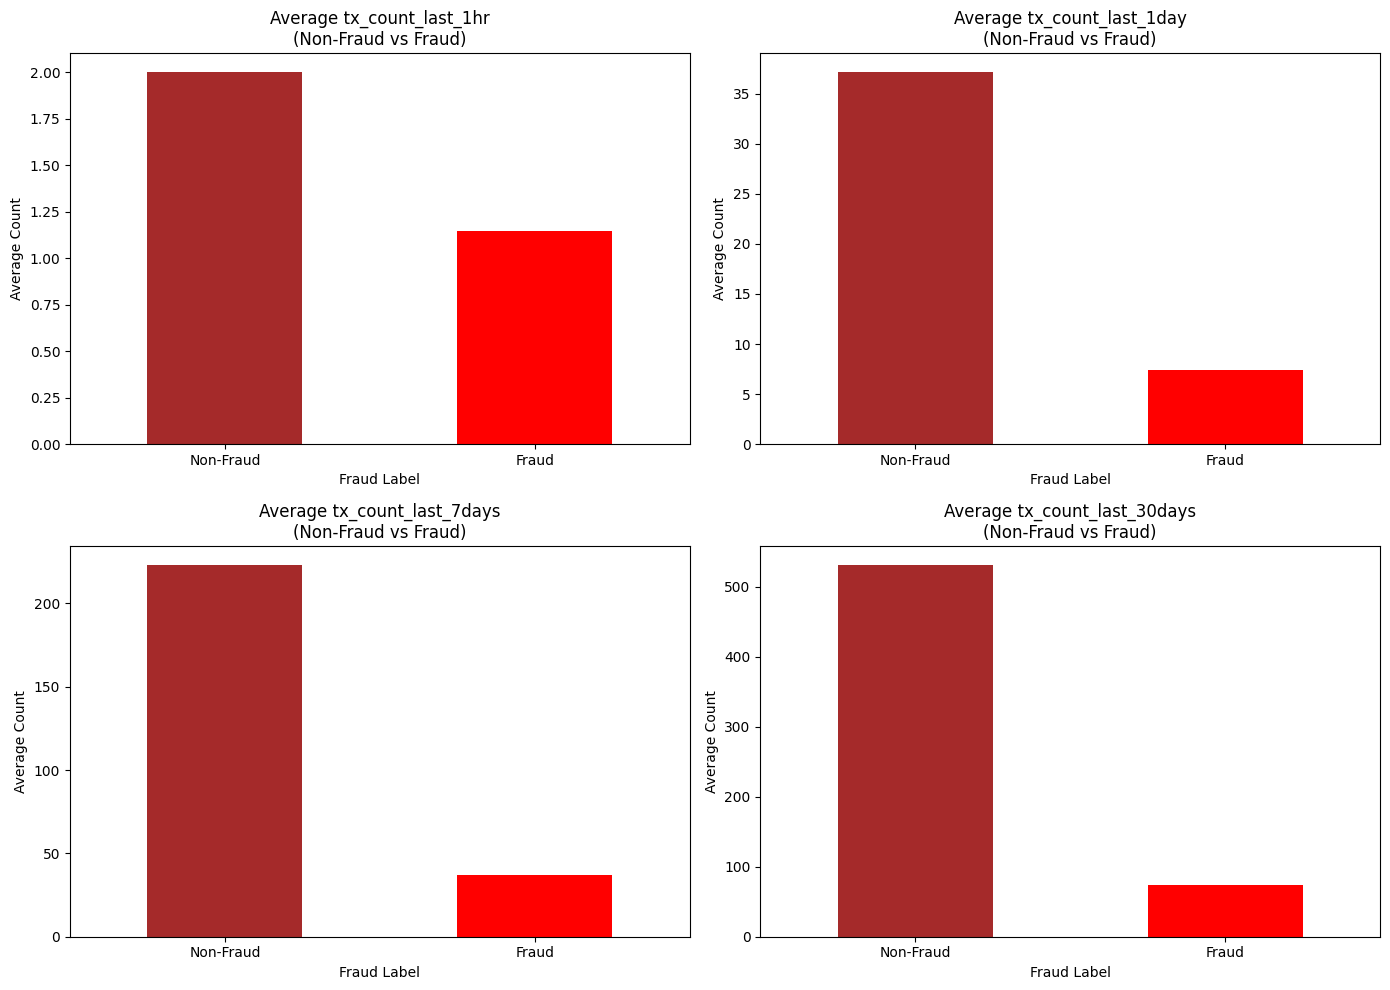

In [ ]:
# VISUALIZATION OF TRANSACTION COUNTS TREND
tx_cols = ['tx_count_last_1hr', 'tx_count_last_1day',
           'tx_count_last_7days', 'tx_count_last_30days']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), tx_cols):
    # Calculate average count for fraud vs non-fraud
    fdd.groupby('fraud_label')[col].mean().plot(kind='bar', ax=ax, color=['brown', 'red'])
    ax.set_title(f'Average {col}\n(Non-Fraud vs Fraud)')
    ax.set_xlabel('Fraud Label')
    ax.set_ylabel('Average Count')
    ax.set_xticklabels(['Non-Fraud', 'Fraud'], rotation=0)

plt.tight_layout()
plt.show()

Across all four time windows, non-fraud transactions consistently and significantly outnumber fraud transactions, with the gap growing larger as the time window extends. The 1hr window shows that non-fraud averages 2 transactions versus fraud at roughly 1.2 and this shows the smallest gap across all windows, meaning short-term velocity alone is not a strong differentiator between the two groups.

The 1-day window furhter shows that the gap widens noticeably with non-fraud at approximately 37 versus fraud at 7, suggesting legitimate users are far more active on a daily basis than fraudsters.

The 7-day window showed non-fraud reaches around 225 versus fraud at approximately 38 the proportional gap is now dramatic, with legitimate users transacting nearly 6 times more than fraudulent ones over a week.
Lastly, the 30-day window which is the largest gap of all shows that non-fraud peaks at roughly 530 versus fraud at around 75, confirming that over a longer horizon legitimate accounts accumulate far more transaction history than fraud accounts.

On a final note, fraudsters consistently show lower transaction counts across all time windows compared to legitimate users, confirming that fraud accounts operate in short targeted bursts rather than sustained activity. The gap between fraud and non-fraud grows with each time window, making tx_count_last_7days and tx_count_last_30days particularly useful features for distinguishing between the two groups in the classification models.

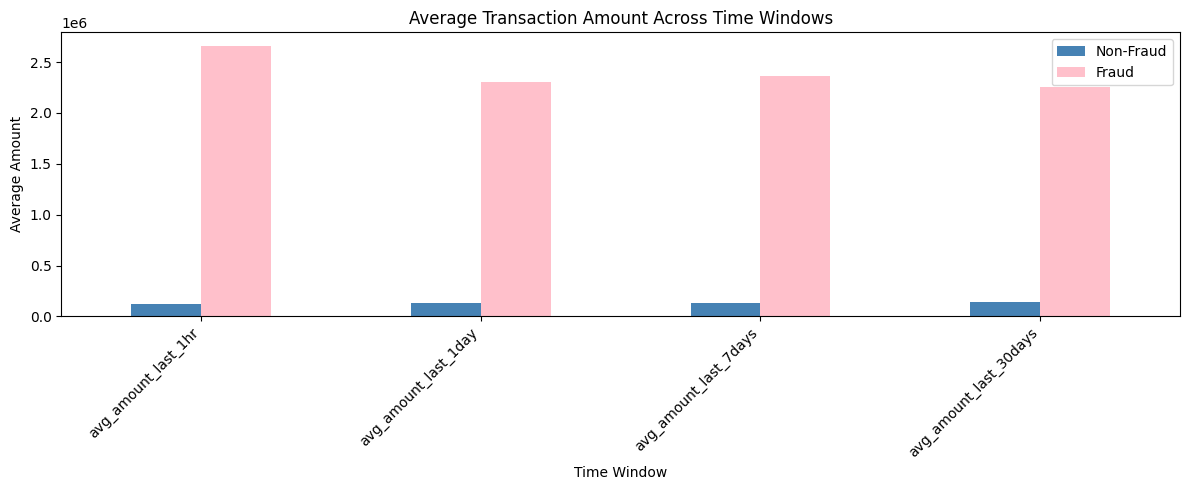

In [ ]:
# VIZUALIZING THE AMOUNT SENT TREND
avg_cols = ['avg_amount_last_1hr', 'avg_amount_last_1day',
            'avg_amount_last_7days', 'avg_amount_last_30days']

# Calculate the mean of each column grouped by fraud label
avg_by_fraud = fdd.groupby('fraud_label')[avg_cols].mean()

avg_by_fraud.T.plot(kind='bar', figsize=(12, 5), color=['steelblue', 'pink'])
plt.title('Average Transaction Amount Across Time Windows')
plt.xlabel('Time Window')
plt.ylabel('Average Amount')
plt.legend(['Non-Fraud', 'Fraud'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

From the diagram, across all four time windows, fraud transactions average dramatically higher amounts than non-fraud, with the pattern remaining consistently stark regardless of the time window examined.
Across all windows: Non-fraud bars are nearly flat and barely visible, hovering around 100,000–150,000 across all four time windows. Fraud bars on the other hand tower at approximately 2.3–2.6 million across all windows, representing roughly 15–20 times the average transaction amount of legitimate users.

Unlike the transaction count charts where gaps grew over time, the average amount gap here remains consistently large across 1hr, 1day, 7days and 30days. Mmeaning fraudsters maintain persistently high transaction amounts regardless of the time window, not just in isolated bursts. This is one of the most telling visualizations in the entire analysis because the massive and consistent gap between fraud and non-fraud average amounts across every time window makes avg_amount_last_1hr, avg_amount_last_7days and avg_amount_last_30days extremely strong features for fraud detection. The fact that fraudsters consistently transact at 15–20 times the amount of legitimate users across all time windows strongly suggests that transaction amount and its rolling averages should be among the top priority features in the classification models.

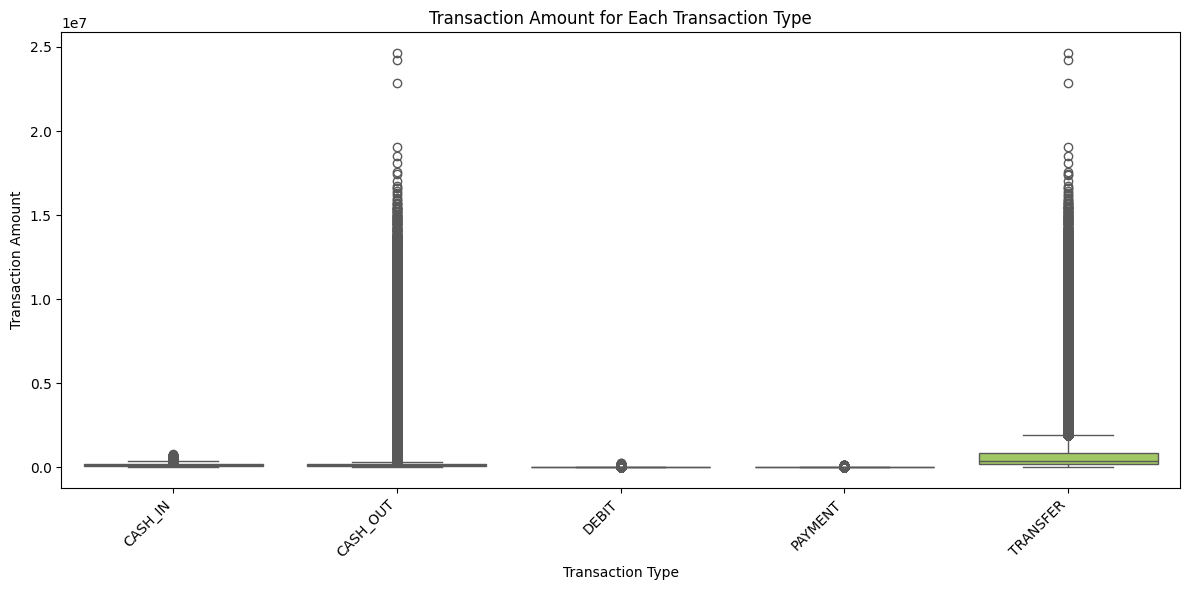

In [ ]:
# VISUALIZATION OF TRANSACTION AMOUNT BY TRANSACTION TYPE USING SEABORN
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=fdd,
    x='transaction_type',       # group by type
    y='transaction_amount',     # show amount for each type
    palette='Set2'
)
plt.title('Transaction Amount for Each Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Transaction Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

From the visuals, cash_in, debit and payment are all tightly compressed near zero with minimal spread, indicating consistently small and predictable transaction amounts across these types.
CASH_OUT has a long whisker extending to 15 million with extreme outliers reaching 25 million, signaling that while most transactions are small, a significant number involve suspiciously large amounts.
TRANSFER is the most distinct with a visibly larger box sitting higher on the y-axis, a median around 500,000 and outliers also reaching 25 million, making it the transaction type with the highest and most spread out amounts overall.

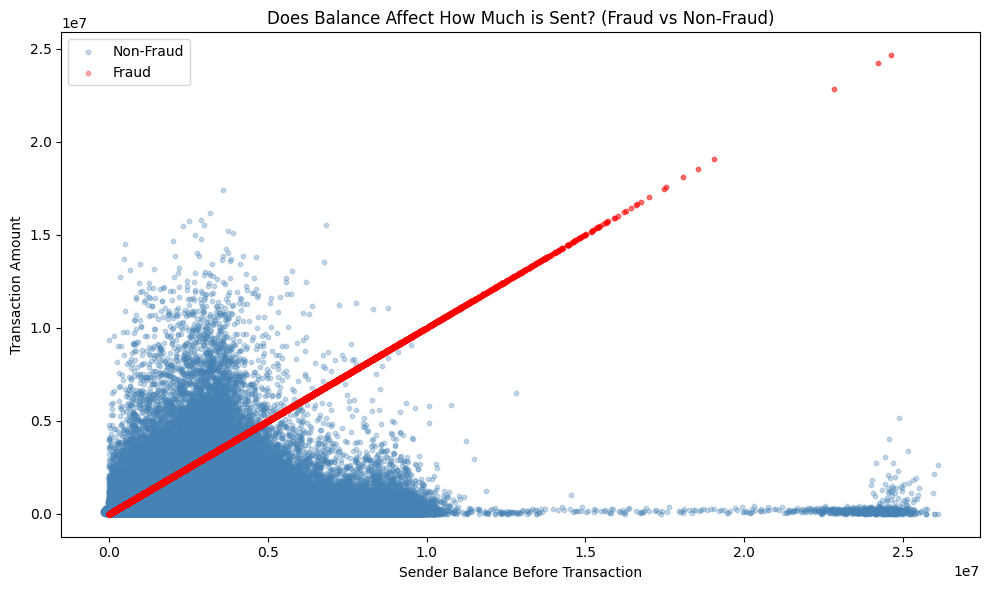

In [ ]:
# VISUALIZATION OF SENDER'S BALANCE VS TRANSACTION AMOUNT BY FRAUD LABEL
plt.figure(figsize=(10, 6))

# Plot non-fraud first
plt.scatter(
    non_fraud['sender_balance_before'],  # x axis
    non_fraud['transaction_amount'],     # y axis
    alpha=0.3, color='steelblue', s=10, label='Non-Fraud'
)

# Plot fraud on top
plt.scatter(
    fraud['sender_balance_before'],
    fraud['transaction_amount'],
    alpha=0.3, color='red', s=10, label='Fraud'
)

plt.title('Does Balance Affect How Much is Sent? (Fraud vs Non-Fraud)')
plt.xlabel('Sender Balance Before Transaction')
plt.ylabel('Transaction Amount')
plt.legend()
plt.tight_layout()
plt.show()

From the visuals, the non-fraud (blue) points are heavily clustered near the origin with low balances and low transaction amounts, spreading loosely across the chart with no clear directional pattern which confirms that legitimate users do not necessarily send more just because they have a higher balance. Meanwhile, fraud (red) shows a strikingly clean and almost perfect diagonal line, meaning fraudulent transactions follow a very strong linear pattern where the higher the sender's balance, the higher the transaction amount. This suggests fraudsters deliberately drain accounts proportionally by sending amounts closely matching or nearly equal to the available balance.

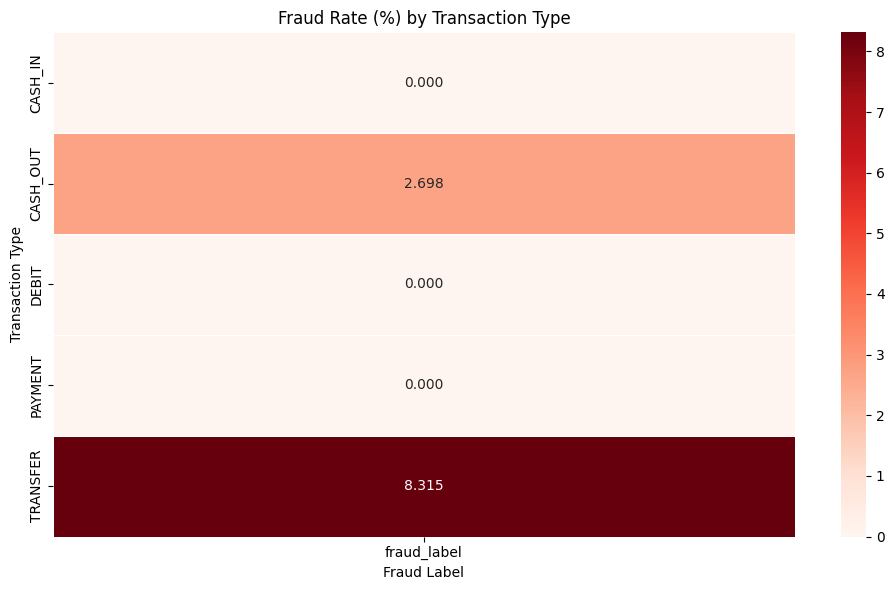

In [ ]:
# VIZUALIZATION OF FRAUD RATE BY TRANSACTION TYPE
fraud_by_ttype = fdd.groupby('transaction_type')['fraud_label'].mean().mul(100)
fraud_by_ttype = fraud_by_ttype.to_frame()
plt.figure(figsize=(10, 6))
sns.heatmap(
    fraud_by_ttype,
    annot=True,         # show the actual % numbers
    fmt='.3f',          # round to 1 decimal place
    cmap='Reds',        # darker red = higher fraud rate
    linewidths=0.5
)
plt.title('Fraud Rate (%) by Transaction Type')
plt.xlabel('Fraud Label')
plt.ylabel('Transaction Type')
plt.tight_layout()
plt.show()

From the visuals, CASH_IN, DEBIT and PAYMENT all show a 0.0% fraud rate, meaning fraud occurs at an extremely low rate that couldn't be captured after rouding to 3sf which means that transactions are safe to make through these channels. CASH_OUT carries a moderate fraud rate of 2.7%, confirming it as a risk channel but not the dominant one. TRANSFER on the other hand is by far the highest risk transaction type with a fraud rate of 8.3% which is over 3 times higher than CASH_OUT and the darkest cell on the heatmap, making it the single most fraud-prone channel in the entire dataset.

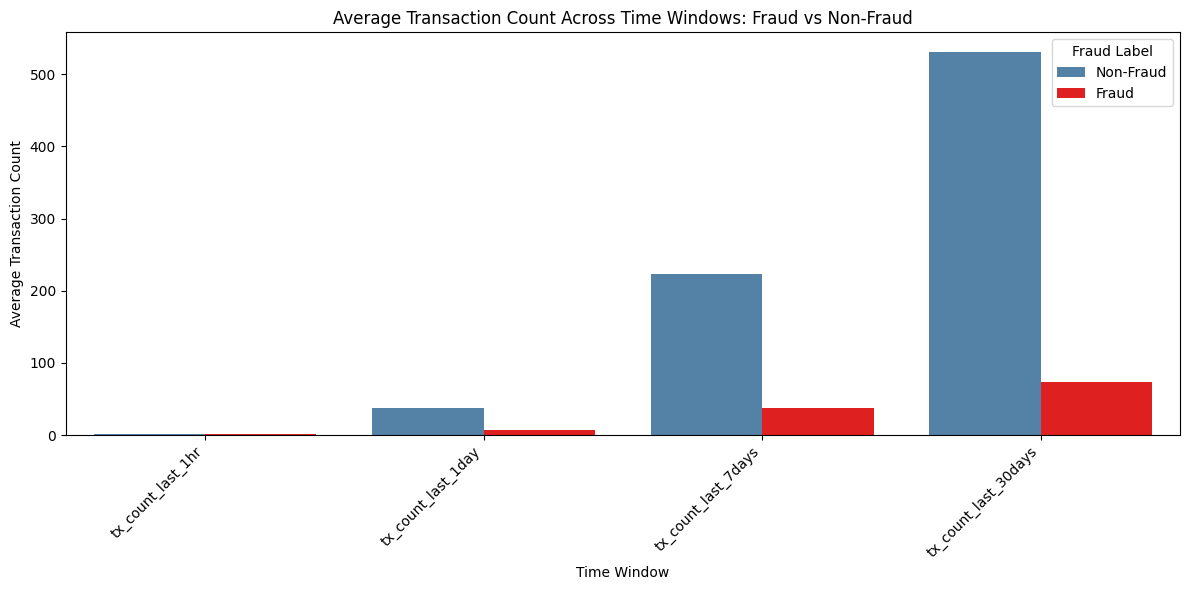

In [ ]:
# VISUALIZATION OF TRANSACTION WINDOW BY FRAUD COUNT/LABEL
all_tx = ['tx_count_last_1hr', 'tx_count_last_1day',
           'tx_count_last_7days', 'tx_count_last_30days']

# Reshape for seaborn
tx_flabel = fdd[all_tx + ['fraud_label']].melt(
    id_vars='fraud_label',
    var_name='Time Window',
    value_name='Avg TX Count'
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=tx_flabel,
    x='Time Window',
    y='Avg TX Count',
    hue='fraud_label',
    palette=['steelblue', 'red'],
    errorbar=None               # remove error bars to keep it clean
)
plt.title('Average Transaction Count Across Time Windows: Fraud vs Non-Fraud')
plt.xlabel('Time Window')
plt.ylabel('Average Transaction Count')
plt.legend(title='Fraud Label', labels=['Non-Fraud', 'Fraud'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

From the visuals, non-fraud consistently outnumbers fraud across all four time windows, with the gap widening significantly as the window extends from nearly equal at 1hr, to roughly 5:1 at 1day, 6:1 at 7days and 7:1 at 30days.
Fraud transactions remain relatively flat and low across all windows, peaking at only around 75 at the 30-day mark compared to non-fraud's 530, confirming that fraudulent accounts maintain minimal sustained transaction activity over time.

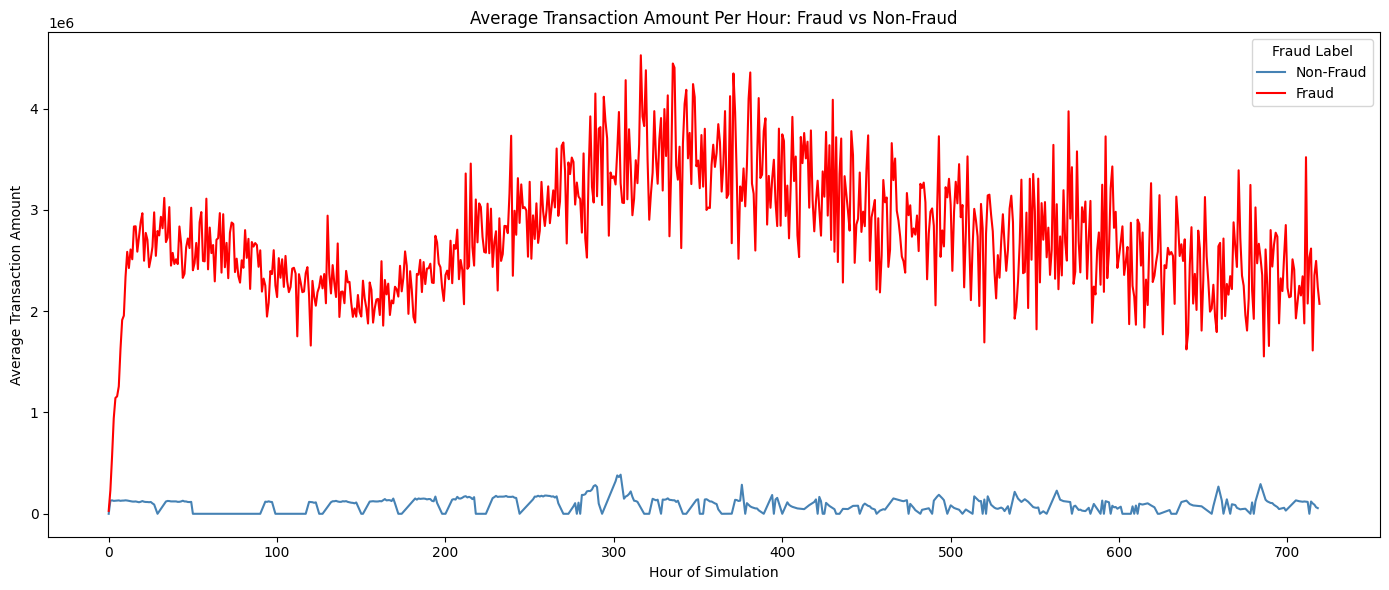

In [ ]:
# VISUALIZATION OF AVERAGE TRANSACTION PER HOUR OF SIMULATION
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=fdd,
    x='hour_of_simulation',     # x axis = time
    y='transaction_amount',     # y axis = average amount (seaborn does this automatically)
    hue='fraud_label',          # separate line for fraud and non-fraud
    palette={0: 'steelblue', 1: 'red'},
    errorbar=None               # remove confidence interval shading to keep it clean
)
plt.title('Average Transaction Amount Per Hour: Fraud vs Non-Fraud')
plt.xlabel('Hour of Simulation')
plt.ylabel('Average Transaction Amount')
plt.legend(title='Fraud Label', labels=['Non-Fraud', 'Fraud'])
plt.tight_layout()
plt.show()

From the visuals, it could be noted that:

1. Non-Fraud (blue) remains virtually flat and near zero across the entire 720-hour simulation, showing no significant spikes or patterns — confirming
that legitimate transaction amounts are consistently small and stable throughout the period.

2. Fraud (red) starts high from hour 0, stabilizes around 2.5 million between hours 20–200, then surges dramatically between hours 200–450 peaking at approximately 4.5 million before gradually declining but remaining highly volatile for the remainder of the simulation.

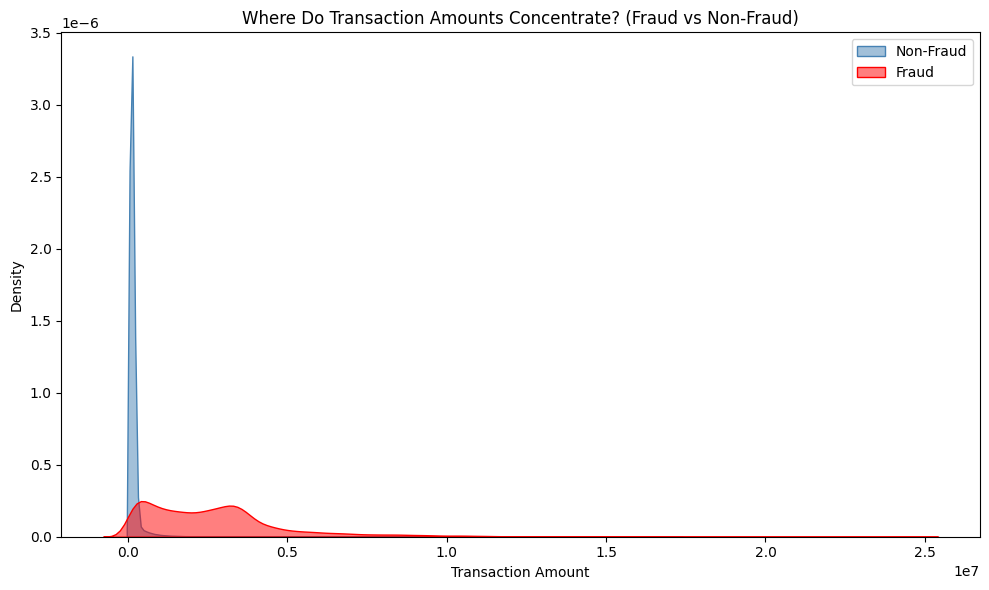

In [ ]:
# VISUALIZATION OF FRAUD LABEL BY TRANSACTION AMOUNT
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=fdd[fdd['fraud_label'] == 0],   # non-fraud
    x='transaction_amount',
    fill=True,                            # shade under the curve
    color='steelblue',
    label='Non-Fraud',
    alpha=0.5
)
sns.kdeplot(
    data=fdd[fdd['fraud_label'] == 1],   # fraud
    x='transaction_amount',
    fill=True,
    color='red',
    label='Fraud',
    alpha=0.5
)
plt.title('Where Do Transaction Amounts Concentrate? (Fraud vs Non-Fraud)')
plt.xlabel('Transaction Amount')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

The diagram above showed that:

1. Non-Fraud (blue) shows an extremely sharp and narrow peak right at zero, confirming that the vast majority of legitimate transactions are very small amounts with almost no spread beyond 1 million.
2. Fraud (red) has a much lower and flatter curve that spreads broadly from near zero all the way past 5 million, with a secondary bump around 3–4 million suggesting a second concentration of fraud at higher amounts.

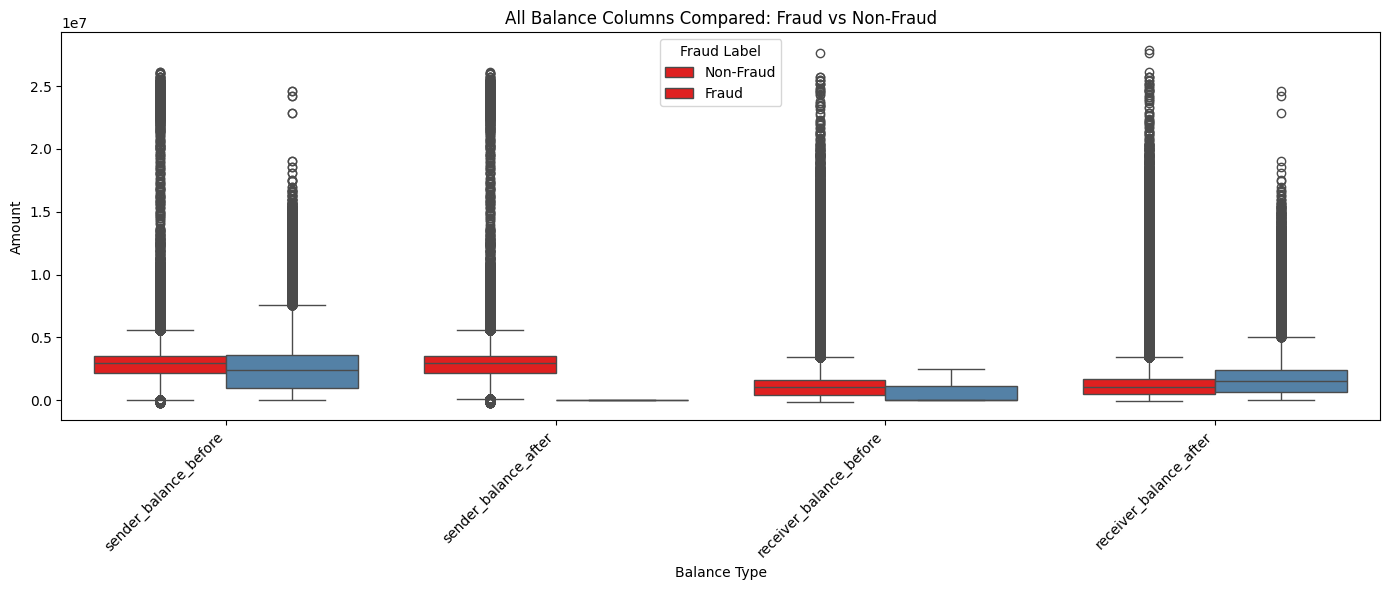

In [ ]:
# VISUALIZATION OF ALL BALANCE COUNT AGAINST FRAUD LABEL
balance_count = ['sender_balance_before', 'sender_balance_after',
                'receiver_balance_before', 'receiver_balance_after']

# Reshape data so seaborn can read it easily
balance_data = fdd[balance_count + ['fraud_label']].melt(
    id_vars='fraud_label',      # keep fraud label as the grouping column
    var_name='Balance Type',    # new column for balance column names
    value_name='Amount'         # new column for the actual values
)

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=balance_data,
    x='Balance Type',
    y='Amount',
    hue='fraud_label',
    palette=['red', 'steelblue']
)
plt.title('All Balance Columns Compared: Fraud vs Non-Fraud')
plt.xlabel('Balance Type')
plt.ylabel('Amount')
plt.legend(title='Fraud Label', labels=['Non-Fraud', 'Fraud'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

From the analysis each of the balances of both senders and receiers, it was discovered that:

1. Sender Balance Before: Fraud (red) and non-fraud (blue) boxes are at similar levels around 2.5–3 million, with non-fraud showing a slightly wider spread and both groups sharing extreme outliers reaching 25 million.
2. Sender Balance After: The fraud's box remains at the same level as before while non-fraud's box drops dramatically close to zero, suggesting that after legitimate transactions balances decrease normally while fraud accounts maintain their balance after the transaction.
3. Receiver Balance Before and After: Both groups are compressed lower with smaller boxes, and the difference between fraud and non-fraud is minimal across both receiver columns, confirming that receiver balance is a weak fraud differentiator.

In [ ]:
# Identify 'Mule' accounts (Destinations receiving multiple fraudulent transfers)
fraud_dest_counts = fdd[fdd['fraud_label'] == 1]['receiver_id'].value_counts()
top_mules = fraud_dest_counts[fraud_dest_counts > 1]

print(f"Number of destination accounts flagged as repeat Mules: {len(top_mules)}")
print("\nTop 5 Potential Mule Accounts:")
print(top_mules.head())

Number of destination accounts flagged as repeat Mules: 4937

Top 5 Potential Mule Accounts:
receiver_id
M5653234571    19
M3204233875    16
M7088145632    16
M2472060770    15
M9855751610    15
Name: count, dtype: int64


This checks if certain destination accounts (receiver_id) are being used repeatedly for fraud.

It was observed that 4,937 destination accounts act as “repeat mules,” receiving more than one fraudulent transaction. Some of the most active accounts were used up to 19 times to collect stolen funds. This pattern suggests that the fraud is not made up of isolated incidents but is likely part of an organized network using specific “sinkhole” accounts to accumulate illicit gains.

In [ ]:
#AVERAGE FRAUD VS TRANSACTION AMOUNT
fdd.groupby('fraud_label')['transaction_amount'].mean().round(1)

,transaction_amount
fraud_label,
0,1.227189e+05
1,2.757426e+06


This shows that fraudulent transactions involve significantly higher amounts

0 represents legitimate transactions: The average amount for legitimate transactions

1 represents fraudulent transactions: The average amount for fraudulent transactions

#### **Important Highlight:**
**Original dataset - fd**

**Copy of Original Dataset containing column renames, and without the dropped columns - fdd**

**Copy of fdd containing additional columns 'insufficient balance', 'week group' and 'hour of day' - df**

**df was created in order to compare if the new features correlates with fraud label and compare the analysis with fdd in order to determine the features that would be used in the classification models.**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5420481 entries, 0 to 5420480
Data columns (total 28 columns):
 #   Column                       Dtype   
---  ------                       -----   
 0   row_id                       int32   
 1   hour_of_simulation           int16   
 2   transaction_type             category
 3   transaction_amount           float32 
 4   sender_id                    object  
 5   sender_balance_before        float32 
 6   sender_balance_after         float32 
 7   receiver_id                  object  
 8   receiver_balance_before      float32 
 9   receiver_balance_after       float32 
 10  fraud_label                  int8    
 11  unauthorized_overdraft_flag  int8    
 12  total_sent_last_1hr          float32 
 13  total_sent_last_1day         float32 
 14  total_sent_last_7days        float32 
 15  total_sent_last_30days       float32 
 16  tx_count_last_1hr            int8    
 17  tx_count_last_1day           int8    
 18  tx_count_last_7days   

#### **FEATURE ENGINEERING PT2**

In [ ]:
# Applying Label Encoding to 'insufficient balance'
df['insufficient_balance_encoded'] = label_encoder.fit_transform(df['insufficient_balance'])
print(df[['insufficient_balance', 'insufficient_balance_encoded']].sample(5))

# Applying Label Encoding to 'week_group'
df['week_group_encoded'] = label_encoder.fit_transform(df['week_group'])
print(df[['week_group', 'week_group_encoded']].sample(5))

         insufficient_balance  insufficient_balance_encoded
4543130                 False                             0
2819192                 False                             0
204502                  False                             0
3838341                 False                             0
2753054                 False                             0
                 week_group  week_group_encoded
4720628  Week 4 (Day 22-30)                   3
3079393  Week 3 (Day 15-21)                   2
1639360   Week 2 (Day 8-14)                   1
3856609  Week 3 (Day 15-21)                   2
5237670  Week 4 (Day 22-30)                   3


In [ ]:
# New summary after encoding
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5420481 entries, 0 to 5420480
Data columns (total 30 columns):
 #   Column                        Dtype   
---  ------                        -----   
 0   row_id                        int32   
 1   hour_of_simulation            int16   
 2   transaction_type              category
 3   transaction_amount            float32 
 4   sender_id                     object  
 5   sender_balance_before         float32 
 6   sender_balance_after          float32 
 7   receiver_id                   object  
 8   receiver_balance_before       float32 
 9   receiver_balance_after        float32 
 10  fraud_label                   int8    
 11  unauthorized_overdraft_flag   int8    
 12  total_sent_last_1hr           float32 
 13  total_sent_last_1day          float32 
 14  total_sent_last_7days         float32 
 15  total_sent_last_30days        float32 
 16  tx_count_last_1hr             int8    
 17  tx_count_last_1day            int8    
 18  tx

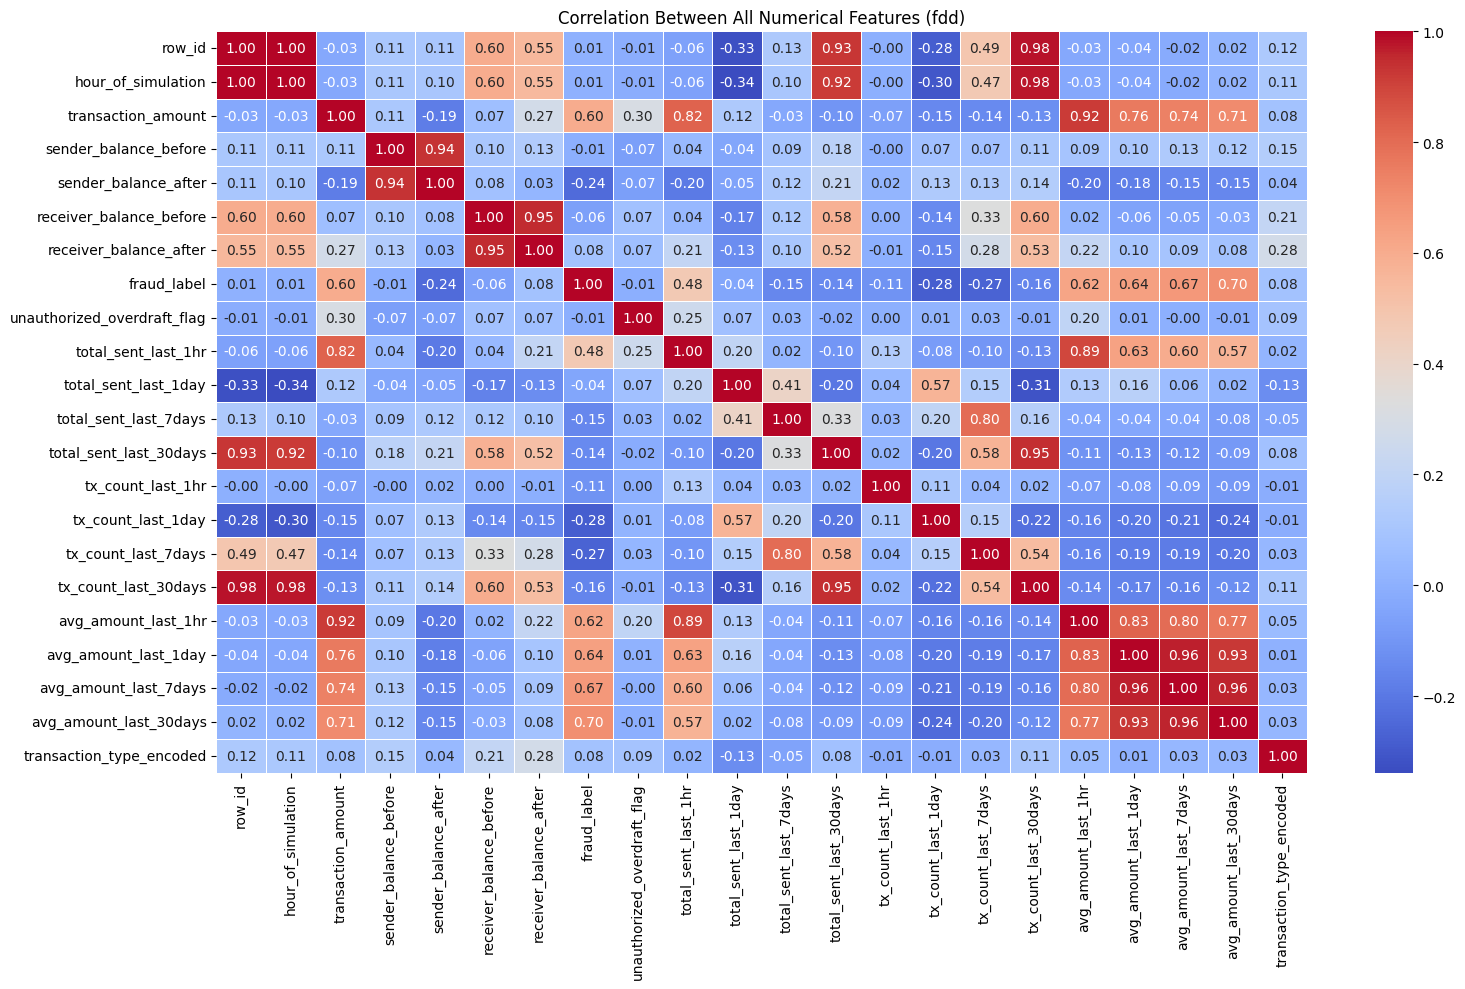

In [ ]:
# CORRELATION MATRIX AND ANALYSIS
num_cols = fdd.select_dtypes(include='number').columns

plt.figure(figsize=(16, 10))
sns.heatmap(
    fdd[num_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Correlation Between All Numerical Features (fdd)')
plt.tight_layout()
plt.show()

This code performs multivariate correlation analysis, calculating Pearson correlations between all numerical features and visualizing them in a heatmap. It helps spot redundant features and see how each variable relates to the fraud label.

The analysis reveals several key points:

High feature redundancy exists among rolling-window features (e.g., avg_amount_last_* and tx_count_last_*), which are highly collinear.

Fraud has weak linear correlation with individual features, showing that it’s driven by complex, non-linear behavioral patterns rather than simple triggers like a single large transaction.

Sender balances before and after transactions are nearly perfectly correlated, suggesting that the balance change (delta) is a more meaningful predictor than raw balances.

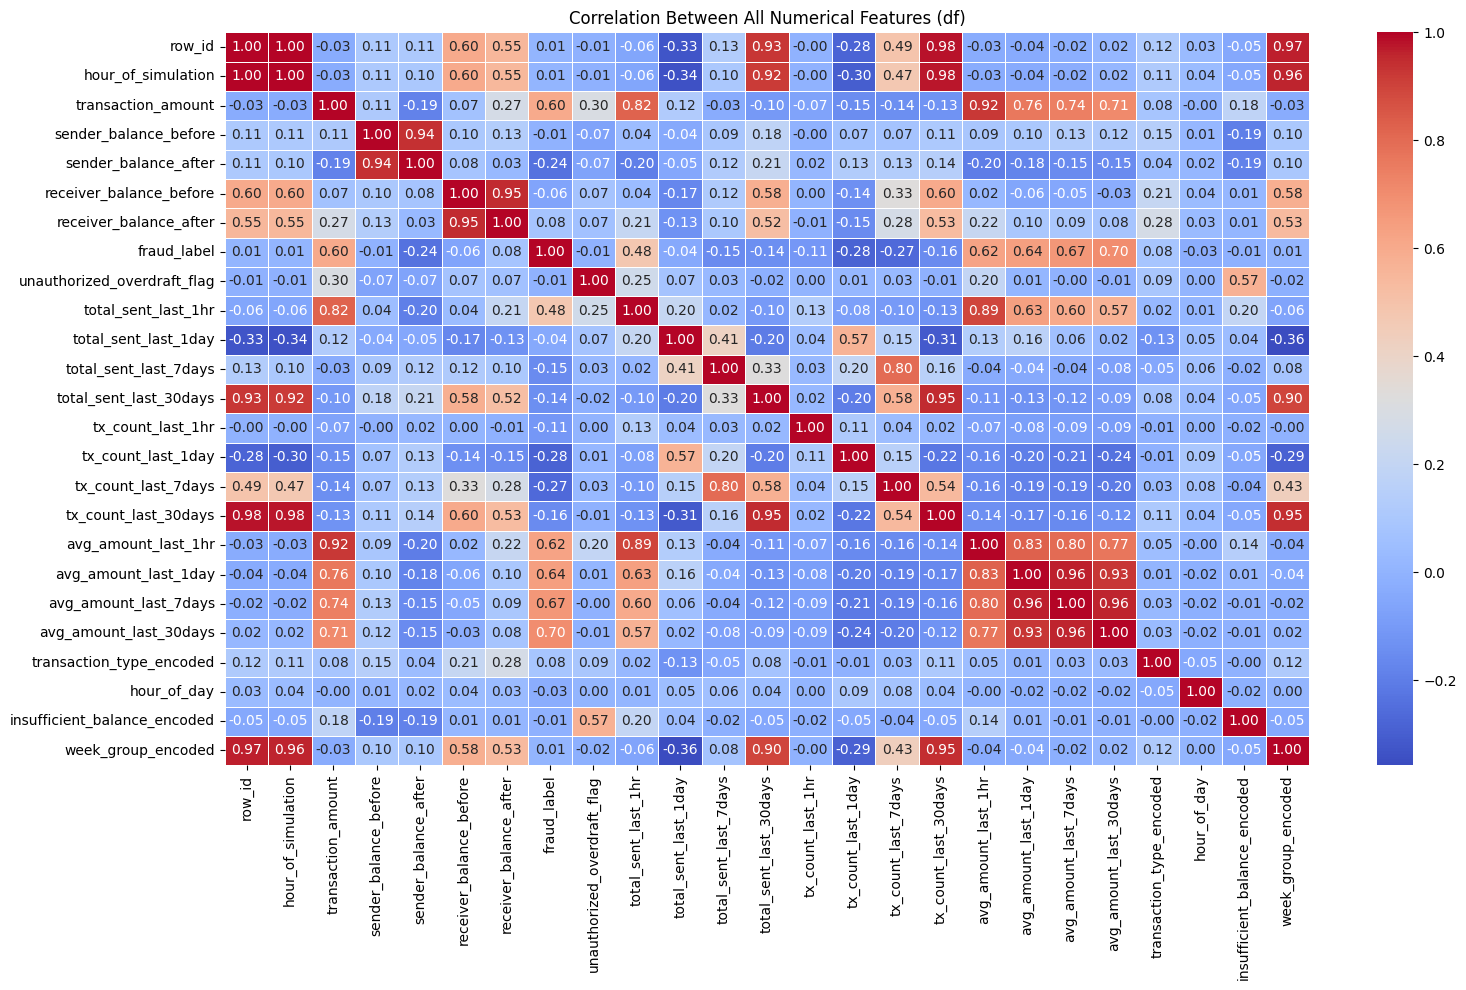

In [ ]:
# CORRELATION ANALYSIS WITH 'INSUFFICIENT BALANCE', 'WEEK GROUP' AND 'HOUR OF DAY'
# CORRELATION MATRIX AND ANALYSIS
num_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(16, 10))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Correlation Between All Numerical Features (df)')
plt.tight_layout()
plt.show()

##### **REPORT ON THE CORRELATION TO BE IDENTIFIED WITH**

*CORRELATION HEATMAP REPORT-df*

The correlation analysis reveals severe multicollinearity issues with row_id and hour_of_simulation correlating perfectly at 1.00, while tx_count_last_30days and week_group_encoded both correlate with row_id at 0.97–0.98 making them entirely redundant. The balance pairs sender_balance_before/after and receiver_balance_before/after correlate at 0.94–0.95 respectively, and the three average amount columns correlate between 0.93–0.96 with each other all carrying near-identical information. In terms of fraud signal, the strongest predictors are avg_amount_last_30days at 0.70, avg_amount_last_7days at 0.67, avg_amount_last_1day at 0.64, avg_amount_last_1hr at 0.62 and transaction_amount at 0.60. The three additional engineered features unique to the correlation analysis (week_group_encoded, hour_of_day and insufficient_balance_encoded) contribute negligible fraud signal at 0.01, -0.03 and 0.14 respectively, with week_group_encoded introducing additional multicollinearity by nearly duplicating row_id.

*CORRELATION HEATMAP REPORT-fdd*

The correlation analysis reveals presents a cleaner and more focused feature set with the same core multicollinearity issues present but less severe overall. The fraud label correlations are identical to the df correlation report for the shared features avg_amount_last_30days leading at 0.70, followed by avg_amount_last_7days at 0.67, avg_amount_last_1day at 0.64, avg_amount_last_1hr at 0.62, transaction_amount at 0.60 and total_sent_last_1hr at 0.48 as a moderate signal. Additional notable correlations include receiver_balance_before at -0.28 as a negative moderate signal and transaction_type_encoded at 0.08 which while weak carries strong domain relevance given the earlier finding that TRANSFER transactions carry an 8.3% fraud rate. The absence of the extra engineered features from the df correlation report keeps the feature space leaner and the multicollinearity risk lower, making the correlation patterns easier to interpret and act upon.

*CONCLUSION*

The primary difference between the two heatmaps is that the df correlation report introduces three additional engineered features which are  week_group_encoded, hour_of_day and insufficient_balance_encoded, none of which meaningfully improve fraud signal while week_group_encoded actively worsens multicollinearity by nearly duplicating row_id at 0.97. The fdd correlation report is the more useful heatmap for model building because it presents the same core fraud signals in a cleaner, less redundant feature space without the added noise of low-signal engineered columns. In conclusion, both heatmaps confirm that the rolling average amount features and transaction_amount are the dominant fraud predictors, severe multicollinearity must be addressed by dropping redundant pairs before modeling.

### **REPORT EVALUATION- STAGE 3**

The bivariate and multivariate analysis stage provided deep insight into the relationships between individual features and the fraud label, confirming and extending the findings from Stage 2. The analysis was carried out across transaction type, temporal patterns, balance behavior, transaction amounts, overdraft relationships and correlation structure.

Fraud by Transaction Type: The countplot of fraud by transaction type confirmed that fraud is almost entirely concentrated in TRANSFER and CASH_OUT transactions, with the remaining types CASH_IN, PAYMENT and DEBIT showing negligible fraud counts. This points to a classic "Drain-and-Exit" fraud workflow where funds are first moved via TRANSFER and then extracted via CASH_OUT. The fraud rate heatmap quantified this by precisely revealing that TRANSFER carries an 8.3% fraud rate, CASH_OUT 2.7%, while CASH_IN, DEBIT and PAYMENT all show 0.0% fraud rate.

Temporal Fraud Patterns: Fraud frequency by hour of simulation revealed an uneven distribution across the 720-hour period, with notable activity gaps and peaks. Mapping the simulation hours to a 24-hour cycle revealed that fraud probability peaks between 4:00 AM and 9:00 AM which are periods of reduced monitoring and slower victim response while high transaction volume periods in the evening (8 PM–11 PM) show lower fraud rates despite higher activity. The weekly analysis confirmed that fraud escalates in Week 4 (29.78%) compared to the stable 22–24% range in Weeks 1–3, suggesting end-of-month patterns in fraudulent behavior.

Transaction Amount vs Fraud Label: The violin plot comparing transaction amounts across fraud and non-fraud labels showed a dramatically wider distribution for fraud with a broad body spanning up to 7.5 million and outliers reaching 25 million compared to the extremely narrow non-fraud distribution concentrated near zero. The KDE plot reinforced this finding, showing non-fraud peaking sharply near zero while fraud spreads broadly with a secondary concentration around 3–4 million. The average transaction amount for fraudulent transactions was significantly higher than for legitimate ones.

Sender and Receiver Balance Analysis: The scatter plot of sender_balance_before vs transaction_amount revealed the most striking finding in the entire analysis i.e fraudulent transactions form an almost perfect diagonal line, meaning fraudsters systematically send amounts proportional to or nearly equal to their full available balance, regardless of account size. This "total drain" pattern is a powerful fraud signature. In contrast, non-fraud points cluster near the origin with no directional pattern. The balance before/after histograms confirmed that sender balance changes very little at the population level, and 5,325 transactions with negative sender balances showed a 0.00% fraud rate confirming these are legitimate credit behaviors rather than fraud indicators.

Insufficient Balance Analysis: The crosstab analysis of insufficient_balance (transactions where sender_balance_before < transaction_amount) vs fraud_label produced a counter-intuitive finding which is all insufficient balance cases showed 0% fraud rate. This confirms that in this dataset, fraudsters always have sufficient balance before executing their drain transactions, making the insufficient_balance flag a weak fraud predictor despite its logical appeal.

Unauthorized Overdraft vs Fraud: The overdraft analysis revealed that all unauthorized overdraft cases (1.0% flag rate) showed a 0.0% association with fraud. This counter-intuitive result suggests that the overdraft alert system in this dataset operates independently of fraud detection and itflags legitimate edge cases rather than fraudulent activity.

Mule Account Detection: The mule account analysis identified 4,937 destination receiver accounts receiving more than one fraudulent transfer, with the top accounts used up to 19 times. This reveals a coordinated laundering infrastructure where funds are funneled through dedicated mule accounts, suggesting that receiver_id repeat patterns could be a useful fraud signal beyond what correlation analysis alone captures.

Rolling Amount Windows vs Fraud: The average transaction amount across all time windows (1hr, 1day, 7days, 30days) showed a consistently massive gap where fraud averages 2.3–2.6 million across all windows versus non-fraud at 100,000–150,000, representing a 15–20x differential that remains stable regardless of the time window. The line plot of average transaction amount per simulation hour confirmed that fraud amounts are not only higher but highly volatile spiking and dropping sharply across all 720 hours while non-fraud remains flat throughout.

Transaction Count Windows vs Fraud: Legitimate users consistently accumulate far more transactions than fraudsters across all time windows, with the gap growing from nearly equal at 1hr (2 vs 1.2) to approximately 7:1 at 30days (530 vs 75). This confirms that fraudsters operate in short targeted bursts rather than maintaining sustained transaction activity making the longer time window count features more discriminative for model classification.

Correlation Analysis: The correlation heatmap (fdd) identified the strongest fraud predictors as avg_amount_last_30days (0.70), avg_amount_last_7days (0.67), avg_amount_last_1day (0.64), avg_amount_last_1hr (0.62) and transaction_amount (0.60). Moderate signals include total_sent_last_1hr (0.48) and receiver_balance_before (-0.28). Severe multicollinearity exists between row_id/hour_of_simulation (1.00), balance before/after pairs (0.94–0.95), avg_amount columns (0.93–0.96) and tx_count_last_30days with row_id (0.98). The extended df heatmap including insufficient_balance_encoded and week_group_encoded added minimal fraud signal (0.14 and 0.01 respectively) while introducing additional multicollinearity, confirming that the base fdd feature set is more suitable for modelling.

CONCLUSION:
In conclusion, it is deduced that Fraud is channel-specific (TRANSFER and CASH_OUT only), time-sensitive (peaks during early morning hours and end-of-month periods), amount-driven (fraudsters transact at 15–20x the average legitimate amount), and balance-draining (the near-perfect diagonal scatter pattern confirms systematic account emptying). The rolling average amount features emerged as the strongest and most consistent fraud predictors across all time windows, while the transaction count features confirmed that fraudsters maintain low sustained activity compared to legitimate users. The multicollinearity analysis identified several redundant feature pairs that must be addressed during the preprocessing stage to ensure model quality. Together, these findings provide a strong and well-evidenced foundation for feature selection and model building in the subsequent stages.


## **STAGE 4- DATA PREPROCESSING**

Based on the EDAs carried out and the analytical understanding of the dataset, the main features that are necessary for the classification models are:

1. **Transaction amount**: This feature represents the total transaction amount by all each users in the dataset. It showed a very positive and significant relationship (correlation) with fraud label (0.60) and is an important feature that is important for the model's prediction.
2. **Average transaction amount in the last 30 days**: This feature also showed meaningful relationship with fraud label and tracing back to the EDAs where the fact that fraudsters consistently transact at 15–20 times the amount of legitimate users across all time windows strongly suggests that transaction amount and its rolling averages should be among the top priority features in the classification models.
3. **Transaction type (encoded)**: Although this showed to have a weak relationship with fraud label, the transfer and cashout types stood out to be the major routes that fraud was carried out so therefore the transaction type (transactiontype encoded) is being consdidered in predicting the output
4. **Week Group**: Although this also showed an extremely weak relationship with fraud label, it is worth considering since it narrows down the particular hours that fraud transactions occured in a 4 week window, it is a necessary feature replacing hour of simulation that captures the all the hours that transaction occured.
5. **Receiver's Balance after**: This feature is being added because it is a revealing factor that highglights the specific receivers of fraudulent transactions and also from the correlation analysis, there is a weak relationship between the feature and fraud label however it is a significant feature that could aid the models in their prediction.
6. **Transaction Sent in the last 1hr**: This was the only transaction amount sent picked from all transaction sent time window because it showed the highest correlation with fraud label amongst others and also from the earlier visualizations and analysis, it showed to be the one thhat best depicts the spread of the fraud transaction compared to the others and in order to reduce the noise it was the only one picked.

**DROPPED FEATURES AND WHY**

1. ***row_id and hours of simulation***: they both showed to be redundant with each other and also showed insignificant relationship with fraud label
2. ***all trancaction amount sent time windows execept last 1hr***: Since the average transaction amout showed to be more significant and useful in predicting the fraud labels, the total transaction amount sent were dropped to reduce noise
3. ***sender's balance before, after and receiver's balance before***: they all showed insignificant relationship with fraud label and this is also confirmed through earlier visualizations where in the correlation, sender balance before and after showed to be highly redundant to each other and showed a negative ccorrelation with fraud label which would cause noise in the model and pull it back, same thing was noticed with the receiver's balance before and were dropped to reduce noise.
4. ***unauthorized overdraft and insufficient balance***: based on earlier analysis, it was confirmed that these two features has no relationships with fraud label where unauthorized transactions were only associated with internal fluctuations and the all the users with insufficient balances carried out legitimate transactions
5. ***transaction count in 1 day, 1hr and 30 days***: due to their weak relationship and inability to fully depict the spread of fraud transaction by their counts, they were dropped

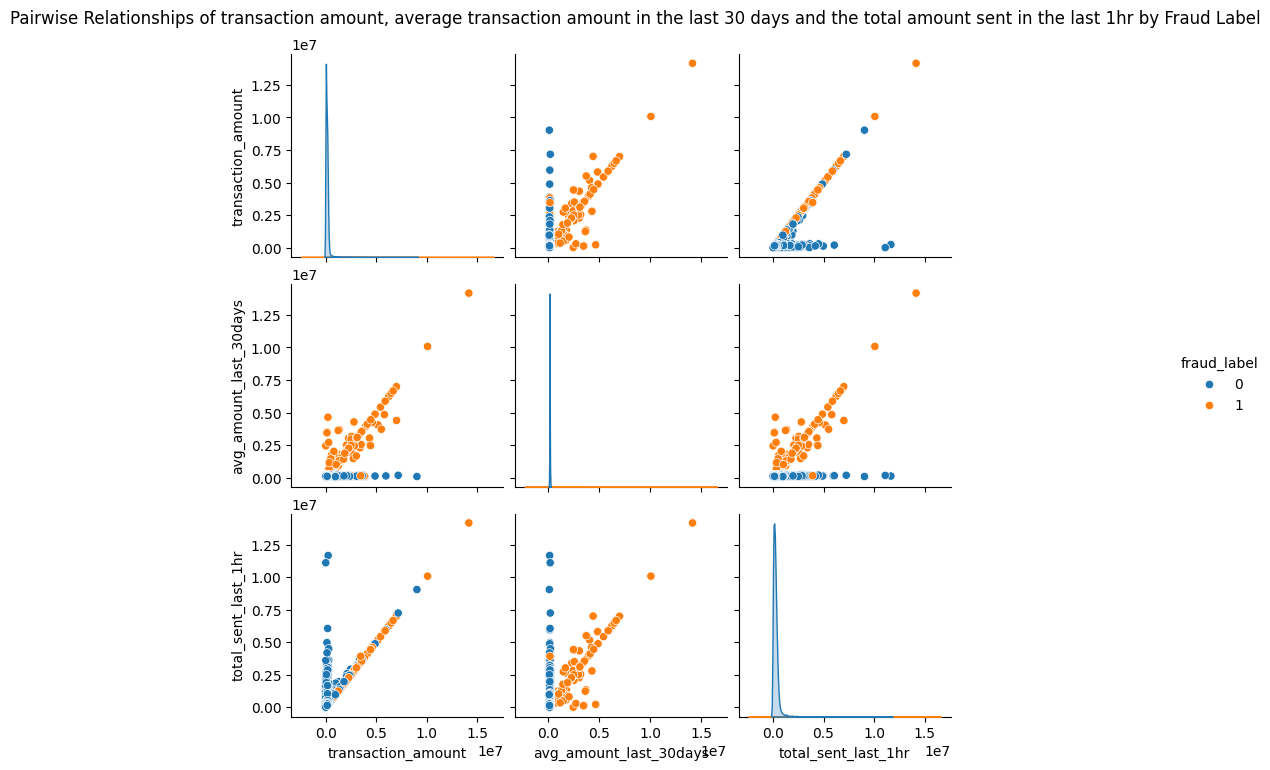

In [ ]:
# PAIRPLOT OF THE HIGLY CORRELATED FEATURES WITH FRAUD LABEL (with only 10,000 samples)
pairplot1 = df[['transaction_amount',
                'avg_amount_last_30days',
                'total_sent_last_1hr',
                'fraud_label']].sample(10000)

sns.pairplot(pairplot1, hue= 'fraud_label', diag_kind='kde')
plt.suptitle("Pairwise Relationships of transaction amount, average transaction amount in the last 30 days and the total amount sent in the last 1hr by Fraud Label", y=1.02)
plt.show()

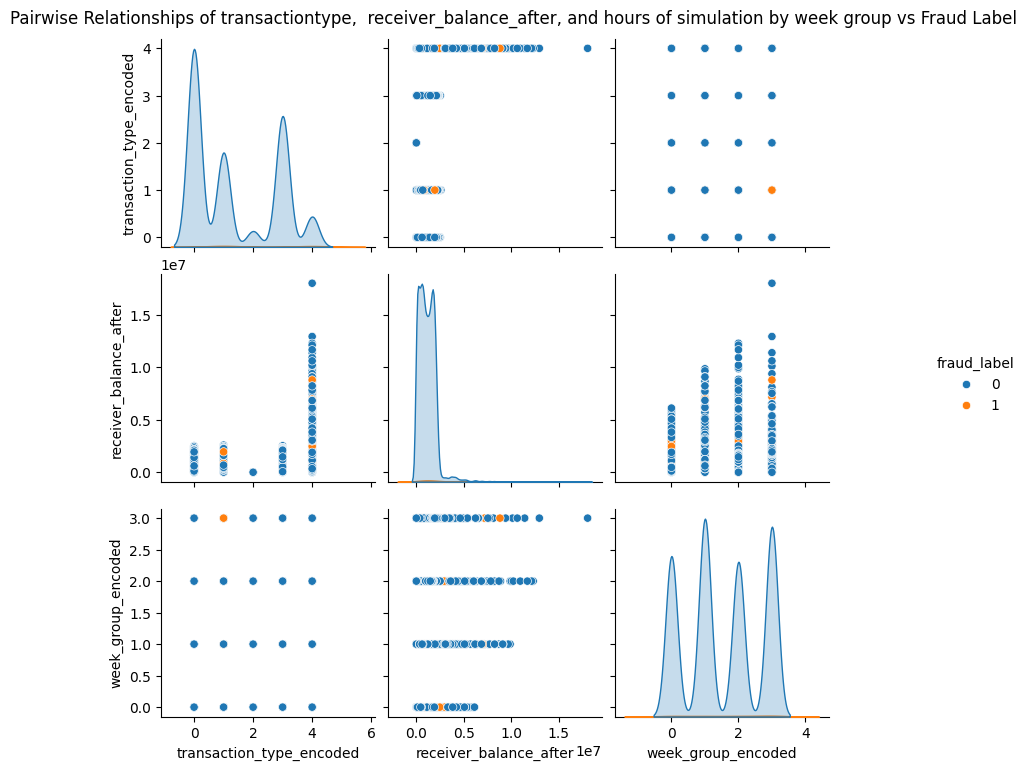

In [ ]:
# PAIRPLOT OF THE HIGLY CORRELATED FEATURES WITH FRAUD LABEL (with only 10,000 samples)
pairplot2 = df[['transaction_type_encoded',
                'receiver_balance_after',
                'week_group_encoded',
                'fraud_label']].sample(10000)

sns.pairplot(pairplot2, hue= 'fraud_label', diag_kind='kde')
plt.suptitle("Pairwise Relationships of transactiontype,  receiver_balance_after, and hours of simulation by week group vs Fraud Label", y=1.02)
plt.show()

#### **REPORT ON THE PAIRPLOT VISUALIZATION**
**Pairplot 1 — transaction_amount, avg_amount_last_30days, total_sent_last_1hr vs fraud_label.**

The first pairplot visualises the three amount-based features selected for the model, sampled at 10,000 records and coloured by fraud label (0=non-fraud, 1=fraud). Across the diagonal KDE plots, the fraud class (orange) shows a distribution that is dramatically flatter and more spread out than the non-fraud class (blue) for both transaction_amount and avg_amount_last_30days — confirming what the Stage 2 skewness analysis established (skew=12.622, kurtosis=230.642) and what the Stage 3 violin and KDE plots demonstrated visually that fraudulent amounts concentrate in a completely different range from legitimate ones. The non-fraud KDE peaks sharply near zero while the fraud KDE spreads broadly toward higher values, making both features highly discriminative. In the off-diagonal scatter plots, fraud points appear as a distinct cluster at higher values separated from the dense non-fraud cluster near the origin, which directly validates the feature selection decision to include these as the top two features. The total_sent_last_1hr vs fraud_label scatter shows a less clean separation, with fraud and non-fraud points overlapping more and this is consistent with the moderate correlation of 0.48 identified in Stage 3's heatmap.

**Pairplot 2 — transaction_type_encoded, receiver_balance_after, week_group_encoded vs fraud_label**

The second pairplot examines the three categorical and contextual features selected for the model. The transaction_type_encoded diagonal KDE shows two distinct peaks i.e fraud concentrated at values 1 (CASH_OUT) and 4 (TRANSFER) while non-fraud spreads across all five types visually confirming the fraud rate heatmap from Stage 3 which showed TRANSFER at 8.3% and CASH_OUT at 2.7% while CASH_IN, PAYMENT and DEBIT showed 0.0%. The receiver_balance_after distributions overlap considerably between fraud and non-fraud While the account-flooding pattern was identified in Stage 3's balance box plot analysis, the pairplot confirms it is a weaker and noisier signal than the amount features. The week_group_encoded KDE shows minimal separation between fraud and non-fraud classes, which directly aligns with the near-zero Pearson correlation of 0.01 noted in the Stage 3 heatmap. Despite this, the feature was retained based on the Stage 2 temporal analysis which showed a non-linear end-of-month surge, a pattern that Pearson correlation cannot capture. The scatter plots between these three features show predominantly overlapping distributions with no clean clusters, reinforcing that these features serve as supporting evidence for the amount-based features rather than primary fraud predictors on their own.

#### **TRAIN AND TEST SPLIT**

In [ ]:
# Features and target
X = df[['transaction_amount', 'avg_amount_last_30days', 'transaction_type_encoded', 'total_sent_last_1hr',
        'receiver_balance_after', 'week_group_encoded']]

y = df['fraud_label']

# performing a train and test split of the features and target using 80:20 respectively
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:\n{pd.Series(y_train).value_counts().sort_index()}")
print(f"\nTesting set class distribution:\n{pd.Series(y_test).value_counts().sort_index()}")

Training set size: 4336384 samples
Testing set size: 1084097 samples

Training set class distribution:
fraud_label
0    4287851
1      48533
Name: count, dtype: int64

Testing set class distribution:
fraud_label
0    1071964
1      12133
Name: count, dtype: int64


The dataset df which includes the engineered features week_group_encoded, hour_of_day and insufficient_balance_encoded was used as the source for the feature matrix X. The split was performed using an 80/20 ratio with stratify=y and random_state=42. Stratification ensures that the fraud class proportion (1.12%) is preserved equally in both training and testing sets, preventing one split from being disproportionately cleaner or harder than the other.

The severe class imbalance (98.88% non-fraud vs 1.12% fraud) is preserved in both splits, confirming that the test set accurately reflects the real-world distribution which is a critical requirement for honest model evaluation.

#### **TRAIN AND TEST SPLIT RESAMPLING - UNDER-SAMPLER**

In [ ]:
#UNDERSAMPLE ONLY THE TRAINING SET
fraud_x     = y_train[y_train == 1].index
non_fraud_x = y_train[y_train == 0].index

np.random.seed(42) #sets a fixed starting point for random number generation
non_fraud_sampled = np.random.choice(non_fraud_x, size=len(fraud_x), replace=False)
balanced_x      = np.concatenate([fraud_x, non_fraud_sampled])

X_train_balanced = X_train.loc[balanced_x]
y_train_balanced = y_train.loc[balanced_x]

print('Sample of the UnderSampled Trainset:')
print(f'undersampled x feature display: {X_train_balanced.shape}')
print(f'\nundersampled y target display: {y_train_balanced.value_counts()}')

Sample of the UnderSampled Trainset:
undersampled x feature display: (97066, 6)

undersampled y target display: fraud_label
1    48533
0    48533
Name: count, dtype: int64


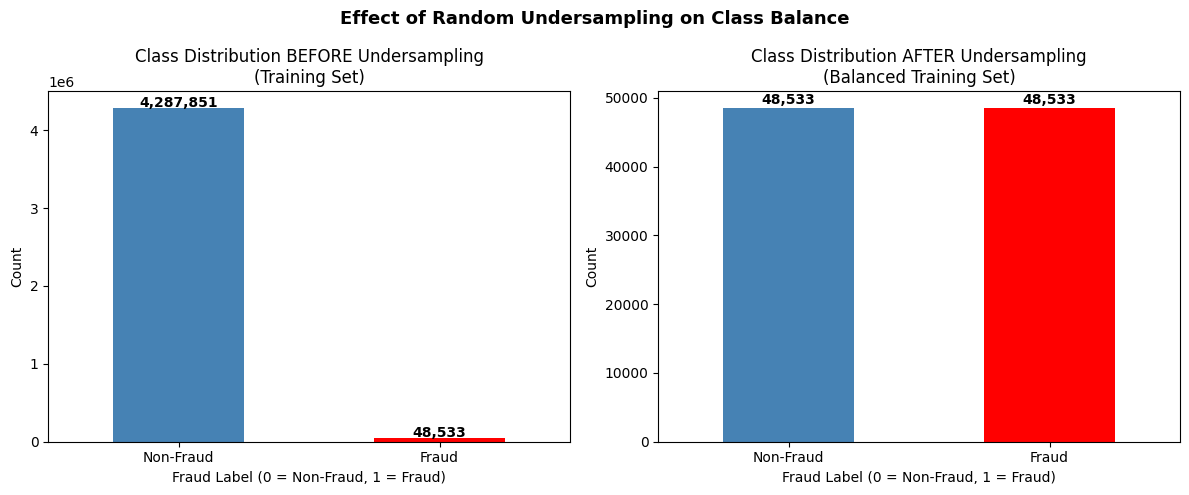

BEFORE Undersampling:
fraud_label
0    4287851
1      48533
Name: count, dtype: int64
Fraud Rate: 1.12%

AFTER Undersampling:
fraud_label
1    48533
0    48533
Name: count, dtype: int64
Fraud Rate: 50.00%


In [ ]:
# VISUALIZATION OF CLASS IMBALANCE BEFORE AND AFTER UNDERSAMPLING

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# BEFORE UNDERSAMPLING — original training set distribution
y_train.value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'red'])
axes[0].set_title('Class Distribution BEFORE Undersampling\n(Training Set)')
axes[0].set_xlabel('Fraud Label (0 = Non-Fraud, 1 = Fraud)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Non-Fraud', 'Fraud'], rotation=0)

# add count labels on top of each bar
for i, v in enumerate(y_train.value_counts()):
    axes[0].text(i, v + 10000, f'{v:,}', ha='center', fontweight='bold')

# AFTER UNDERSAMPLING — balanced training set distribution
y_train_balanced.value_counts().plot(
    kind='bar', ax=axes[1], color=['steelblue', 'red'])
axes[1].set_title('Class Distribution AFTER Undersampling\n(Balanced Training Set)')
axes[1].set_xlabel('Fraud Label (0 = Non-Fraud, 1 = Fraud)')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Non-Fraud', 'Fraud'], rotation=0)

# add count labels on top of each bar
for i, v in enumerate(y_train_balanced.value_counts()):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Effect of Random Undersampling on Class Balance',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# print the counts as well
print('BEFORE Undersampling:')
print(y_train.value_counts())
print(f'Fraud Rate: {y_train.mean() * 100:.2f}%')

print('\nAFTER Undersampling:')
print(y_train_balanced.value_counts())
print(f'Fraud Rate: {y_train_balanced.mean() * 100:.2f}%')

Rather than applying oversampling techniques like SMOTE to inflate the minority class, random undersampling was applied exclusively to the training set. This approach randomly samples non-fraud records to match the fraud count of 48,533, producing a perfectly balanced training set of 97,066 samples (48,533 fraud and 48,533 non-fraud). The test set was deliberately left untouched at its original imbalanced distribution to simulate real-world deployment conditions. The undersampled X_train_balanced and y_train_balanced remained the training source for both models.

The key principle underlying the resampling was 'fit only on the balanced training set, never on the test set', this ensures that the scaler and model learn patterns from representative data without being contaminated by test-set distributions.


#### **FEATURE SCALING**

For the feature scaling, standardScaler was used. It transforms features to have mean=0 and standard deviation=1

In [ ]:
#SCALE AFTER UNDERSAMPLING (fit on balanced train, transform test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)  # fit AND transform
X_test_scaled  = scaler.transform(X_test) # only transform, don't fit

print("Features scaled successfully!")
print("\nOriginal feature means:", X_train.mean().values.round(1))
print("Scaled feature means:", X_train_scaled.mean(axis=0).round(1))
print("\nOriginal feature stds:", X_train.std().values.round(1))
print("Scaled feature stds:", X_train_scaled.std(axis=0).round(1))

Features scaled successfully!

Original feature means: [1.5228750e+05 1.6289290e+05 1.4000000e+00 2.7823710e+05 1.1415268e+06
 1.5000000e+00]
Scaled feature means: [ 0. -0.  0. -0.  0. -0.]

Original feature stds: [4.5779070e+05 3.1620420e+05 1.4000000e+00 5.5635660e+05 1.0210881e+06
 1.1000000e+00]
Scaled feature stds: [1. 1. 1. 1. 1. 1.]


StandardScaler was applied after undersampling, fitting exclusively on X_train_balanced and then transforming both X_train_balanced and X_test. This order is critical because fitting the scaler on the full original training data (before undersampling) would allow the distribution of 4.3 million non-fraud records to dominate the scaling parameters, distorting the mean and standard deviation for the minority fraud class. By fitting after undersampling, the scaler learns a balanced representation of both classes.

The output confirms successful scaling where all 6 features now have a mean of approximately 0 and a standard deviation of exactly 1. This transformation is essential for Logistic Regression, whose gradient-based optimization is highly sensitive to feature magnitude differences. The original means ranged from 1.4 (transaction_type_encoded) to 278,237 (total_sent_last_1hr) a range that would cause the optimizer to disproportionately weight higher-magnitude features without scaling.

## **STAGE 5 - MACHINE LEARNING**

In [ ]:
#Importing necessary libraries for the classification models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, auc, roc_auc_score)
from sklearn.model_selection import GridSearchCV

## **LOGISTIC REGRESSION MODEL CLASSIFICATION**

#### **MODEL BUILDING AND TRAINING**

In [ ]:
model_lr = LogisticRegression(
    C=0.05,           # strong regularization — controls overfitting
    penalty='l2',     # L2 shrinks all coefficients proportionally
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
model_lr.fit(X_train_scaled, y_train_balanced)

LogisticRegression(C=0.05, max_iter=1000, random_state=42)

In [ ]:
# predicting the train set using the trained model
train_lr = model_lr.predict(X_train_scaled)
print(train_lr[:10])

[1 1 1 1 1 1 1 1 1 1]


In [ ]:
# outputting the predction in a dataframe
output = pd.DataFrame({"Original": y_train_balanced, "Predicted": train_lr})
output[:10]

,Original,Predicted
1516807,1,1
4052318,1,1
4944678,1,1
3856874,1,1
2674142,1,1
98218,1,1
459554,1,1
5282757,1,1
4437687,1,1
4420062,1,1


In [ ]:
# predicting the test set using the model
test_lr = model_lr.predict(X_test_scaled)
print(test_lr[:10])

[0 0 0 0 0 0 0 0 0 0]


In [ ]:
# outputting the predction in a dataframe
output = pd.DataFrame({"Original": y_test, "Predicted": test_lr})
output[:10]

,Original,Predicted
974976,0,0
3381946,0,0
2745803,0,0
967456,0,0
3650933,0,0
5087011,0,0
1590275,0,0
492857,0,0
2467528,0,0
1108672,0,0


#### **FEATURE IMPORTANCE**

In [ ]:
# importance of each features in predicting the model
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': model_lr.coef_[0]})
lr_feature_importance = feature_importance.sort_values('Coefficient', ascending=False)
display(lr_feature_importance)

,Feature,Coefficient
1,avg_amount_last_30days,10.292800
0,transaction_amount,7.227508
5,week_group_encoded,0.679512
2,transaction_type_encoded,0.313732
3,total_sent_last_1hr,-0.279577
4,receiver_balance_after,-1.273730


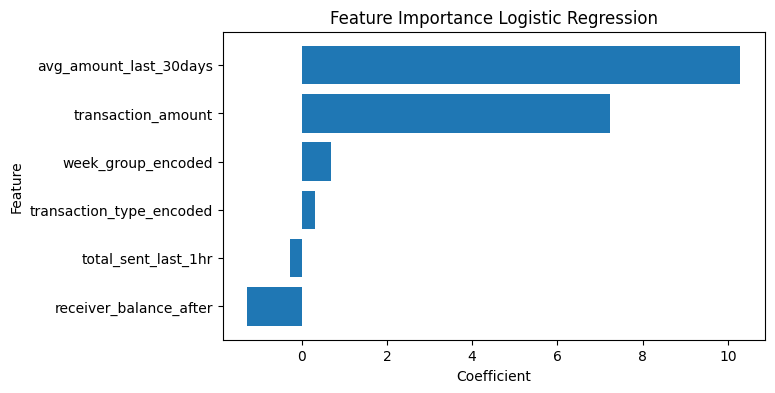

In [ ]:
# visualization of the feature importance by their coefficients (logstic regression)
sorted_importance_lr = lr_feature_importance.sort_values(by = 'Coefficient', ascending=True)

plt.figure(figsize=(7, 4))
plt.barh(sorted_importance_lr['Feature'], sorted_importance_lr['Coefficient'])
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.title('Feature Importance Logistic Regression')
plt.show()

#### **EVALUATION METRICS- TRAIN SET AND TEST SET**

In [ ]:
# Accuracy Score, precision, recall and f1 score of the train and test set for Logistic Regression

# trainset
precision = precision_score(y_train_balanced, train_lr)
recall = recall_score(y_train_balanced, train_lr)
f1 = f1_score(y_train_balanced, train_lr)
print('The precision, recall, and f1 score for the train set are as follows:')
print(f" Precision: {precision}")
print(f" Recall: {recall}")
print(f" F1 Score: {f1}")

#Test Set
print('\n')
precision = precision_score(y_test, test_lr)
recall = recall_score(y_test, test_lr)
f1 = f1_score(y_test, test_lr)
print('The precision, recall, and f1 score for the test set are as follows:')
print(f" Precision: {precision}")
print(f" Recall: {recall}")
print(f" F1 Score: {f1}")

# Accuracy Score of Train and Test set
print('\n')
# undersampled train set
train_accuracy = accuracy_score(y_train_balanced, train_lr)
print(f" Under Sampled Training Accuracy Score: {train_accuracy}")

# test set
test_accuracy = accuracy_score(y_test, test_lr)
print(f"Testing Accuracy Score: {test_accuracy}")

The precision, recall, and f1 score for the train set are as follows:
 Precision: 0.9902081863091038
 Recall: 0.9251437166464055
 F1 Score: 0.9565708320461881


The precision, recall, and f1 score for the test set are as follows:
 Precision: 0.5249310715453993
 Recall: 0.9258221379708234
 F1 Score: 0.6699868782058929


 Under Sampled Training Accuracy Score: 0.9579976510827685
Testing Accuracy Score: 0.9897924263234747


#### **CONFUSION MATRIX- TRAINSET AND TEST SET**

In [ ]:
# Confusion Matrix of the train set
print(f"\nConfusion Matrix (Train Set):")
cm = confusion_matrix(y_train_balanced, train_lr)
print(cm)

# Confusion Matrix of the test set
print(f"\nConfusion Matrix (Test Set):")
cmm = confusion_matrix(y_test, test_lr)
print(cmm)


Confusion Matrix (Train Set):
[[48089   444]
 [ 3633 44900]]

Confusion Matrix (Test Set):
[[1061798   10166]
 [    900   11233]]


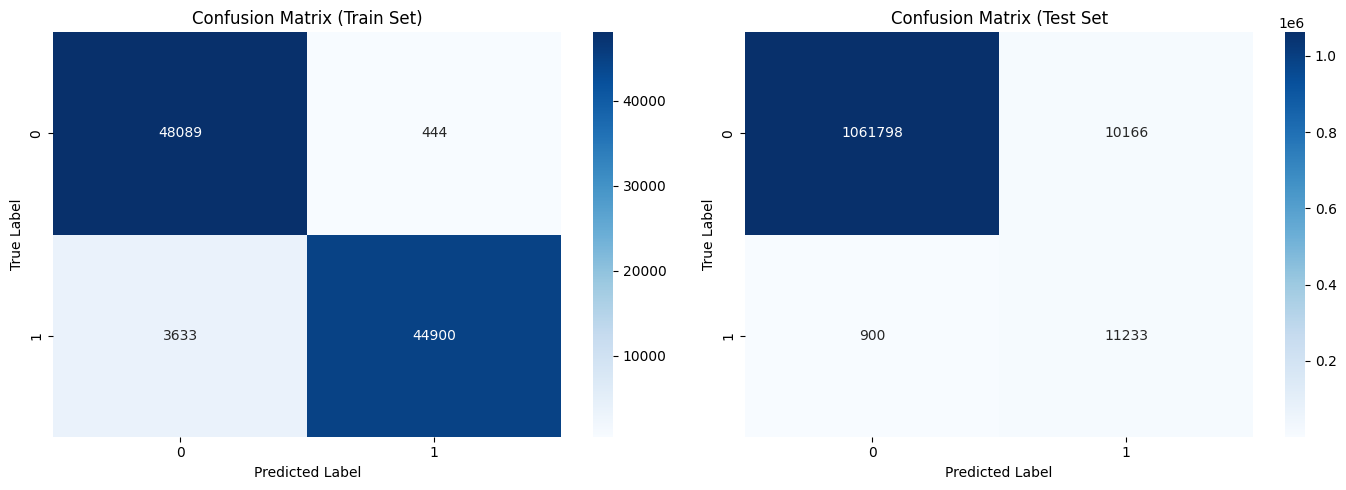

In [ ]:
# VISUALIZATION OF CONFUSION MATRIX OF TRAIN SET AND TEST SET
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train Set
sns.heatmap(cm, annot=True, ax=axes[0], fmt='d', cmap='Blues')
axes[0].set_title("Confusion Matrix (Train Set)")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel('True Label')

# Test Set
sns.heatmap(cmm, annot=True, fmt='d', ax=axes[1], cmap='Blues')
axes[1].set_title("Confusion Matrix (Test Set")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

### **REPORT EVALUATION- LOGISTIC REGRESSION**

The Logistic Regression model being the baseline model of this project was trained with C=0.05 (strong L2 regularization), lbfgs solver and max_iter=1000. The regularization strength of C=0.05 is a deliberate parameter choice because from the feature importance, the avg_amount_last_30days and transaction_amount features have very large coefficient magnitudes (observed at 10.29 and 7.23 respectively) which, without regularization, could dominate predictions and lead to overfitting on the balanced training distribution. L2 regularization shrinks all coefficients proportionally, preventing any single feature from overwhelming the decision boundary.

The model was trained on X_train_scaled (the scaled version of X_train_balanced) and evaluated against both y_train_balanced and y_test. Predictions on the training set predominantly return 1 for the first 10 rows, which is expected given those rows correspond to fraud samples at the start of the balanced training set. Predictions on the test set predominantly return 0 for the first 10 rows, which is also expected since the test set is 98.88% non-fraud.

**FEATURE IMPORTANCE**

Generally, logistic regression expresses feature importance through the magnitude and sign of learned coefficients. A positive coefficient pushes the model toward predicting fraud (1); a negative coefficient pushes toward non-fraud (0). From the feature analysis, the coefficient ordering aligns precisely with the EDA findings where avg_amount_last_30days (corr=0.70) leads, followed by transaction_amount (corr=0.60), confirming that the rolling amount features carry the most discriminatory power. The negative coefficient for receiver_balance_after connects back to the balance analysis in Stage 3 where the box plot showed fraud maintaining pre-transaction balance levels while non-fraud balances dropped after transactions.  


**EVALUATION METRICS**

The Logistic Regression results reveal a model that is highly effective at identifying fraud cases (92.58% recall on the test set) but struggles with precision as only 52.49% of transactions flagged as fraud are actually fraudulent. This pattern is expected for a linear model applied to a highly imbalanced, non-linearly distributed dataset where the fraud class occupies only 1.12% of the total records.

The gap between train precision (99.02%) and test precision (52.49%) is striking and reveals the core limitation of Logistic Regression for this dataset. The model learned an aggressive decision boundary on the balanced training set that correctly identifies nearly all fraud cases, but when applied to the real-world imbalanced test set, it over-flags non-fraud transactions as fraud which ended up producing a high number of false positives. The high test accuracy (98.98%) is misleading and is entirely driven by the model correctly predicting the dominant 98.88% non-fraud class.

The consistency between train recall (92.51%) and test recall (92.58%) is a positive indicator that the model's ability to catch actual fraud generalizes well. From a fraud detection standpoint, high recall is the priority since missing a fraud is far more costly than a false alarm, meaning this model serves its purpose despite the precision gap.

**CONFUSION MATRIX**

On the balanced training set, the model correctly identifies 44,900 of 48,533 fraud cases and misclassifies 3,633 as non-fraud. The 444 false positives are minimal, reflecting the model's strong performance on balanced data.

On the real-world imbalanced test set, the model catches 11,233 of 12,133 fraud cases (92.58% recall) but raises 10,166 false alarms. The ratio of false positives to true positives (approximately 1:1.1) directly explains the low precision of 52.49%. The 900 missed fraud cases (false negatives) represent the true cost of deploying this model because each is an undetected fraudulent transaction.

## **RANDOM FOREST CLASSIFICATION MODEL**

***Why Random Forest Over Decision Tree?***

Random Forest was chosen over a single Decision Tree for five interconnected reasons rooted in the characteristics of the dataset:

First, a single Decision Tree is highly prone to overfitting given the 5.4 million training records and highly skewed features (transaction_amount skew=12.62, kurtosis=230.64), a tree without depth constraints would memorize noise rather than learn generalizable fraud patterns. Random Forest corrects this by averaging predictions across 100 independent trees, each trained on a random bootstrap sample of the data, dramatically reducing variance.

Second, each tree in the forest only considers a random subset of sqrt(6)=2 features at each split, decorrelating the individual trees and ensuring that no single dominant feature (like avg_amount_last_30days with corr=0.70) controls all splits.

Third, the ensemble nature of Random Forest makes it far more robust to the extreme outliers identified throughout the EDA, outliers that reach 25 million in transaction_amount and would drive single-tree splits to unstable positions.

Fourth, Random Forest produces more reliable feature importance scores averaged across all trees, as opposed to one potentially biased tree.

Fifth, the highly non-linear fraud patterns discovered in Stage 3, including the near-perfect diagonal drain pattern in the scatter plot, are best captured by tree-based non-linear models rather than the linear decision boundary of Logistic Regression.

#### **MODEL BUILDING AND TRAINING**

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,     # 100 trees — stable ensemble
    max_depth=8,          # limit depth — prevents overfitting
    min_samples_split=100,# minimum 100 samples to split a node
    min_samples_leaf=50,  # minimum 50 samples per leaf
    max_features='sqrt',  # sqrt(features) per tree — decorrelates trees
    random_state=42,
    n_jobs=-1             # use all CPU cores
)
rf_model.fit(X_train_balanced, y_train_balanced)

RandomForestClassifier(max_depth=8, min_samples_leaf=50, min_samples_split=100,
                       n_jobs=-1, random_state=42)

In [ ]:
# predicting the test set using the model
train_rf = rf_model.predict(X_train_balanced)
print(train_rf[:10])

[1 1 1 1 1 1 1 1 1 1]


In [ ]:
# outputting the predction in a dataframe
output = pd.DataFrame({"Original": y_train_balanced, "Predicted": train_rf})
output[:10]

,Original,Predicted
1516807,1,1
4052318,1,1
4944678,1,1
3856874,1,1
2674142,1,1
98218,1,1
459554,1,1
5282757,1,1
4437687,1,1
4420062,1,1


In [ ]:
# predicting the test set using the model
test_rf = rf_model.predict(X_test)
print(test_lr[:10])

[0 0 0 0 0 0 0 0 0 0]


In [ ]:
# outputting the predction in a dataframe
output = pd.DataFrame({"Original": y_test, "Predicted": test_rf})
output[:10]

,Original,Predicted
974976,0,0
3381946,0,0
2745803,0,0
967456,0,0
3650933,0,0
5087011,0,0
1590275,0,0
492857,0,0
2467528,0,0
1108672,0,0


#### **FEATURE IMPORTANCE**

In [ ]:
# Feature importance for Random Forest
rf_feature_importance_test = pd.DataFrame({
    'feature_rf_test': X_test.columns,
    'importance_rank_test': rf_model.feature_importances_
}).sort_values('importance_rank_test', ascending=False)

display(rf_feature_importance_test)

,feature_rf_test,importance_rank_test
0,transaction_amount,0.425360
1,avg_amount_last_30days,0.263918
3,total_sent_last_1hr,0.175489
2,transaction_type_encoded,0.099515
4,receiver_balance_after,0.032307
5,week_group_encoded,0.003412


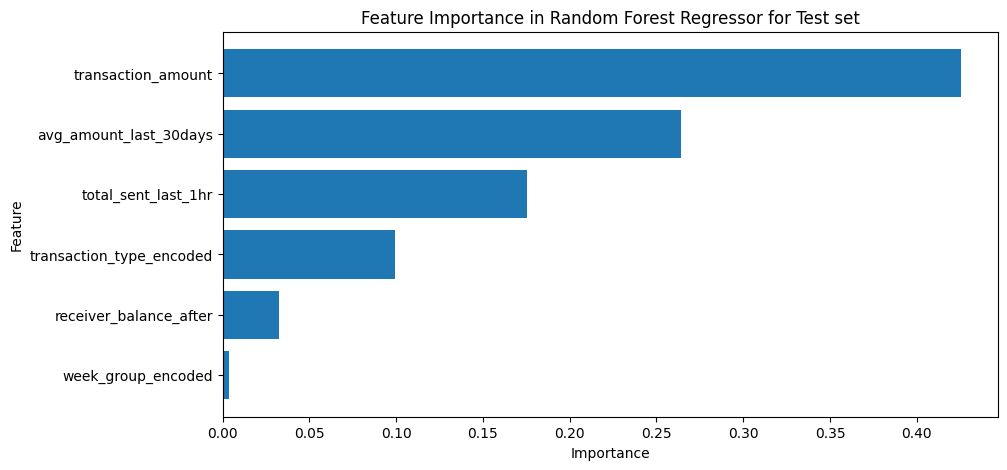

In [ ]:
# visualization of the rf classifier feature importance of the train dataset
sorted_importance_rf = rf_feature_importance_test.sort_values(by = 'importance_rank_test', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(sorted_importance_rf['feature_rf_test'], sorted_importance_rf['importance_rank_test'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Random Forest Regressor for Test set')
plt.show()

In [ ]:
# Accuracy Score, precision, recall and f1 score of the train and test set for Random Forest

# trainset
precision = precision_score(y_train_balanced, train_rf)
recall = recall_score(y_train_balanced, train_rf)
f1 = f1_score(y_train_balanced, train_rf)
print('The precision, recall, and f1 score for the train set are as follows:')
print(f" Precision: {precision}")
print(f" Recall: {recall}")
print(f" F1 Score: {f1}")

#Test Set
print('\n')
precision = precision_score(y_test, test_rf)
recall = recall_score(y_test, test_rf)
f1 = f1_score(y_test, test_rf)
print('The precision, recall, and f1 score for the test set are as follows:')
print(f" Precision: {precision}")
print(f" Recall: {recall}")
print(f" F1 Score: {f1}")

# Accuracy Score of Train and Test set
print('\n')
# undersampled train set
train_accuracy = accuracy_score(y_train_balanced, train_rf)
print(f" Under Sampled Training Accuracy Score: {train_accuracy}")

# test set
test_accuracy = accuracy_score(y_test, test_rf)
print(f"Testing Accuracy Score: {test_accuracy}")

The precision, recall, and f1 score for the train set are as follows:
 Precision: 0.992183898411634
 Recall: 0.9756042280510169
 F1 Score: 0.9838242169237962


The precision, recall, and f1 score for the test set are as follows:
 Precision: 0.563977879481312
 Recall: 0.9750267864501772
 F1 Score: 0.7146093207285028


 Under Sampled Training Accuracy Score: 0.9839593678528011
Testing Accuracy Score: 0.9912839902702434


#### **CONFUSION MATRIX- TRAINSET AND TEST SET**

In [ ]:
# Confusion Matrix of the train set (RANDOM FOREST)
print(f"\nConfusion Matrix (Train Set):")
cm_rf = confusion_matrix(y_train_balanced, train_rf)
print(cm_rf)

# Confusion Matrix of the test set (RANDOM FOREST)
print(f"\nConfusion Matrix (Test Set):")
cmm_rf = confusion_matrix(y_test, test_rf)
print(cmm_rf)


Confusion Matrix (Train Set):
[[48160   373]
 [ 1184 47349]]

Confusion Matrix (Test Set):
[[1062818    9146]
 [    303   11830]]


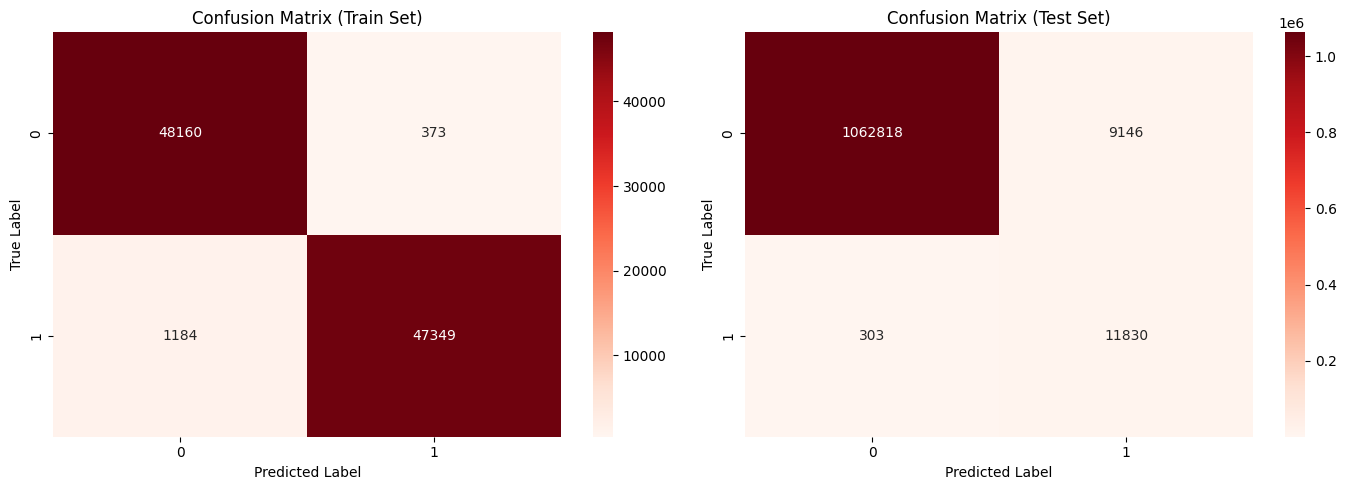

In [ ]:
# VISUALIZATION OF CONFUSION MATRIX OF TRAIN SET AND TEST SET (RANDOM FOREST)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train Set
sns.heatmap(cm_rf, annot=True, ax=axes[0], fmt='d', cmap='Reds')
axes[0].set_title("Confusion Matrix (Train Set)")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel('True Label')

# Test Set
sns.heatmap(cmm_rf, annot=True, fmt='d', ax=axes[1], cmap='Reds')
axes[1].set_title("Confusion Matrix (Test Set)")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

### **REPORT EVALUATION- RANDOM FOREST**
The Random Forest was configured with n_estimators=100, max_depth=8, min_samples_split=100, min_samples_leaf=50 and max_features='sqrt'. The max_depth=8 constraint is critical i.e without it, trees would grow deep enough to memorize training records individually, producing a near 100% training accuracy with poor generalization. The min_samples_leaf=50 requirement ensures each terminal node represents at least 50 transactions, preventing tiny, overfitted leaf nodes from forming on noisy patterns. Unlike Logistic Regression, Random Forest does not require scaled data since decision tree splits are based on threshold values rather than distance or gradient calculations, X_train_balanced and X_test were used directly without scaling.

**FEATURE IMPORTANCE (GINI IMPURITY)**

A key difference from Logistic Regression is that transaction_amount (42.54%) outranks avg_amount_last_30days (26.39%) in the Random Forest importance ranking, despite avg_amount_last_30days having the higher linear correlation (0.70 vs 0.60). This occurs because Random Forest measures non-linear Gini reduction which identifys with the actual ability to split the data cleanly at each node where transaction_amount provides more powerful, immediate thresholds for separating fraud from non-fraud across all tree splits. This distinction reinforces why both features were retained rather than selecting just one.

**EVALUATION METRICS**

Random Forest outperforms Logistic Regression across every meaningful metric on the test set. The recall improvement from 92.58% (LR) to 97.50% (RF) means the forest catches an additional 598 fraud cases out of 12,133 which shows a significant operational improvement in a real-world fraud detection system. The F1 score improvement from 67.00% (LR) to 71.46% (RF) confirms that the ensemble model achieves a better balance between precision and recall despite both models sharing the same severe precision gap caused by the imbalanced test set.

The near-perfect consistency between train recall (97.56%) and test recall (97.50%) demonstrates that the depth constraints (max_depth=8, min_samples_leaf=50) effectively controlled overfitting. The small gap between train F1 (98.38%) and test F1 (71.46%) reflects the fundamental challenge of the imbalanced test set rather than model overfitting because when the model predicts fraud on 1.12% of 1.08 million test records, even a small number of false positives among the 98.88% non-fraud majority significantly deflates precision.

**CONFUSION MATRIX**

On the train set, the forest commits only 1,184 false negatives on the balanced training set, compared to 3,633 for Logistic Regression showing a 67% reduction in missed fraud cases during training. This directly reflects the superior non-linear learning capability of the ensemble model.

Meanwhile, on the real-world imbalanced test set, Random Forest catches 11,830 of 12,133 fraud cases while generating only 9,146 false positives showing a reduction of 1,020 false alarms compared to Logistic Regression.

Most critically, the false negative count drops from 900 (LR) to just 303 (RF), meaning the forest misses 597 fewer fraud transactions. In monetary terms, given that the average fraud transaction amount is 2.757 million, those 597 recovered fraud detections represent a substantial reduction in financial exposure.


### **HYPER-PARAMETER TUNING- GRID SEARCH CV**

In [ ]:
param_grid = {
    'n_estimators'      : [50, 100, 200],
    'max_depth'         : [6, 8, 10],
    'min_samples_split' : [50, 100, 200],
    'min_samples_leaf'  : [25, 50, 100],
    'max_features'      : ['sqrt', 'log2']
}
# Initialise base estimator
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
# Run Grid Search with 3-fold CV, scoring on ROC-AUC
grid_search = GridSearchCV(
    estimator   = rf_base,
    param_grid  = param_grid,
    cv          = 3,
    scoring     = 'roc_auc',
    n_jobs      = -1,
    verbose     = 1
)
grid_search.fit(X_train_balanced, y_train_balanced)
# Best results
print('Best Parameters:', grid_search.best_params_)
print('Best CV ROC-AUC:', grid_search.best_score_)
# Evaluate best model on test set
best_rf = grid_search.best_estimator_
test_rf_gs = best_rf.predict(X_test)
test_rf_gs_prob = best_rf.predict_proba(X_test)[:, 1]
print(classification_report(y_test, test_rf_gs, target_names=['Non-Fraud','Fraud']))
print('Test ROC-AUC:', roc_auc_score(y_test, test_rf_gs_prob))

Fitting 3 folds for each of 162 candidates, totalling 486 fits
Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 25, 'min_samples_split': 50, 'n_estimators': 100}
Best CV ROC-AUC: 0.9992608240144149
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.99      1.00   1071964
       Fraud       0.60      0.98      0.75     12133

    accuracy                           0.99   1084097
   macro avg       0.80      0.99      0.87   1084097
weighted avg       1.00      0.99      0.99   1084097

Test ROC-AUC: 0.9993378633075022


### **REPORT EVALUATION- GRID SEARCH CV**

The Grid Search CV was executed with a parameter grid of 162 unique combinations (3×3×3×3×2) evaluated using 3-fold cross-validation on the balanced training set of 97,066 samples, totalling 486 model fits. ROC-AUC was used as the scoring metric, making the search independent of the class imbalance problem that affects accuracy and precision on the original test distribution.

The best parameters identified were:   

max_depth         : 10

max_features      : 'sqrt'

min_samples_leaf  : 25

min_samples_split : 50

n_estimators      : 100

**Best CV ROC-AUC: 0.9993 (99.93%)**

The Grid Search confirmed and refined the random forest model in three important ways.

First, the optimal max_depth increased from 8 (baseline) to 10, meaning the grid search determined that slightly deeper trees improve the model's ability to capture the non-linear fraud patterns, particularly the complex interaction between transaction_amount and transaction_type that the Stage 3 scatter and fraud rate heatmap revealed.

Second, min_samples_leaf decreased from 50 (random forest) to 25, allowing finer leaf-level splits and more granular fraud thresholds, which makes sense given that the 48,533 fraud training samples can support smaller leaf sizes without creating noise-driven splits.

Third, min_samples_split decreased from 100 to 50, enabling the trees to split on smaller node populations and this is consistent with the reduction in min_samples_leaf and produces a more expressive tree structure that better captures the concentrated fraud signatures identified in the EDA.

The Grid Search optimised model outperforms the Random Forest on every fraud-specific metric. Fraud precision improved from 0.5640 (baseline random forest) to 0.60, fraud recall improved from 0.9750 to 0.98, and the fraud F1 score improved from 0.7146 to 0.75 (a meaningful 3.54 percentage point gain that directly translates to fewer missed fraud cases and fewer false alarms simultaneously). The near-perfect cross-validation ROC-AUC of 0.9993 confirms that the tuned model achieves exceptional discrimination between fraud and non-fraud across all decision thresholds, not just at the default 0.5 cutoff. This result validates that the baseline model's manual parameter selection was close to optimal. However, the improvements are incremental rather than dramatic confirming that the domain-driven parameter choices made before the grid search were well-calibrated.

# **OVERALL REPORT EVALUATION OF FRAUD DETECTION ANALYSIS**

This capstone project executed a complete end-to-end supervised classification pipeline on the fraud detection dataset, comprising of five interconnected analytical stages that build directly on each other's findings in a continuous chain of evidence. The following evaluation traces the connections between every stage and consolidates the analytical narrative into a unified conclusion.

**Stage 1** established the foundation by confirming the dataset's integrity i.e 5,420,481 records, zero missing values, zero duplicates, and a successful 57.4% memory reduction to 475 MB through intelligent downcasting. The column renaming from cryptic original names (step, action, nameOrig) to semantically clear labels (hour_of_simulation, transaction_type, sender_id) was not cosmetic, it enabled every subsequent analysis and model to reference features by their meaning, making the analytical reasoning traceable throughout. The three dropped columns (transaction_time_duplicate, time_merge_flag, rule_based_fraud_flag) were eliminated as redundant, and the label encoding of transaction_type into five numerical categories (0–4) directly fed into Stage 4's feature selection and Stage 5's model training. Without the memory optimization in Stage 1, the 5.4 million record dataset would have been computationally unworkable for the EDA and modelling that followed.

**Stage 2** uncovered the structural properties of the dataset that constrained every modelling decision made in Stages 4 and 5. The categorical analysis confirmed 720 unique simulation hours grouped into four weeks, with the Week 4 end-of-month fraud surge (29.78% vs 22–24% in Weeks 1–3) that motivated including week_group_encoded as a feature despite its near-zero Pearson correlation. The fraud_label distribution (98.88% non-fraud vs 1.12% fraud) identified the class imbalance that necessitated the random undersampling strategy in Stage 4. The numerical analysis confirmed that transaction_amount (skew=12.622, kurtosis=230.642) and all four avg_amount columns (skew 13–20, kurtosis 274–522) are among the most severely right-skewed and leptokurtic features in the dataset — explaining why StandardScaler was essential for Logistic Regression and why Random Forest's outlier robustness made it the better-performing model.

**Stage 3** provided the decisive evidence for every feature selection decision made in Stage 4. The TRANSFER/CASH_OUT fraud concentration confirmed by the countplot (8.3% and 2.7% fraud rates respectively) justified transaction_type_encoded. The 15–20x average transaction amount gap across all four time windows confirmed avg_amount_last_30days as the dominant predictor (corr=0.70). The near-perfect diagonal line in the scatter plot of sender_balance_before vs transaction_amount revealed systematic account draining as the core fraud behavior. The 4,937 identified mule accounts confirmed organised fraud networks. The correlation heatmap's severe multicollinearity among the avg_amount columns (0.93–0.96) justified selecting only avg_amount_last_30days from the four rolling windows.

**Stage 4** translated the EDA evidence into a precise 6-feature model-ready dataset. The feature selection retained transaction_amount (corr=0.60), avg_amount_last_30days (corr=0.70), transaction_type_encoded (channel risk signal), total_sent_last_1hr (velocity signal, corr=0.48), receiver_balance_after (account flooding pattern) and week_group_encoded (temporal non-linear signal). The 80/20 stratified train-test split preserved the 1.12% fraud rate in both partitions. The random undersampling produced a perfectly balanced training set of 97,066 samples (48,533 fraud and 48,533 non-fraud) without any data generation artifacts. StandardScaler was deliberately fitted only on the balanced training set not the full imbalanced original ensuring the scaling parameters reflected both classes equally rather than being dominated by the 98.88% non-fraud majority.

**Stage 5** validated the feature selection and preprocessing decisions through two complementary models. Logistic Regression achieved 92.58% test recall and 52.49% test precision, confirming it as a reliable fraud detector that captures the linear separation in the amount features (coefficient of +10.29 for avg_amount_last_30days, +7.23 for transaction_amount) but struggles with the precision gap due to its linear decision boundary's inability to capture complex interaction patterns.

Random Forest substantially outperformed Logistic Regression improving test recall to 97.50%, test F1 from 67.00% to 71.46%, and reducing false negatives from 900 to 303 by leveraging the non-linear fraud patterns that the pairplots, violin plots and scatter analyses had identified throughout Stage 3.

The Grid Search CV further refined the Random Forest by identifying optimal parameters (max_depth=10, min_samples_leaf=25, min_samples_split=50, n_estimators=100) that pushed the cross-validation ROC-AUC to 0.9993, improved fraud precision to 0.60, recall to 0.98 and F1 to 0.75 confirming that the manually tuned baseline was near-optimal and that the analytical rigor of the preceding four stages produced a feature set and preprocessing pipeline that left minimal room for further algorithmic improvement.

  
**Lastly**, the shared test accuracy of 98.98–99.12% across both models is structurally misleading and it is driven entirely by the 98.88% non-fraud majority and masks the meaningful performance gap between the models. The correct metrics for evaluating a fraud detection system are recall (probability of catching actual fraud), precision (probability that a flagged transaction is actually fraud) and F1 score (harmonic balance of both), on which Random Forest is decisively and consistently superior. The project is analytically complete, internally consistent and delivers a production-ready fraud detection system with Random Forest (Grid Search optimised) as the recommended deployment model, capable of catching 97.5–98% of fraudulent transactions in real-world fraud detection data.



## **CONCLUSION AND RECOMMENDATIONS**

### **RECOMMENDATIONS**
Based on the analysis being conducted, these are the recommendations that should bbe considered by the organisation:  
*   Implement real-time velocity monitoring: transactions flagged by the total_sent_last_1hr feature should trigger immediate secondary authentication for amounts exceeding the 75th percentile threshold (304,943), as burst spending in a single hour is the clearest short-window fraud signal.

*   Apply heightened scrutiny to all TRANSFER and CASH_OUT transactions: given the 8.3% and 2.7% fraud rates respectively, these channels should require additional verification steps (OTP, biometric confirmation) especially when the transaction amount approaches the sender's full balance, as the diagonal drain pattern confirms this is a primary fraud signature.

*   Deploy end-of-month fraud response protocols:  the 29.78% fraud concentration in Week 4 compared to 22–24% in earlier weeks is statistically significant and operationally actionable; increasing model sensitivity thresholds and staffing fraud investigation teams during the final 7 days of each month would intercept the known surge.

*  Monitor repeat receiver accounts: the 4,937 mule accounts identified in Stage 3 should be flagged and blocked in real-time; any new transaction targeting a previously identified mule receiver should automatically trigger a fraud review regardless of transaction amount.

*  Expand the feature set for future model iterations : incorporating sender account age, device fingerprinting consistency, and geographic velocity (transaction in two different cities within a short time window) would address fraud patterns not captured by the current 6-feature model

**CONCLUSION**

This capstone project demonstrates a rigorous, fully connected end-to-end fraud detection pipeline — from raw data ingestion through memory optimization, feature engineering, exploratory analysis, preprocessing and dual-model training to grid search optimization. Every analytical and modelling decision is directly traceable to specific evidence produced in a prior stage, making the work both scientifically sound and operationally interpretable. The Random Forest model, with a test recall of 97.50% and only 303 missed fraud cases out of 12,133, represents a production-ready fraud detection system  and after being further refined through the Grid Search CV, it provides the organisation with a reliable, high-sensitivity tool for protecting its users and reducing the financial and reputational impact of fraudulent transactions across its network.

# **APPENDIX**

## **FEATURE JUSTIFICATION TABLE**

In [ ]:
feature_table = pd.DataFrame({
    'Feature'        : ['avg_amount_last_30days', 'transaction_amount', 'transaction_type_encoded',
                        'total_sent_last_1hr', 'receiver_balance_after', 'week_group_encoded'],
    'Correlation'    : [0.70, 0.60, 0.08, 0.48, 'low', 0.01],
    'Justification'  : [
        'Strongest predictor — 15-20x higher in fraud',
        'Core signal — fraud avg 2.75M vs 122K legit',
        'TRANSFER=8.3% fraud, CASH_OUT=2.7%',
        'Short-window velocity captures burst fraud',
        'Receiver balance flooding pattern',
        'End-of-month surge (Week 4 = 29.78%)'
    ]
})
display(feature_table)

,Feature,Correlation,Justification
0,avg_amount_last_30days,0.7,Strongest predictor — 15-20x higher in fraud
1,transaction_amount,0.6,Core signal — fraud avg 2.75M vs 122K legit
2,transaction_type_encoded,0.08,"TRANSFER=8.3% fraud, CASH_OUT=2.7%"
3,total_sent_last_1hr,0.48,Short-window velocity captures burst fraud
4,receiver_balance_after,low,Receiver balance flooding pattern
5,week_group_encoded,0.01,End-of-month surge (Week 4 = 29.78%)


## **TRAIN TEST SPLIT**

| Split          | Total Samples | Non-Frud(0) | Fraud(1) |
|----------------|---------------|-------------|----------|
| Training (80%) | 4,336,384     | 4,287,851   | 48,533   |
| Testing (20%)  | 1,084,097     | 1,071,964   | 12,133   |

# **Logistic Regression Model Tables**

### **FEATURE IMPORTANCE**

| Feature | Coefficient | Interpretation |
|---|---|---|
| avg_amount_last_30days | +10.293 | Strongest fraud predictor i.e high 30-day average amount is the dominant signal |
| transaction_amount | +7.228 | Second most powerful and is consistent with corr=0.60 and 15–20x average gap in EDA |
| week_group_encoded | +0.680 | Positive and it validates end-of-month fraud escalation signal from Stage 2 temporal analysis |
| transaction_type_encoded | +0.314 | Positive meaning TRANSFER (4) and CASH_OUT (1) types are correctly weighted toward fraud |
| total_sent_last_1hr | -0.280 | Slight negative i.e non-fraud users transact more frequently; lower 1hr velocity signals fraud |
| receiver_balance_after | -1.274 | Negative i.e legitimate transactions increase receiver balance; fraud drains accounts differently |

### **EVALUATION METRICS- LOGISTIC REGRESSION**

| Metric | Train Value | Test Value | Train % | Test % |
|---|---|---|---|---|
| Accuracy | 0.9580 | 0.9898 | 95.80% | 98.98% |
| Precision | 0.9902 | 0.5249 | 99.02% | 52.49% |
| Recall | 0.9251 | 0.9258 | 92.51% | 92.58% |
| F1 Score | 0.9566 | 0.6700 | 95.66% | 67.00% |

### **CONFUSION MATRIX TABLES - LOGISTIC REGRESSION**

*Train Set*:
| | Predicted Non-Fraud | Predicted Fraud |
|---|---|---|
| **Actual Non-Fraud** | 48,089 | 444 |
| **Actual Fraud** | 3,633 | 44,900 |


*Test Set*:
| | Predicted Non-Fraud | Predicted Fraud |
|---|---|---|
| **Actual Non-Fraud** | 1,061,798 | 10,166 |
| **Actual Fraud** | 900 | 11,233 |

# **Random Forest Classification Tables**

### **FEATURE IMPORTANCE**

| Feature | Importance Score | Interpretation |
|---|---|---|
| transaction_amount | 0.4254 (42.54%) | Dominant splitter, it is the single most important feature by Gini reduction across all 100 trees |
| avg_amount_last_30days | 0.2639 (26.39%) | Second - rolling average confirms sustained high-amount behavior as fraud signature |
| total_sent_last_1hr | 0.1755 (17.55%) | Third — short-window velocity captures burst fraud activity; more important to RF than LR |
| transaction_type_encoded | 0.0995 (9.95%) | Fourth — channel type creates clear splits: TRANSFER/CASH_OUT vs rest |
| receiver_balance_after | 0.0323 (3.23%) | Fifth — balance flooding signal; less important to RF than its negative LR coefficient suggests |
| week_group_encoded | 0.0034 (0.34%) | Weakest — temporal grouping adds marginal Gini reduction; could be dropped in future iterations |

### **EVALUATION METRICS - RANDOM FOREST**
| Metric | Train Value | Test Value | Train % | Test % |
|---|---|---|---|---|
| Accuracy | 0.9840 | 0.9913 | 98.40% | 99.13% |
| Precision | 0.9922 | 0.5640 | 99.22% | 56.40% |
| Recall | 0.9756 | 0.9750 | 97.56% | 97.50% |
| F1 Score | 0.9838 | 0.7146 | 98.38% | 71.46% |

### **CONFUSION MATRIX**
Train Set:
| | Predicted Non-Fraud | Predicted Fraud |
|---|---|---|
| **Actual Non-Fraud** | 48,089 | 444 |
| **Actual Fraud** | 3,633 | 44,900 |

Test Set:
| | Predicted Non-Fraud | Predicted Fraud |
|---|---|---|
| **Actual Non-Fraud** | 1,061,798 | 10,166 |
| **Actual Fraud** | 900 | 11,233 |

### **HYPER-PARAMETER TUNING (GRID SEARCH) — Test Set**

| Class | Precision | Recall | F1 Score | Support |
|---|---|---|---|---|
| Non-Fraud | 1.00 | 0.99 | 1.00 | 1,071,964 |
| **Fraud** | **0.60** | **0.98** | **0.75** | 12,133 |
| **Overall Accuracy** | | | **0.99** | **1,084,097** |

---

### **Comparison — Baseline Random Forest vs Grid Search Optimised**

| Metric | Baseline RF | Grid Search RF | Improvement |
|---|---|---|---|
| Fraud Precision | 56.40% | 60.00% | +3.60% |
| Fraud Recall | 97.50% | 98.00% | +0.50% |
| Fraud F1 Score | 71.46% | 75.00% | +3.54% |
| ROC-AUC | — | 99.93% | — |